In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.stats.multitest import multipletests

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')

OUTCOMES = ['offset', 'exponent']
PREDICTORS = ['nrs_z', 'new_affective_PC1', 'new_sensory_PC1']


def rlm_weighted_r2(y_true, y_pred, weights):
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - weighted_mean) ** 2)
    return 1 - ss_res / ss_tot


result_summary = []

for ptID in ptIDs:

    records_df = pd.read_pickle(
        f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
    )
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)

    subset = behavior_table[behavior_table['ptID'] == ptID]
    merged = records_df.merge(subset, on='trial_idx')

    records_data = merged[merged['r2'] >= 0.9][
        ['ch_label', 'edf_ch_idx', 'nrs_z', 'new_affective_PC1', 'new_sensory_PC1',
         'exponent', 'offset']
    ]

    rois = sorted(records_data['ch_label'].unique())

    for roi in rois:
        df_roi = records_data[records_data['ch_label'] == roi]

        row_result = {
            'ptID': ptID,
            'ch_label': roi,
            'edf_ch_idx': df_roi['edf_ch_idx'].iloc[0],
            'n': len(df_roi),
        }

        for outcome in OUTCOMES:
            y = zscore(df_roi[outcome].values, nan_policy='omit')

            for predictor in PREDICTORS:
                X = df_roi[predictor].values
                X_sm = sm.add_constant(X)

                model = RLM(y, X_sm, missing='drop').fit()
                pred = model.predict(X_sm)

                beta = model.params[1]
                p = model.pvalues[1]
                r2_weighted = rlm_weighted_r2(y, pred, model.weights)

                key = f"{outcome}_{predictor}"
                row_result[f"beta_{key}"] = beta
                row_result[f"p_{key}"] = p
                row_result[f"r2_{key}"] = r2_weighted

        result_summary.append(row_result)

summary_df = pd.DataFrame(result_summary)

# ---------------- FDR correction, done separately per outcome-predictor combo ----------------
# (i.e. correcting across all ptID x channel tests for a given combo, not lumping
#  different combos together, since they answer different questions)
# for outcome in OUTCOMES:
#     for predictor in PREDICTORS:
#         key = f"{outcome}_{predictor}"
#         p_col = f"p_{key}"
#         fdr_col = f"p_fdr_{key}"
#         sig_col = f"sig_{key}"

#         valid = summary_df[p_col].notna()
#         summary_df[fdr_col] = np.nan
#         summary_df.loc[valid, fdr_col] = multipletests(
#             summary_df.loc[valid, p_col], method='fdr_bh'
#         )[1]
#         summary_df[sig_col] = summary_df[fdr_col] < 0.05

# summary_df.to_csv('/home/jiahuang/test-code-hazel/rlm_summary_offset_exponent.csv', index=False)
display(summary_df)

,ptID,ch_label,edf_ch_idx,n,beta_offset_nrs_z,p_offset_nrs_z,r2_offset_nrs_z,beta_offset_new_affective_PC1,p_offset_new_affective_PC1,r2_offset_new_affective_PC1,...,r2_offset_new_sensory_PC1,beta_exponent_nrs_z,p_exponent_nrs_z,r2_exponent_nrs_z,beta_exponent_new_affective_PC1,p_exponent_new_affective_PC1,r2_exponent_new_affective_PC1,beta_exponent_new_sensory_PC1,p_exponent_new_sensory_PC1,r2_exponent_new_sensory_PC1
0,RCS02,L AINS_1,104,81,0.080024,7.022518e-04,0.065444,0.032613,0.166495,0.011048,...,0.027343,0.413797,1.088016e-06,0.249268,0.184074,0.047824,0.053903,0.184189,0.022608,0.064075
1,RCS02,L AINS_2,102,81,0.064615,5.222423e-04,0.051076,0.034130,0.061375,0.014693,...,0.004830,0.273810,3.289531e-08,0.207881,0.142025,0.014309,0.057905,0.094240,0.056264,0.035178
2,RCS02,L AINS_3,103,81,0.082445,4.113992e-04,0.063749,0.030615,0.209386,0.009014,...,0.012547,0.284757,2.008817e-06,0.209938,0.077867,0.241861,0.015752,0.121325,0.038167,0.045390
3,RCS02,L AINS_4,122,81,0.124281,1.708883e-08,0.139421,0.040995,0.112161,0.015151,...,0.024931,0.364127,1.054054e-11,0.321730,0.087031,0.183025,0.018862,0.141027,0.012485,0.060581
4,RCS02,L IC_1,139,80,-0.005538,5.678733e-01,0.000815,-0.009056,0.311228,0.002615,...,0.016001,-0.012551,8.374444e-01,0.000415,-0.047922,0.386601,0.007164,-0.099160,0.039620,0.039810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,RCS09,R THAL_6,26,143,0.035759,5.546099e-04,0.028127,0.041361,0.000072,0.037908,...,0.045042,0.034555,1.019356e-01,0.010043,0.047650,0.022711,0.019673,0.037992,0.010913,0.023500
359,RCS09,R dlPFC_1,38,149,0.031016,4.439723e-01,0.003247,0.049990,0.210312,0.008421,...,0.002867,0.053836,4.173565e-01,0.004325,0.066600,0.311699,0.006646,0.020667,0.671166,0.001206
360,RCS09,R dmPFC_1,19,149,-0.001591,9.665649e-01,0.000010,0.010509,0.783654,0.000433,...,0.000002,-0.028244,7.049962e-01,0.001031,-0.026150,0.725313,0.000887,-0.039007,0.470991,0.003709
361,RCS09,R dmPFC_2,18,149,0.021203,2.448970e-01,0.005136,0.033165,0.064391,0.013504,...,0.011591,0.001864,9.660934e-01,0.000010,0.004188,0.923809,0.000053,-0.010252,0.748940,0.000592


In [2]:
summary_df.to_csv('/home/jiahuang/test-code-hazel/rlm_summary_offset_exponent.csv', index=False)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.stats.multitest import multipletests

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']
behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')

OUTCOMES = ['offset', 'exponent']
PREDICTORS = ['nrs_z', 'new_affective_PC1', 'new_sensory_PC1']


def rlm_weighted_r2(y_true, y_pred, weights):
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - weighted_mean) ** 2)
    return 1 - ss_res / ss_tot


result_summary = []

for ptID in ptIDs:

    records_df = pd.read_pickle(
        f"/userdata/jiahuang/pain-data/Stage1-test/{ptID}/records_df_fooof_{ptID}.pkl"
    )
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)

    subset = behavior_table[behavior_table['ptID'] == ptID]
    merged = records_df.merge(subset, on='trial_idx')

    records_data = merged[merged['r2'] >= 0.9][
        ['ch_label', 'edf_ch_idx', 'nrs_z', 'new_affective_PC1', 'new_sensory_PC1',
         'exponent', 'offset']
    ]

    rois = sorted(records_data['ch_label'].unique())

    for roi in rois:
        df_roi = records_data[records_data['ch_label'] == roi]

        row_result = {
            'ptID': ptID,
            'ch_label': roi,
            'edf_ch_idx': df_roi['edf_ch_idx'].iloc[0],
            'n': len(df_roi),
        }

        for outcome in OUTCOMES:
            y = zscore(df_roi[outcome].values, nan_policy='omit')

            for predictor in PREDICTORS:
                X = df_roi[predictor].values
                X_sm = sm.add_constant(X)

                model = RLM(y, X_sm, missing='drop').fit()
                pred = model.predict(X_sm)

                beta = model.params[1]
                p = model.pvalues[1]
                r2_weighted = rlm_weighted_r2(y, pred, model.weights)

                key = f"{outcome}_{predictor}"
                row_result[f"beta_{key}"] = beta
                row_result[f"p_{key}"] = p
                row_result[f"r2_{key}"] = r2_weighted

        result_summary.append(row_result)

summary_df = pd.DataFrame(result_summary)

# ---------------- FDR correction, done separately per outcome-predictor combo ----------------
# (i.e. correcting across all ptID x channel tests for a given combo, not lumping
#  different combos together, since they answer different questions)
# for outcome in OUTCOMES:
#     for predictor in PREDICTORS:
#         key = f"{outcome}_{predictor}"
#         p_col = f"p_{key}"
#         fdr_col = f"p_fdr_{key}"
#         sig_col = f"sig_{key}"

#         valid = summary_df[p_col].notna()
#         summary_df[fdr_col] = np.nan
#         summary_df.loc[valid, fdr_col] = multipletests(
#             summary_df.loc[valid, p_col], method='fdr_bh'
#         )[1]
#         summary_df[sig_col] = summary_df[fdr_col] < 0.05

# summary_df.to_csv('/home/jiahuang/test-code-hazel/rlm_summary_offset_exponent.csv', index=False)
display(summary_df)

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.stats.multitest import multipletests

ptIDs = ['RCS02', 'RCS03', 'RCS04', 'RCS05', 'RCS06', 'RCS07', 'RCS08', 'RCS09']

bandref = {
    'delta': [3, 4],
    'theta': [4, 8],
    'alpha': [8, 12],
    'beta': [12, 30],
    'low_gamma': [30, 50]
}
bands = list(bandref.keys())

PREDICTORS = ['nrs_z', 'new_affective_PC1', 'new_sensory_PC1']
BAND_POWER_COL = 'band_power_z'

behavior_table = pd.read_csv('/home/jiahuang/test-code-hazel/behavior_table_all_patients_newPC.csv')


def rlm_weighted_r2(y_true, y_pred, weights):
    weighted_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - weighted_mean) ** 2)
    return 1 - ss_res / ss_tot


def run_rlm(y, X):
    """Fit RLM(y ~ X), return beta, p, weighted r2 for the slope term."""
    X_sm = sm.add_constant(X)
    model = RLM(y, X_sm, missing='drop').fit()
    pred = model.predict(X_sm)
    beta = model.params[1]
    p = model.pvalues[1]
    r2_weighted = rlm_weighted_r2(y, pred, model.weights)
    return beta, p, r2_weighted

def build_long_df_zscored(pt, bandref, r2_threshold=0.9):
    record_path = f"/userdata/jiahuang/pain-data/Stage1-test/{pt}/records_df_fooof_{pt}.pkl"
    records_df = pd.read_pickle(record_path)
    records_df['roi'] = records_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
    records_df['exponent_z'] = zscore(records_df['exponent'].values, nan_policy='omit')
    records_df['offset_z'] = zscore(records_df['offset'].values, nan_policy='omit')
    records_df = records_df[records_df['r2'] >= r2_threshold]

    freqs_welch = records_df['fooof'].iloc[0].freqs
    ch_labels = sorted(records_df['ch_label'].unique())
    rows = []

    for ch in ch_labels:
        sub = records_df[records_df['ch_label'] == ch].sort_values('trial_idx').reset_index(drop=True)

        corrected_stack = np.stack(
            [r['fooof'].fooofed_spectrum_ - r['fooof']._ap_fit for _, r in sub.iterrows()]
        )
        raw_stack = np.stack([r['fooof'].power_spectrum for _, r in sub.iterrows()])
        corrected_z = (corrected_stack - corrected_stack.mean(axis=0)) / corrected_stack.std(axis=0)
        raw_z = (raw_stack - raw_stack.mean(axis=0)) / raw_stack.std(axis=0)

        for i, row in sub.iterrows():
            for band in bands:
                fmin, fmax = bandref[band]
                idxf = np.where((freqs_welch >= fmin) & (freqs_welch <= fmax))[0]
                rows.append({
                    'ptID': pt,
                    'trial_idx': row['trial_idx'],
                    'ch_label': ch,
                    'roi': row['roi'],
                    'edf_ch_idx': row['edf_ch_idx'],
                    'exponent_z': row['exponent_z'],
                    'offset_z': row['offset_z'],
                    'band': band,
                    'band_power': np.nanmean(corrected_stack[i, idxf]),
                    'band_power_z': np.nanmean(corrected_z[i, idxf]),
                    'band_power_raw': np.nanmean(raw_stack[i, idxf]),
                    'band_power_raw_z': np.nanmean(raw_z[i, idxf]),
                })

    return pd.DataFrame(rows)


long_df = pd.concat([build_long_df_zscored(pt, bandref) for pt in ptIDs], ignore_index=True)

# merge in behavioral scores (nrs_z etc.) by ptID + trial_idx
long_df = long_df.merge(behavior_table[['ptID', 'trial_idx'] + PREDICTORS],
                         on=['ptID', 'trial_idx'], how='inner')

result_summary = []

channel_keys = long_df[['ptID', 'ch_label', 'edf_ch_idx']].drop_duplicates()

for _, key_row in channel_keys.iterrows():
    ptID, ch_label, edf_ch_idx = key_row['ptID'], key_row['ch_label'], key_row['edf_ch_idx']

    # dedupe across bands: exponent_z/offset_z are repeated per band, take one row per trial
    df_ch = (
        long_df[(long_df['ptID'] == ptID) & (long_df['ch_label'] == ch_label)]
        .drop_duplicates('trial_idx')
    )

    row_result = {
        'ptID': ptID,
        'ch_label': ch_label,
        'edf_ch_idx': edf_ch_idx,
        'n': len(df_ch),
    }

    for outcome in ['exponent_z', 'offset_z']:
        y = zscore(df_ch[outcome].values, nan_policy='omit')

        for predictor in PREDICTORS:
            X = df_ch[predictor].values
            beta, p, r2_weighted = run_rlm(y, X)

            combo = f"{outcome}_{predictor}"
            row_result[f"beta_{combo}"] = beta
            row_result[f"p_{combo}"] = p
            row_result[f"r2_{combo}"] = r2_weighted

    # ---- band power, one model per (channel, band, predictor) ----
    for band in bands:
        df_band = long_df[
            (long_df['ptID'] == ptID) & (long_df['ch_label'] == ch_label) & (long_df['band'] == band)
        ]
        y = zscore(df_band[BAND_POWER_COL].values, nan_policy='omit')

        for predictor in PREDICTORS:
            X = df_band[predictor].values
            beta, p, r2_weighted = run_rlm(y, X)

            combo = f"{band}_{predictor}"
            row_result[f"beta_{combo}"] = beta
            row_result[f"p_{combo}"] = p
            row_result[f"r2_{combo}"] = r2_weighted

    result_summary.append(row_result)

summary_df = pd.DataFrame(result_summary)

outcome_labels = ['exponent_z', 'offset_z'] + bands
for outcome in outcome_labels:
    for predictor in PREDICTORS:
        combo = f"{outcome}_{predictor}"
        p_col = f"p_{combo}"
        if p_col not in summary_df.columns:
            continue
        fdr_col = f"p_fdr_{combo}"
        sig_col = f"sig_{combo}"

        valid = summary_df[p_col].notna()
        summary_df[fdr_col] = np.nan
        summary_df.loc[valid, fdr_col] = multipletests(
            summary_df.loc[valid, p_col], method='fdr_bh'
        )[1]
        summary_df[sig_col] = summary_df[fdr_col] < 0.05

summary_df.to_csv('/home/jiahuang/test-code-hazel/rlm_summary_aperiodicandperiodic_full.csv', index=False)
display(summary_df)

,ptID,ch_label,edf_ch_idx,n,beta_exponent_z_nrs_z,p_exponent_z_nrs_z,r2_exponent_z_nrs_z,beta_exponent_z_new_affective_PC1,p_exponent_z_new_affective_PC1,r2_exponent_z_new_affective_PC1,...,p_fdr_beta_new_affective_PC1,sig_beta_new_affective_PC1,p_fdr_beta_new_sensory_PC1,sig_beta_new_sensory_PC1,p_fdr_low_gamma_nrs_z,sig_low_gamma_nrs_z,p_fdr_low_gamma_new_affective_PC1,sig_low_gamma_new_affective_PC1,p_fdr_low_gamma_new_sensory_PC1,sig_low_gamma_new_sensory_PC1
0,RCS02,L AINS_1,104,81,0.413797,1.088016e-06,0.249268,0.184074,0.047824,0.053903,...,0.534801,False,0.105783,False,0.008968,True,0.252456,False,0.034827,True
1,RCS02,L AINS_2,102,81,0.273810,3.289531e-08,0.207881,0.142025,0.014309,0.057905,...,0.069649,False,0.053383,False,0.013684,True,0.415396,False,0.059475,False
2,RCS02,L AINS_3,103,81,0.284757,2.008817e-06,0.209938,0.077867,0.241861,0.015752,...,0.290851,False,0.056942,False,0.064442,False,0.904553,False,0.203148,False
3,RCS02,L AINS_4,122,81,0.364127,1.054054e-11,0.321730,0.087031,0.183025,0.018862,...,0.068891,False,0.010082,True,0.242453,False,0.201327,False,0.504927,False
4,RCS02,L IC_1,139,80,-0.012551,8.374444e-01,0.000415,-0.047922,0.386601,0.007164,...,0.638081,False,0.251067,False,0.540945,False,0.895952,False,0.888339,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,RCS09,R THAL_6,26,143,0.034555,1.019356e-01,0.010043,0.047650,0.022711,0.019673,...,0.145708,False,0.095579,False,0.641069,False,0.526290,False,0.775691,False
359,RCS09,R dlPFC_1,38,149,0.053836,4.173565e-01,0.004325,0.066600,0.311699,0.006646,...,0.829492,False,0.870399,False,0.609226,False,0.441433,False,0.413003,False
360,RCS09,R dmPFC_1,19,149,-0.028244,7.049962e-01,0.001031,-0.026150,0.725313,0.000887,...,0.657302,False,0.478184,False,0.744904,False,0.752999,False,0.608694,False
361,RCS09,R dmPFC_2,18,149,0.001864,9.660934e-01,0.000010,0.004188,0.923809,0.000053,...,0.959556,False,0.822694,False,0.052587,False,0.085105,False,0.125387,False


In [1]:
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm,LinearSegmentedColormap
import numpy as np
import pandas as pd

def plot_dot_heatmap(df, beta_col, pval_col, ptIDs_order, rois_order, label,title, vmax, vmin=None,cmap='RdBu_r', alpha=0.05,savepath=None):
    fig, ax = plt.subplots(figsize=(1.3*len(ptIDs_order)+2, 0.7*len(rois_order)+2))
    # copy1 = df['beta_sensory'].copy()
    # copy2 = df['beta_affective'].copy()
    # vmax = np.nanmax(np.abs(copy1, copy2))
    if vmin==None: norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    else: 
        norm = Normalize(vmin=0, vmax=vmax)
        cmap = LinearSegmentedColormap.from_list(
            'positive',
            plt.get_cmap(cmap)(np.linspace(0.5, 1, 256))
        )
    
    for i, roi in enumerate(rois_order):
        for j, ptID in enumerate(ptIDs_order):
            sub = df[(df['roi']==roi) & (df['ptID']==ptID)]
            
            if len(pval_col) == 1:
                sub_sig = sub[sub[pval_col[0]] < alpha]
            elif len(pval_col) == 0:
                sub_sig = sub
            else:
                sub_sig = sub[(sub[pval_col[0]] < alpha) & (sub[pval_col[1]] < alpha)]
            # sub_sig = sub[sub[pval_col] < alpha]
            vals = sub_sig[beta_col].dropna().values
            n = len(vals)
            if n == 0:
                continue
            
            if n == 1:
                x_offsets = [0]
            else:
                x_offsets = np.linspace(-0.35, 0.35, n)
            
            x_pos = j + np.array(x_offsets)
            y_pos = np.full(n, i)
            
            ax.scatter(x_pos, y_pos, c=vals, cmap=cmap, norm=norm,
                        s=80, edgecolors='black', linewidths=0.5, zorder=3)
    
    for j, ptID in enumerate(ptIDs_order):

        rois_present = set(df.loc[df['ptID'] == ptID, 'roi'])

        for i, roi in enumerate(rois_order):
            if roi not in rois_present:
                ax.add_patch(
                    plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        facecolor='lightgray',
                        alpha=0.5,
                        hatch='////',
                        edgecolor='gray',
                        linewidth=0,
                        zorder=1
                    )
                )
    ax.set_xticks(np.arange(-0.5, len(ptIDs_order), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(rois_order), 1), minor=True)
    ax.grid(which='minor', color='lightgray', linewidth=0.8)
    ax.tick_params(which='minor', length=0)
    
    ax.set_xticks(range(len(ptIDs_order)))
    ax.set_xticklabels(ptIDs_order, rotation=45, ha='right', fontsize=15)
    ax.set_yticks(range(len(rois_order)))
    ax.set_yticklabels(rois_order, fontsize=15)
    
    ax.set_xlim(-0.5, len(ptIDs_order)-0.5)
    ax.set_ylim(-0.5, len(rois_order)-0.5)
    ax.invert_yaxis()
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, label=label)
    cbar.set_label(label, fontsize=15)
    # plt.colorbar(sm, ax=ax, label='Proportional difference%')
    
    # ax.set_title(title + f'\n(only p < {alpha} channels shown)')
    ax.set_title(title,fontsize=22,y=1.02)
    plt.tight_layout()
    if savepath!=None:
        plt.savefig(f'{savepath}/{title} - {label}')
    plt.show()

In [2]:
summary_df = pd.read_csv('/home/jiahuang/test-code-hazel/rlm_summary_aperiodicandperiodic_full.csv',index_col=0)

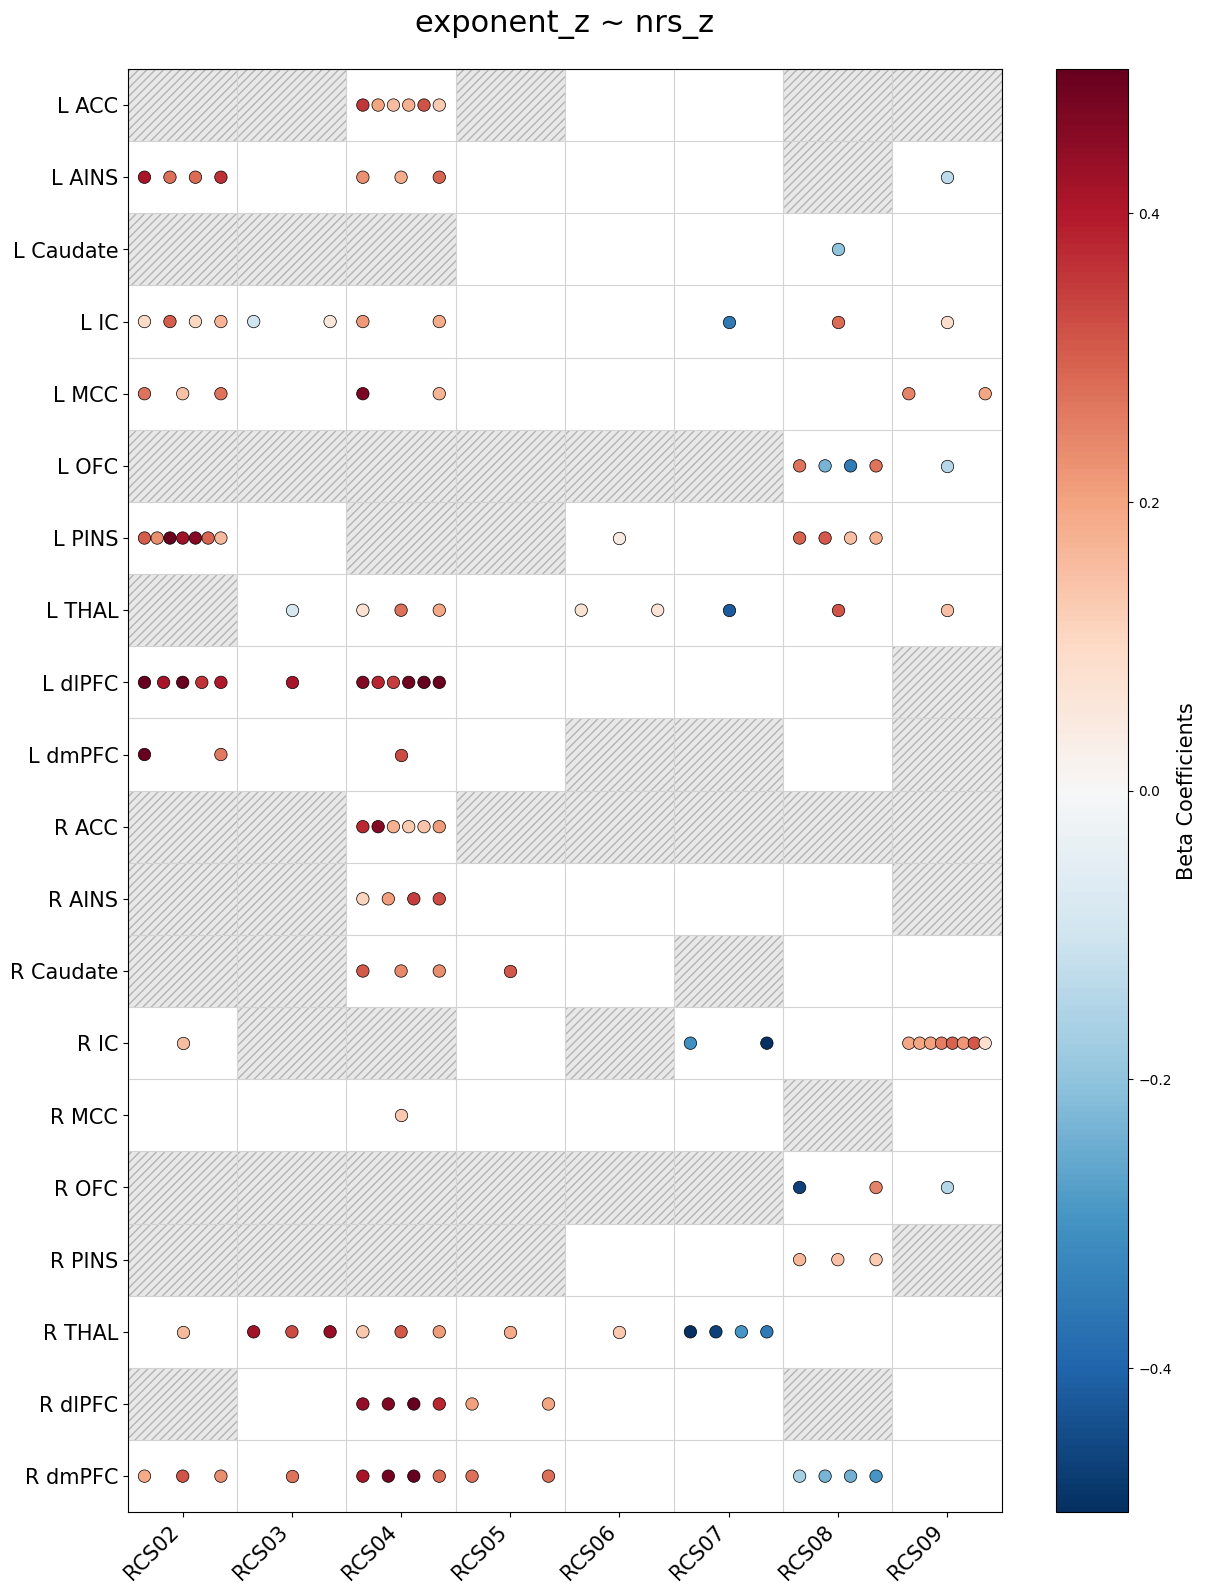

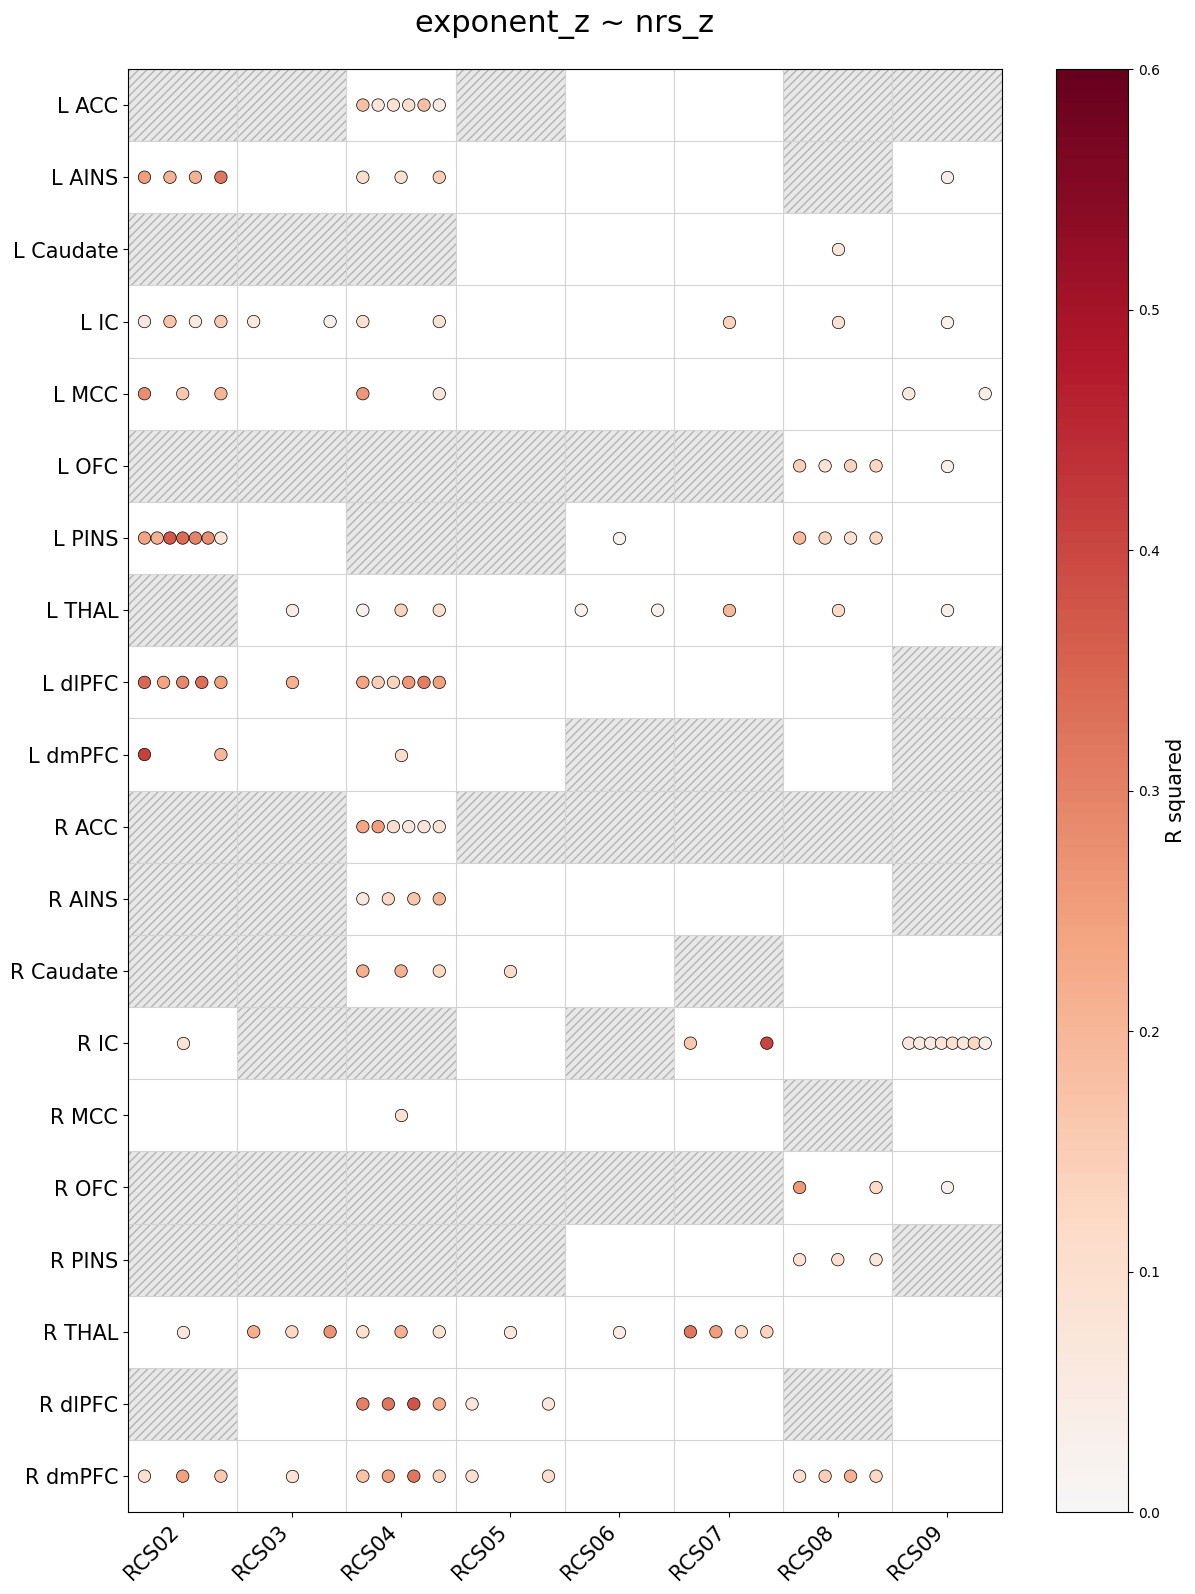

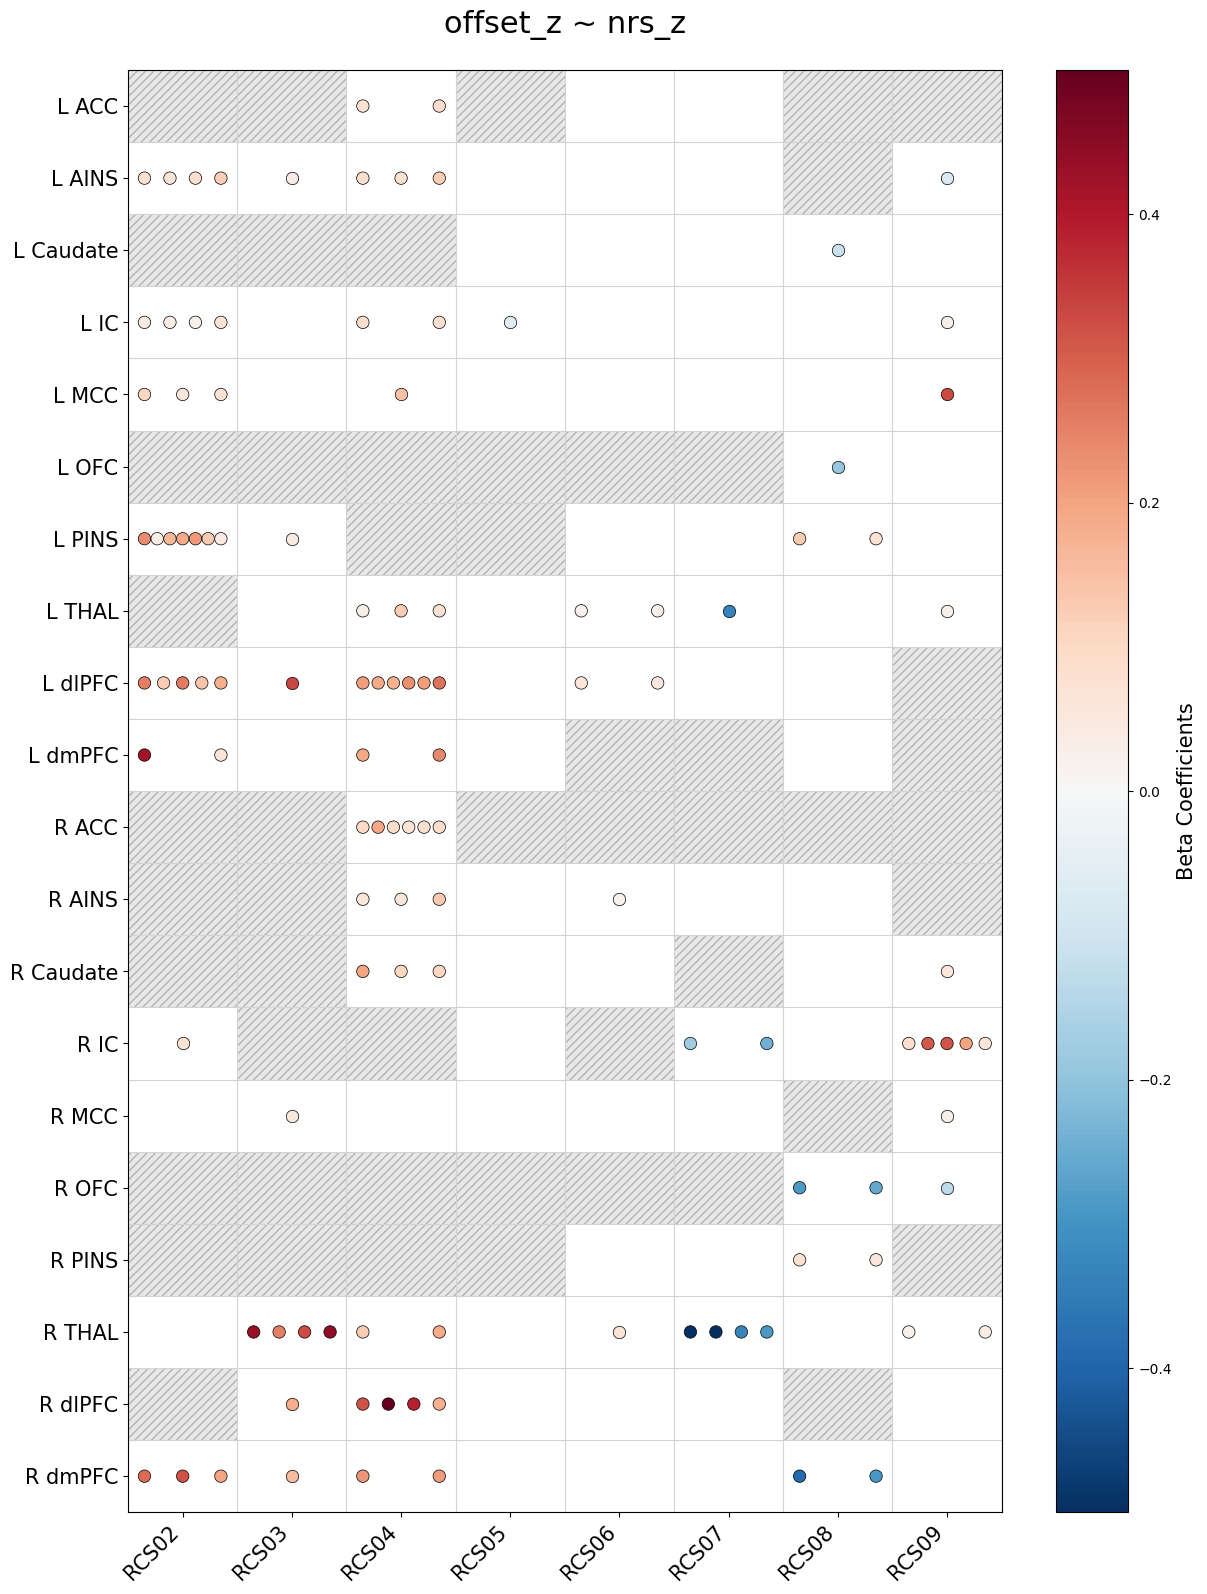

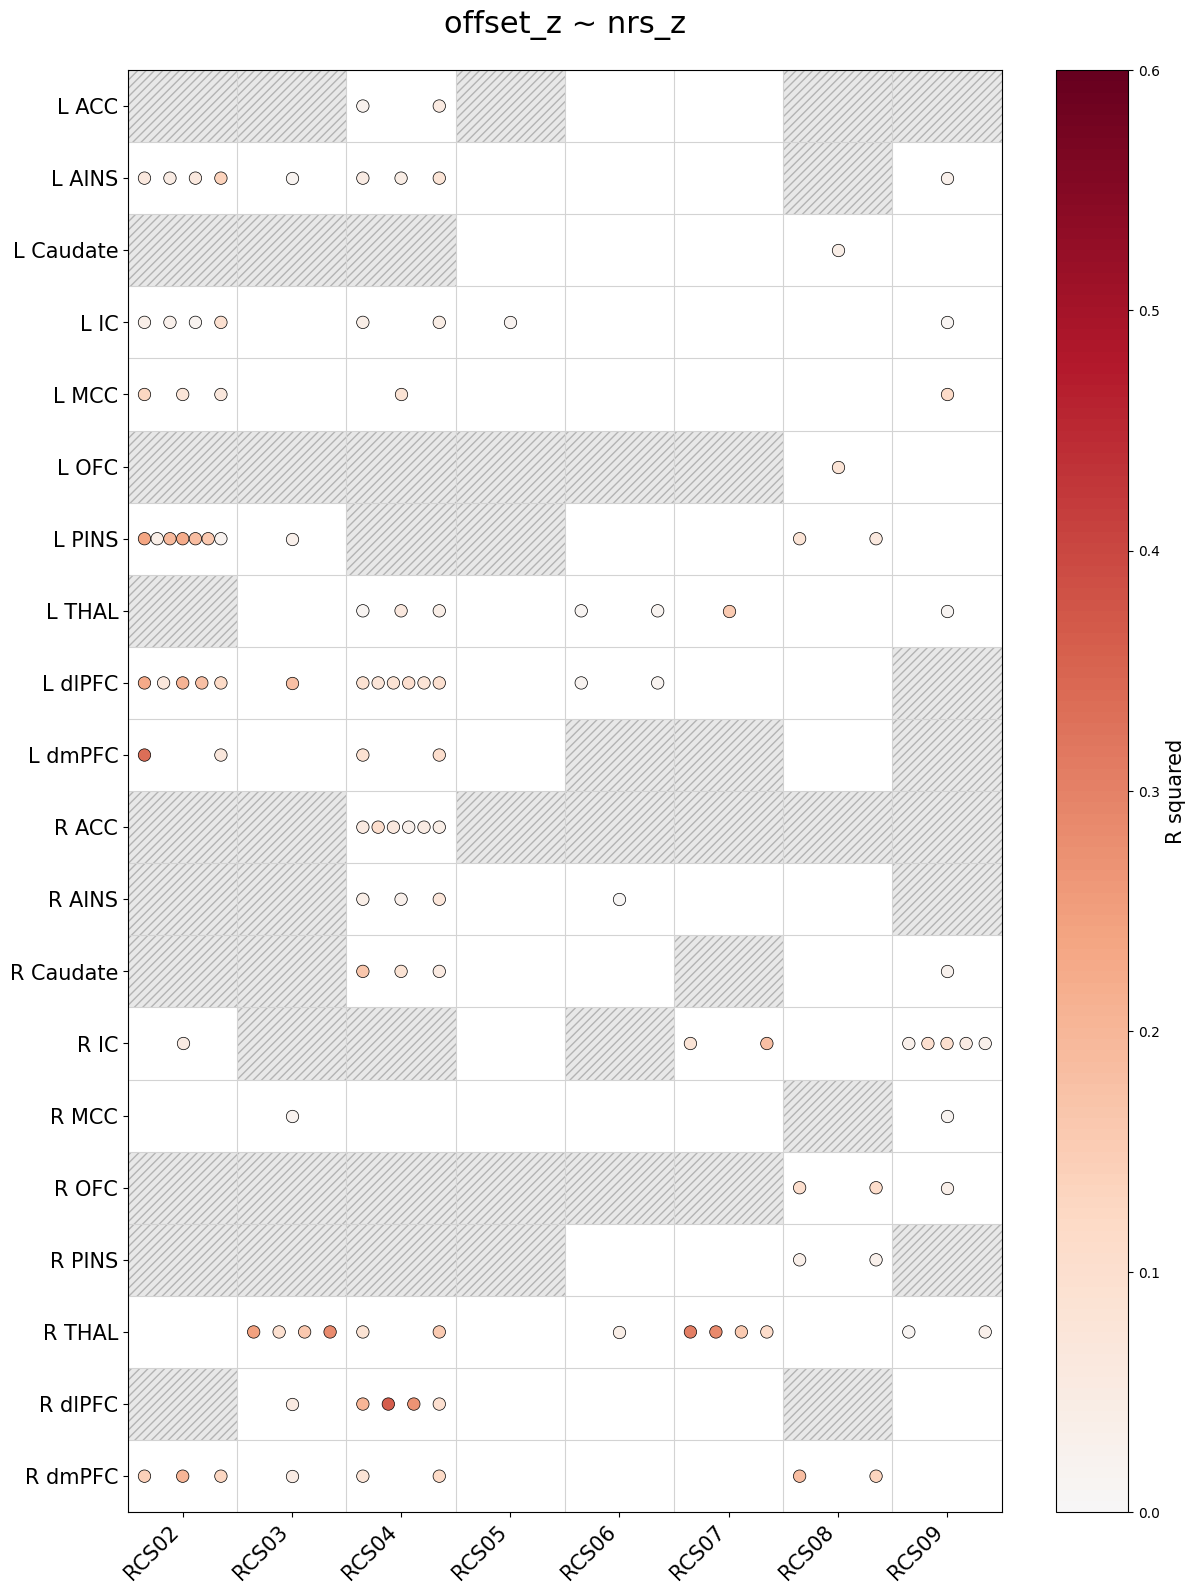

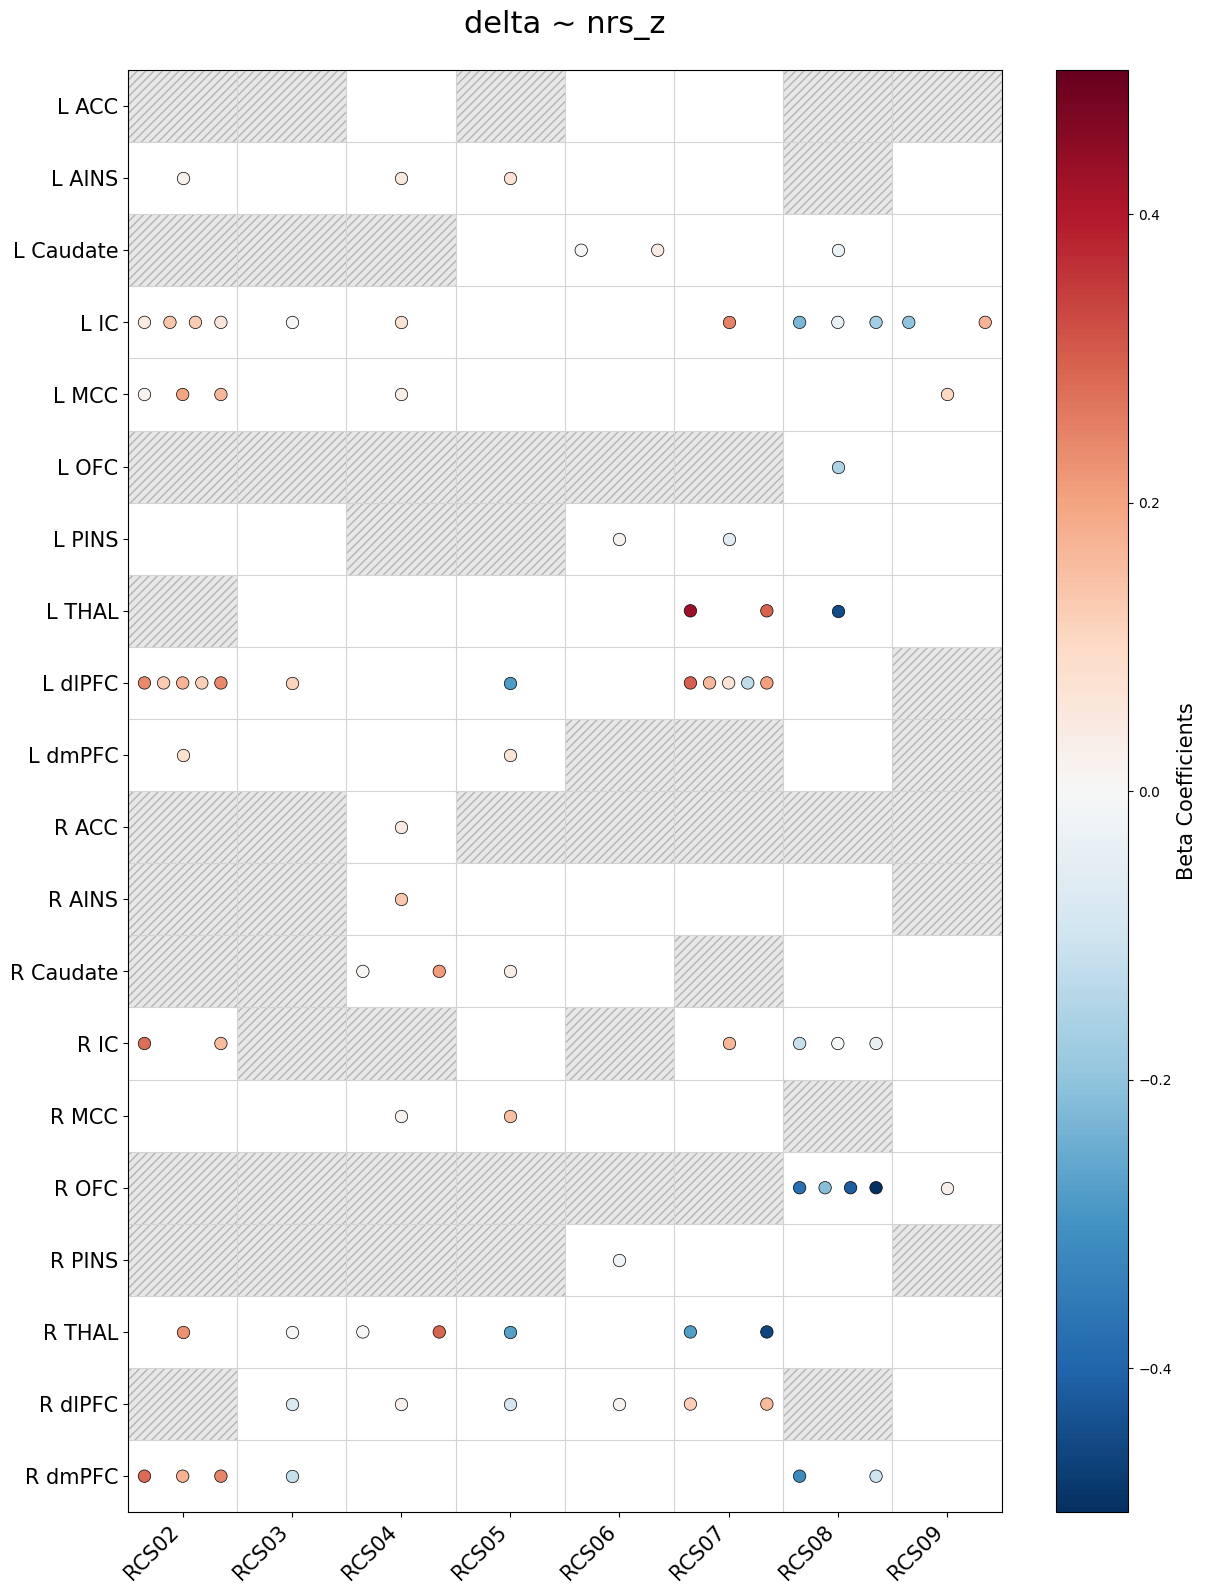

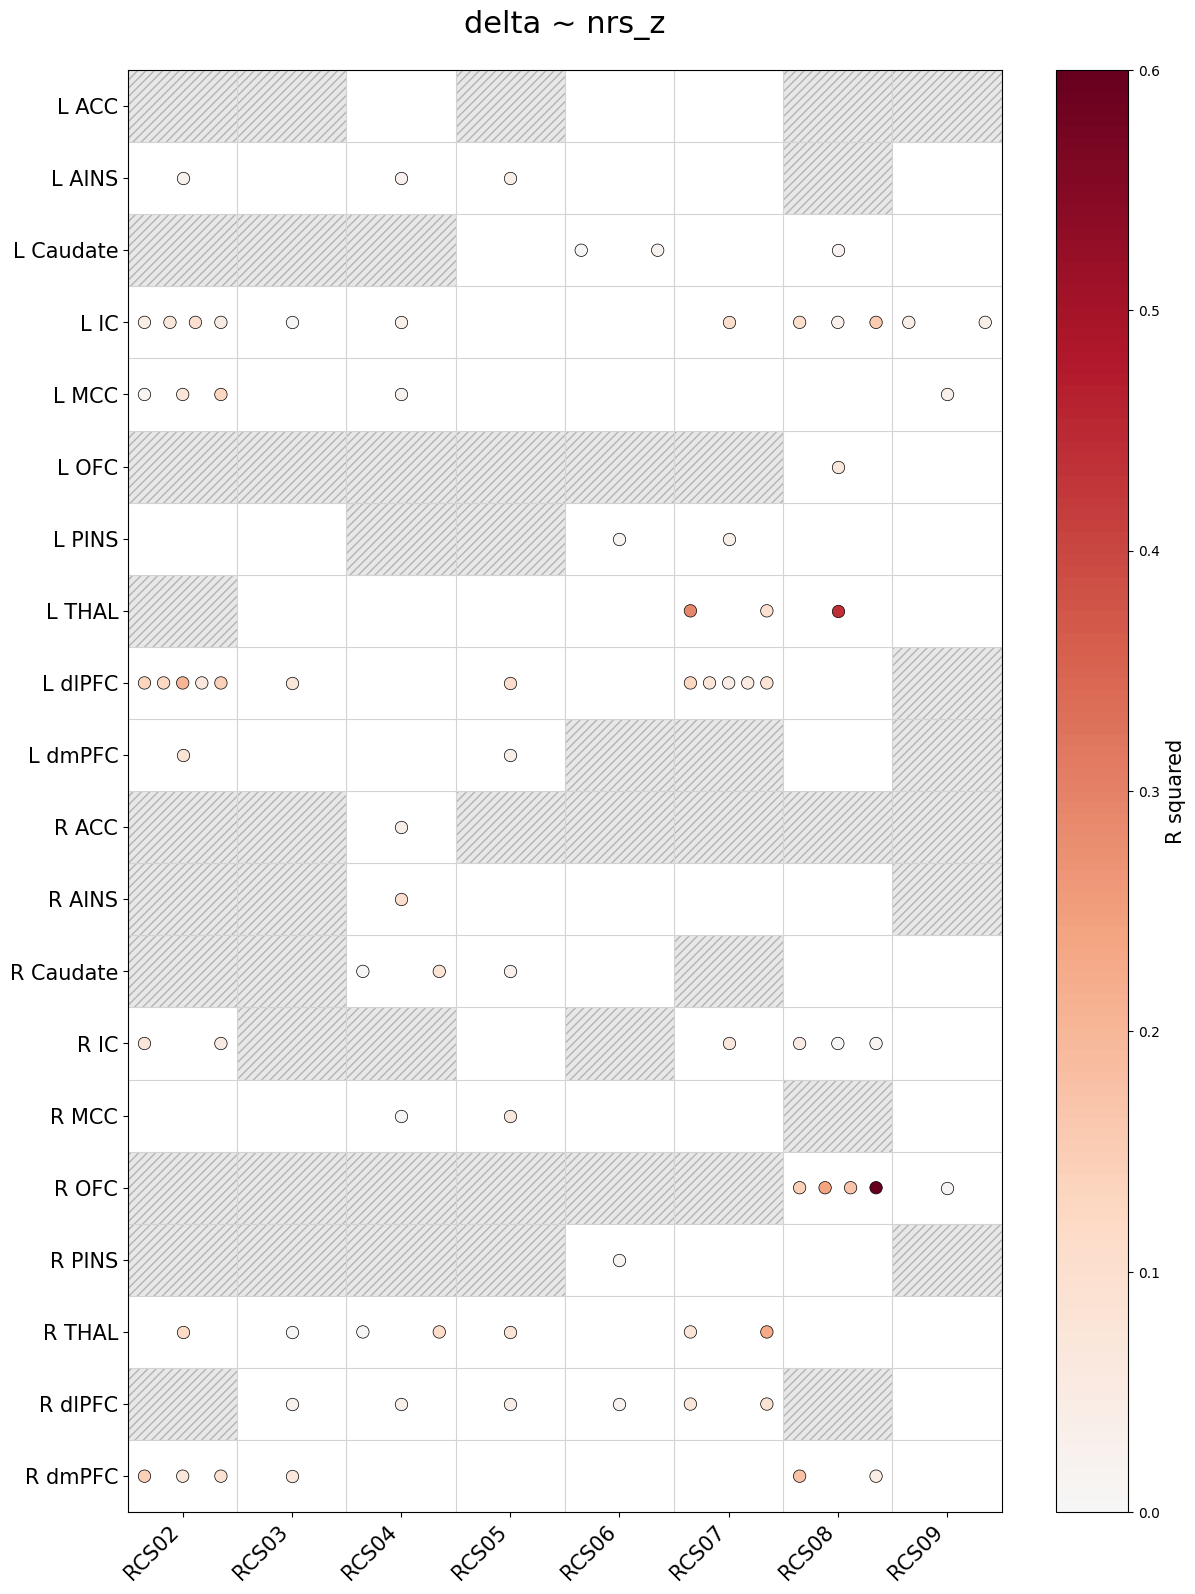

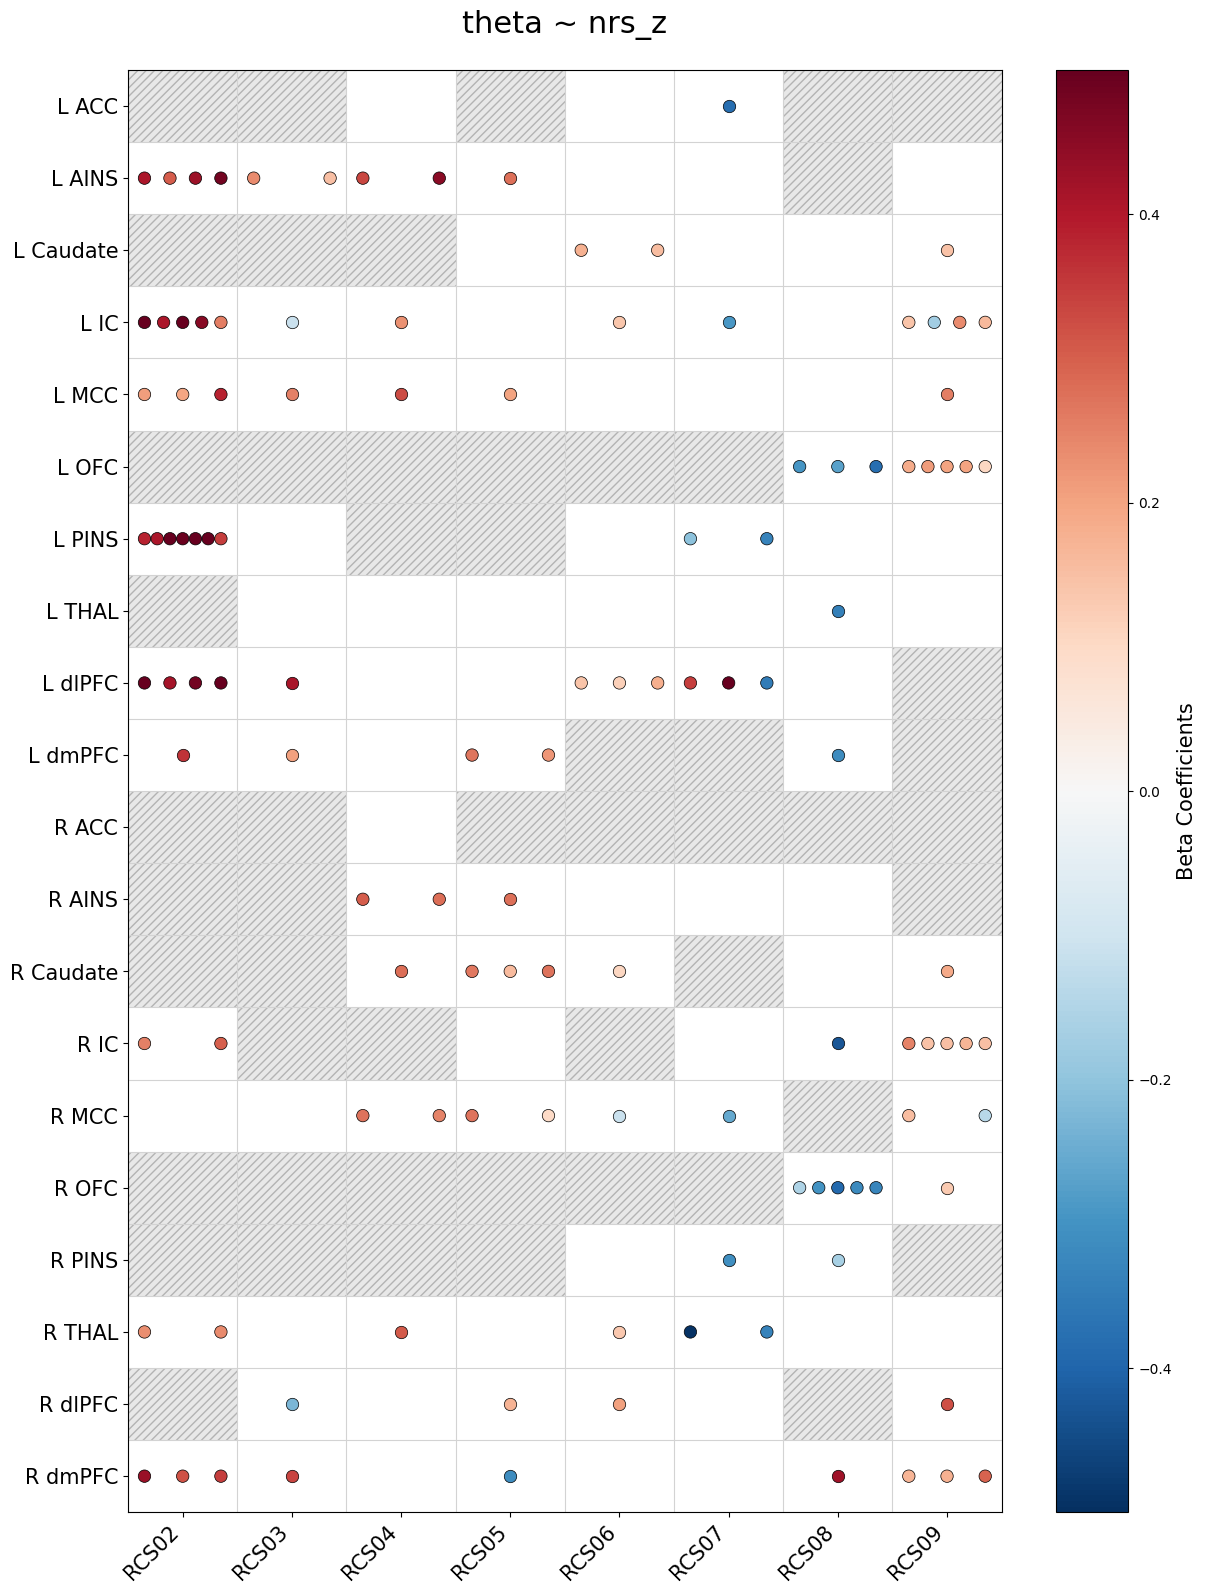

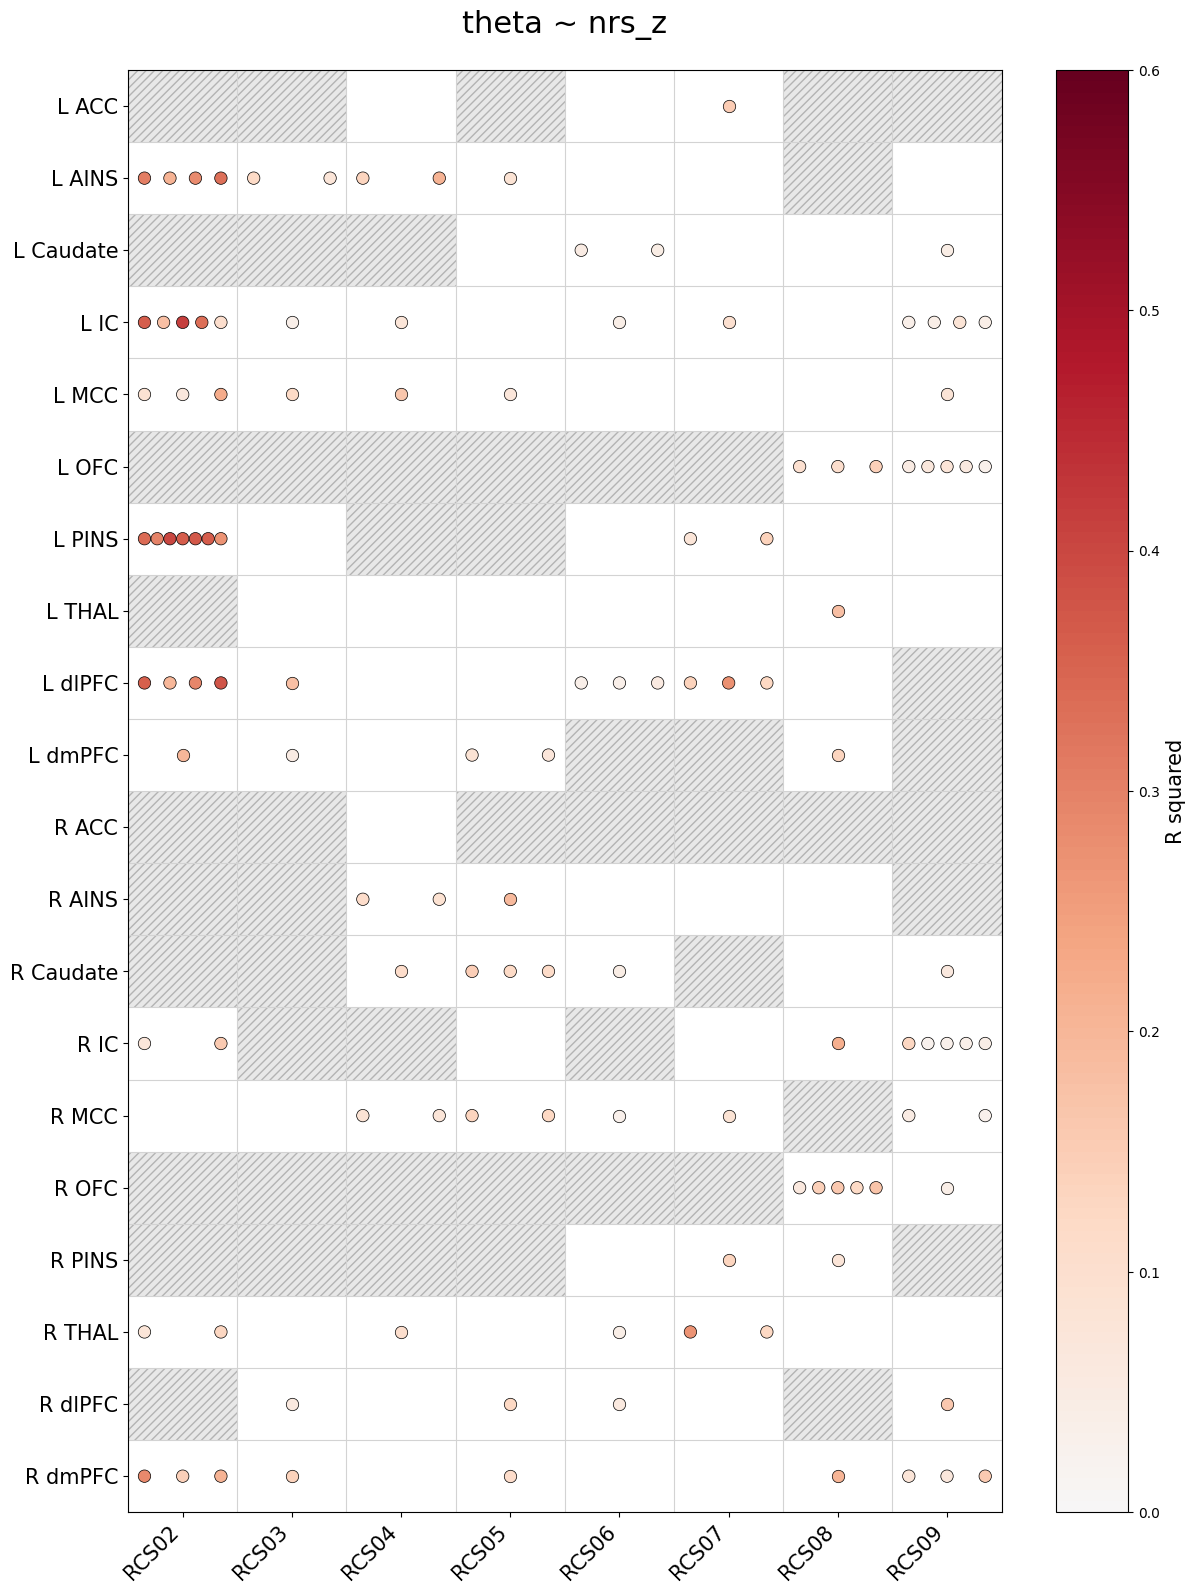

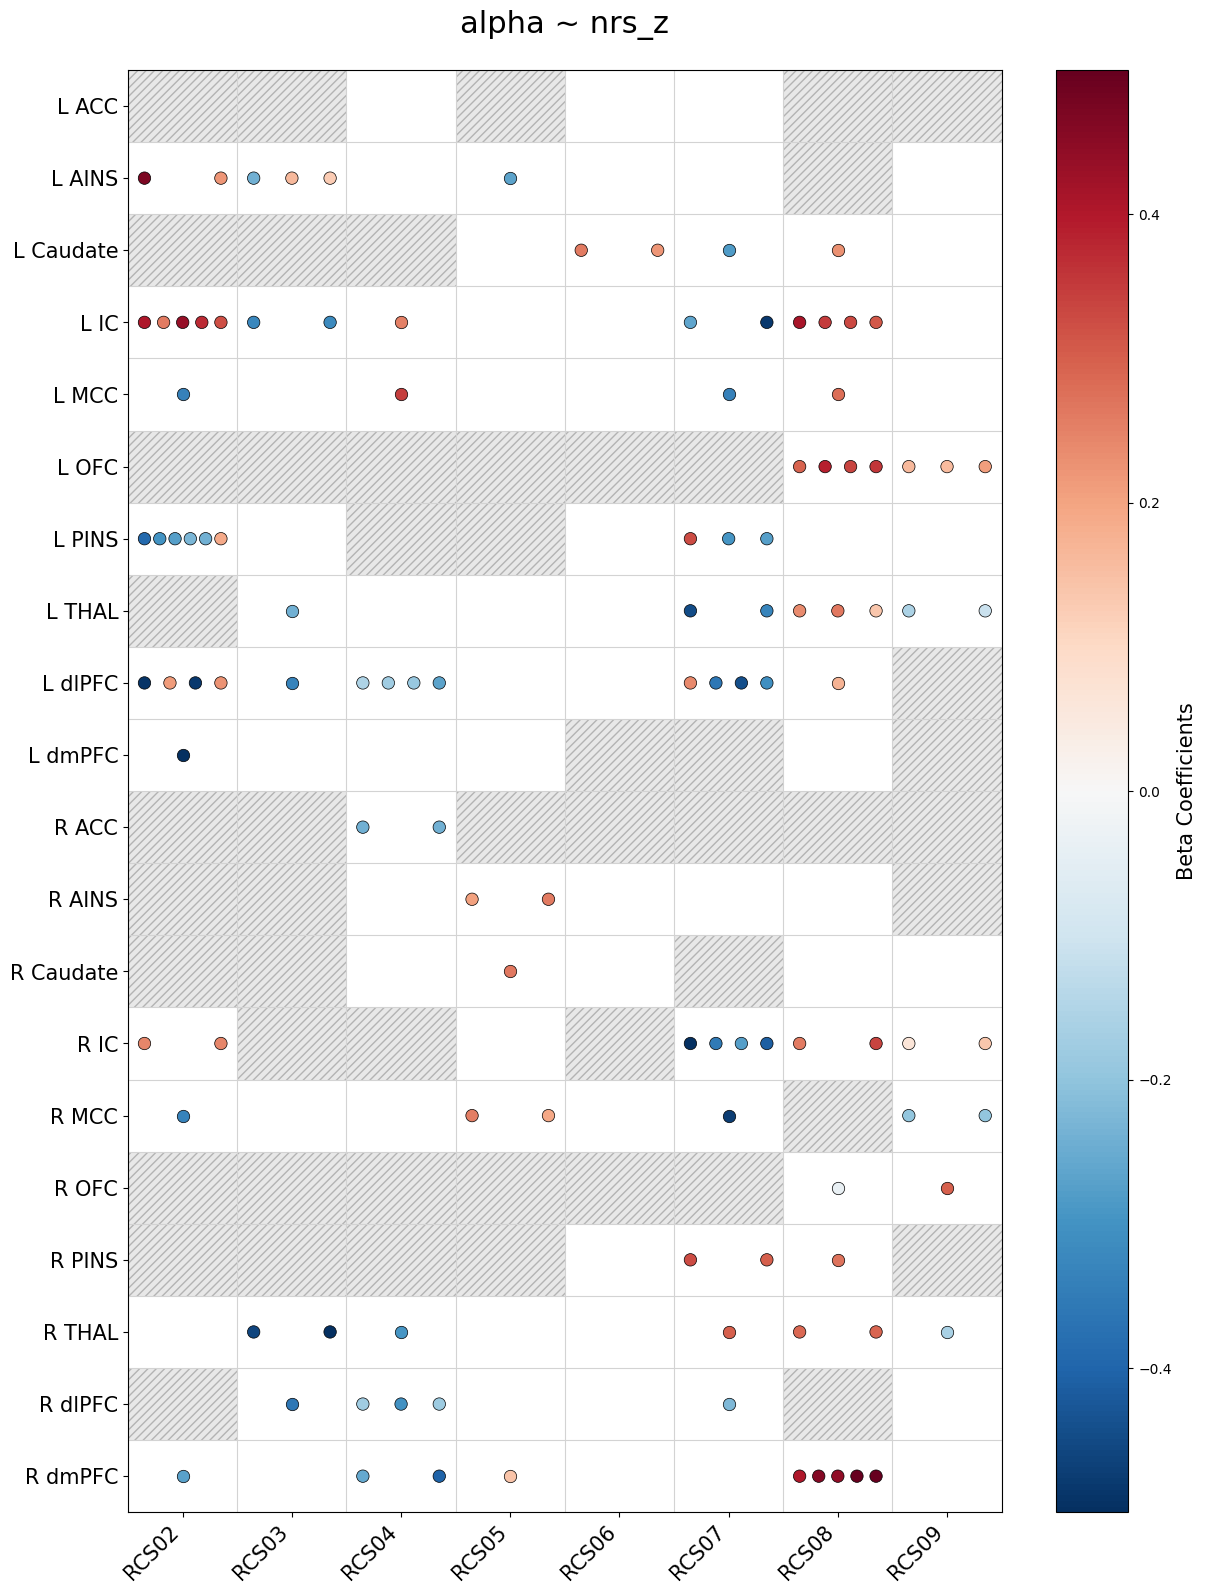

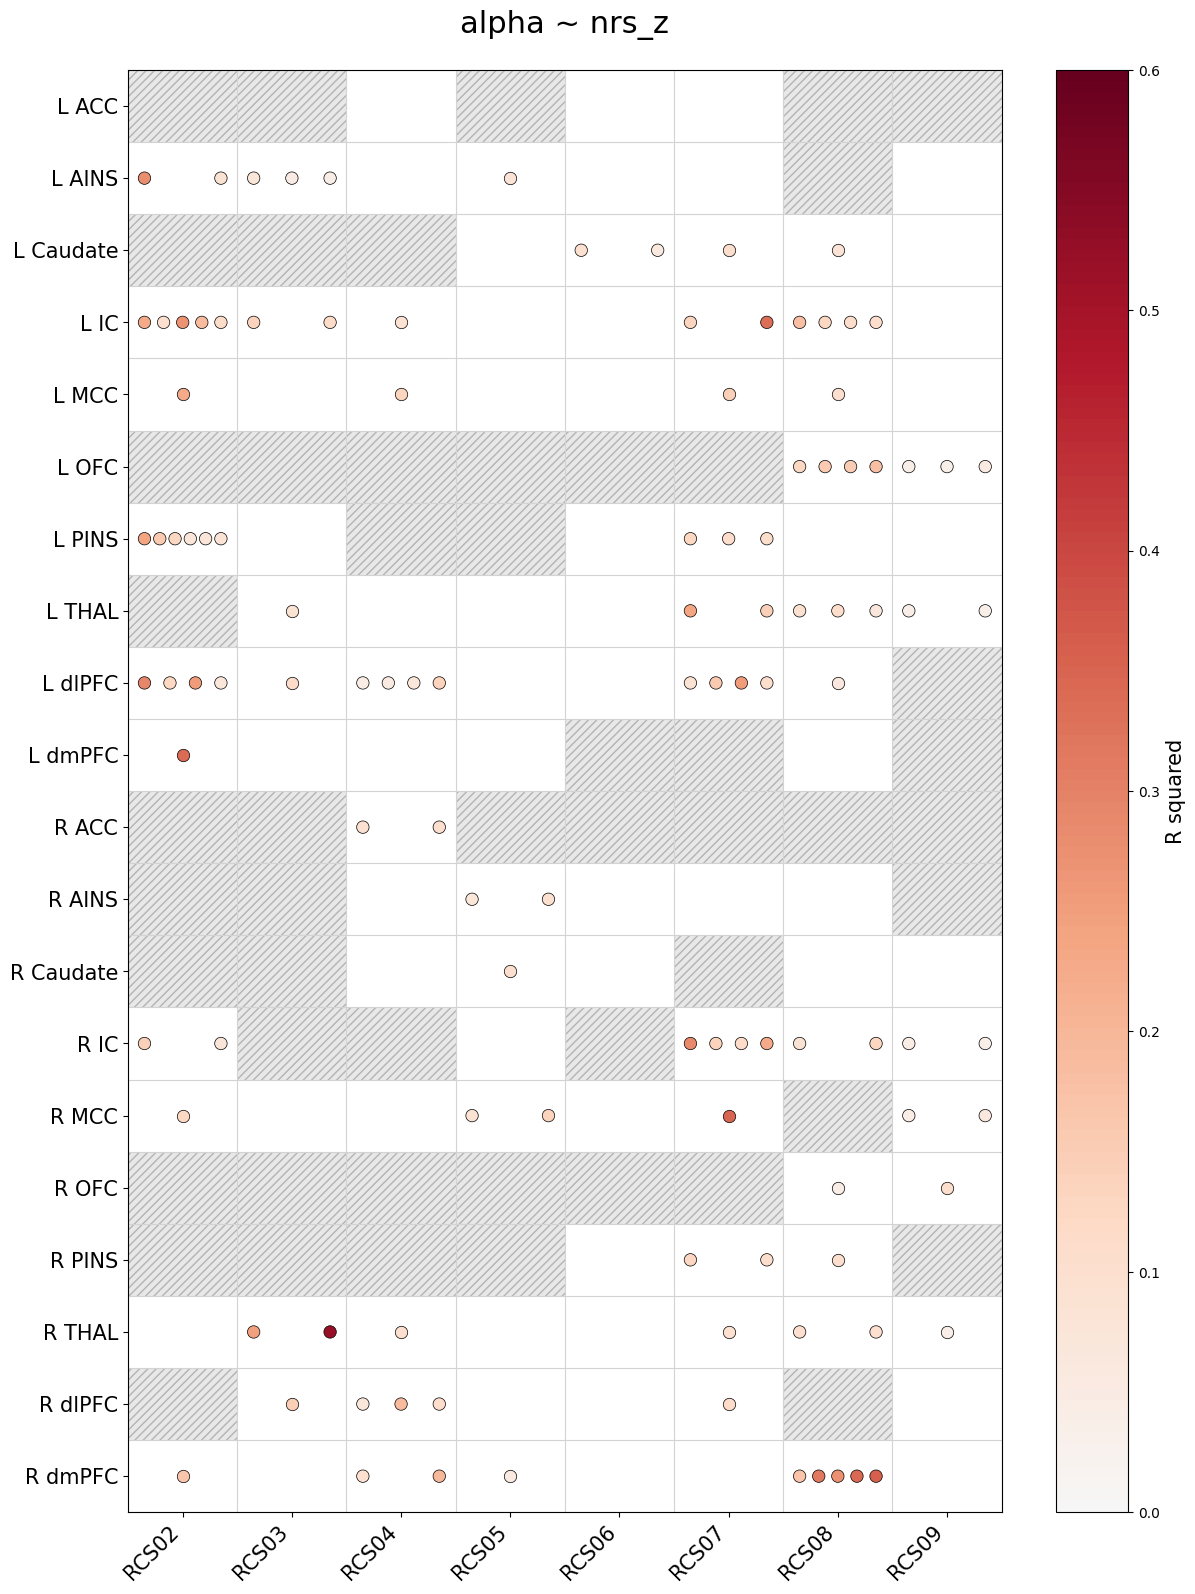

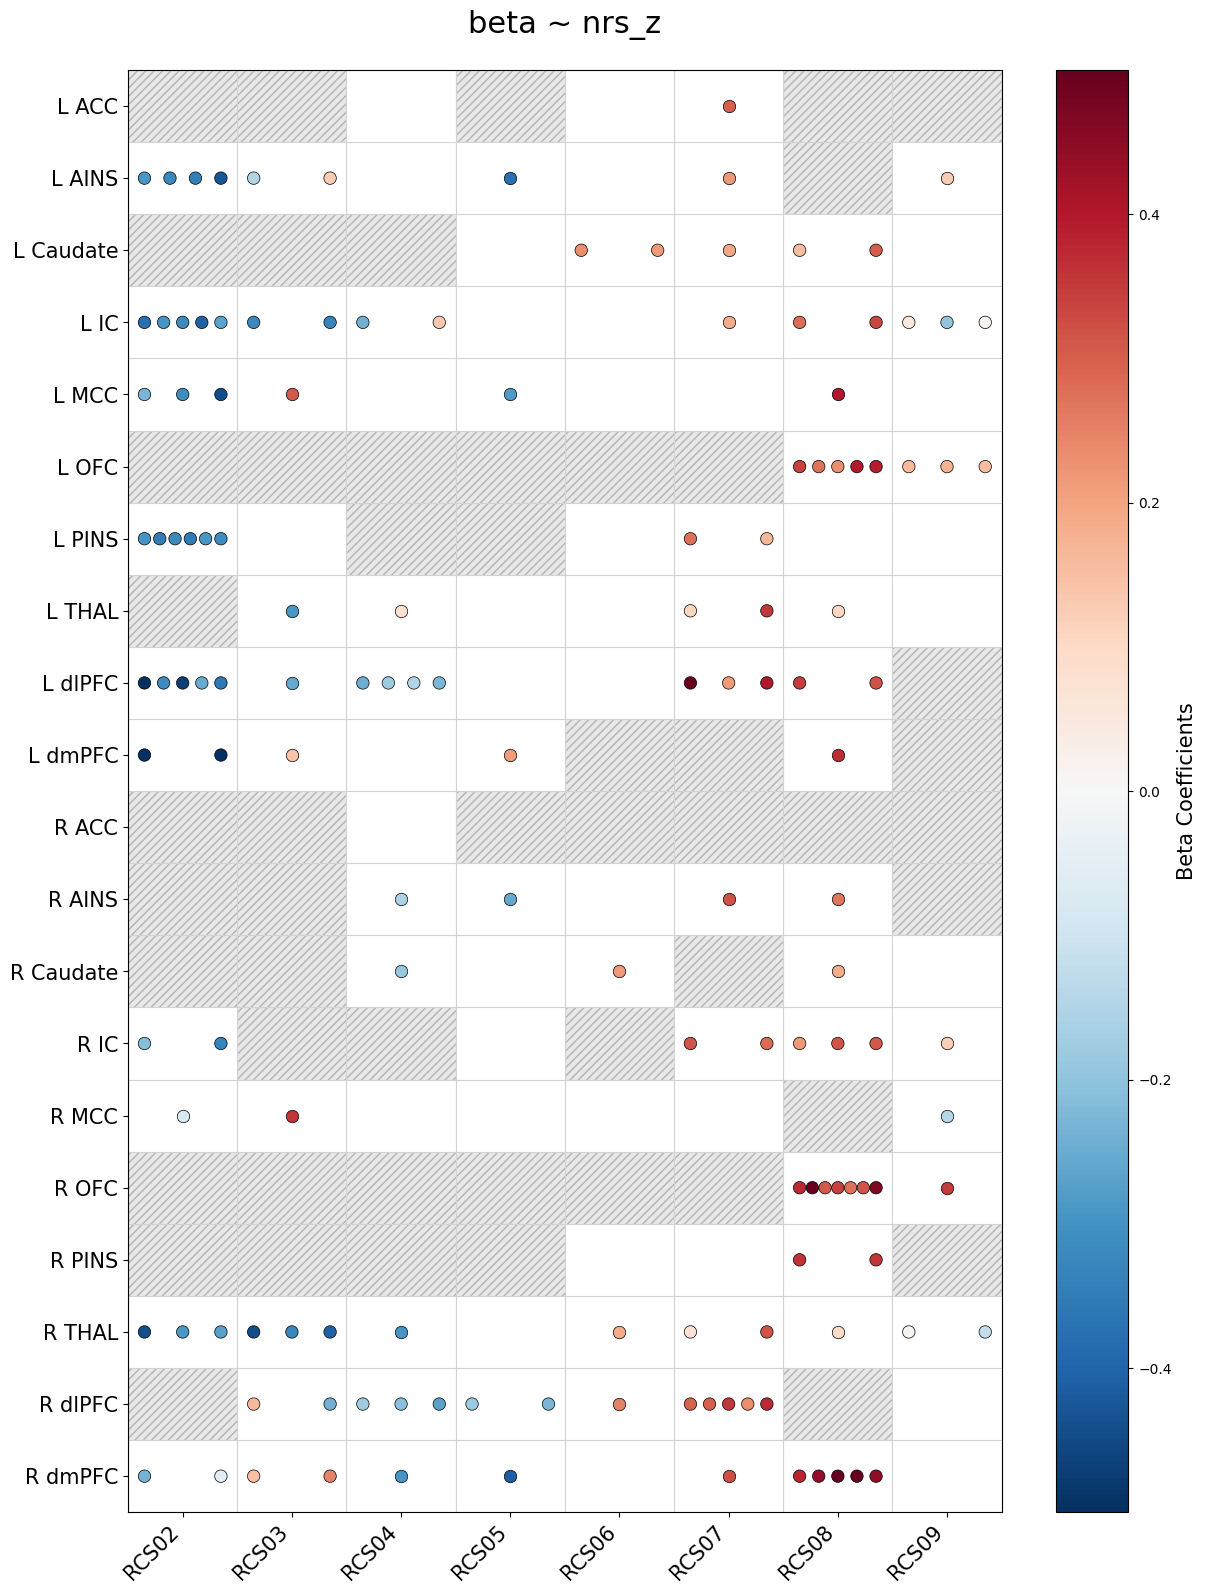

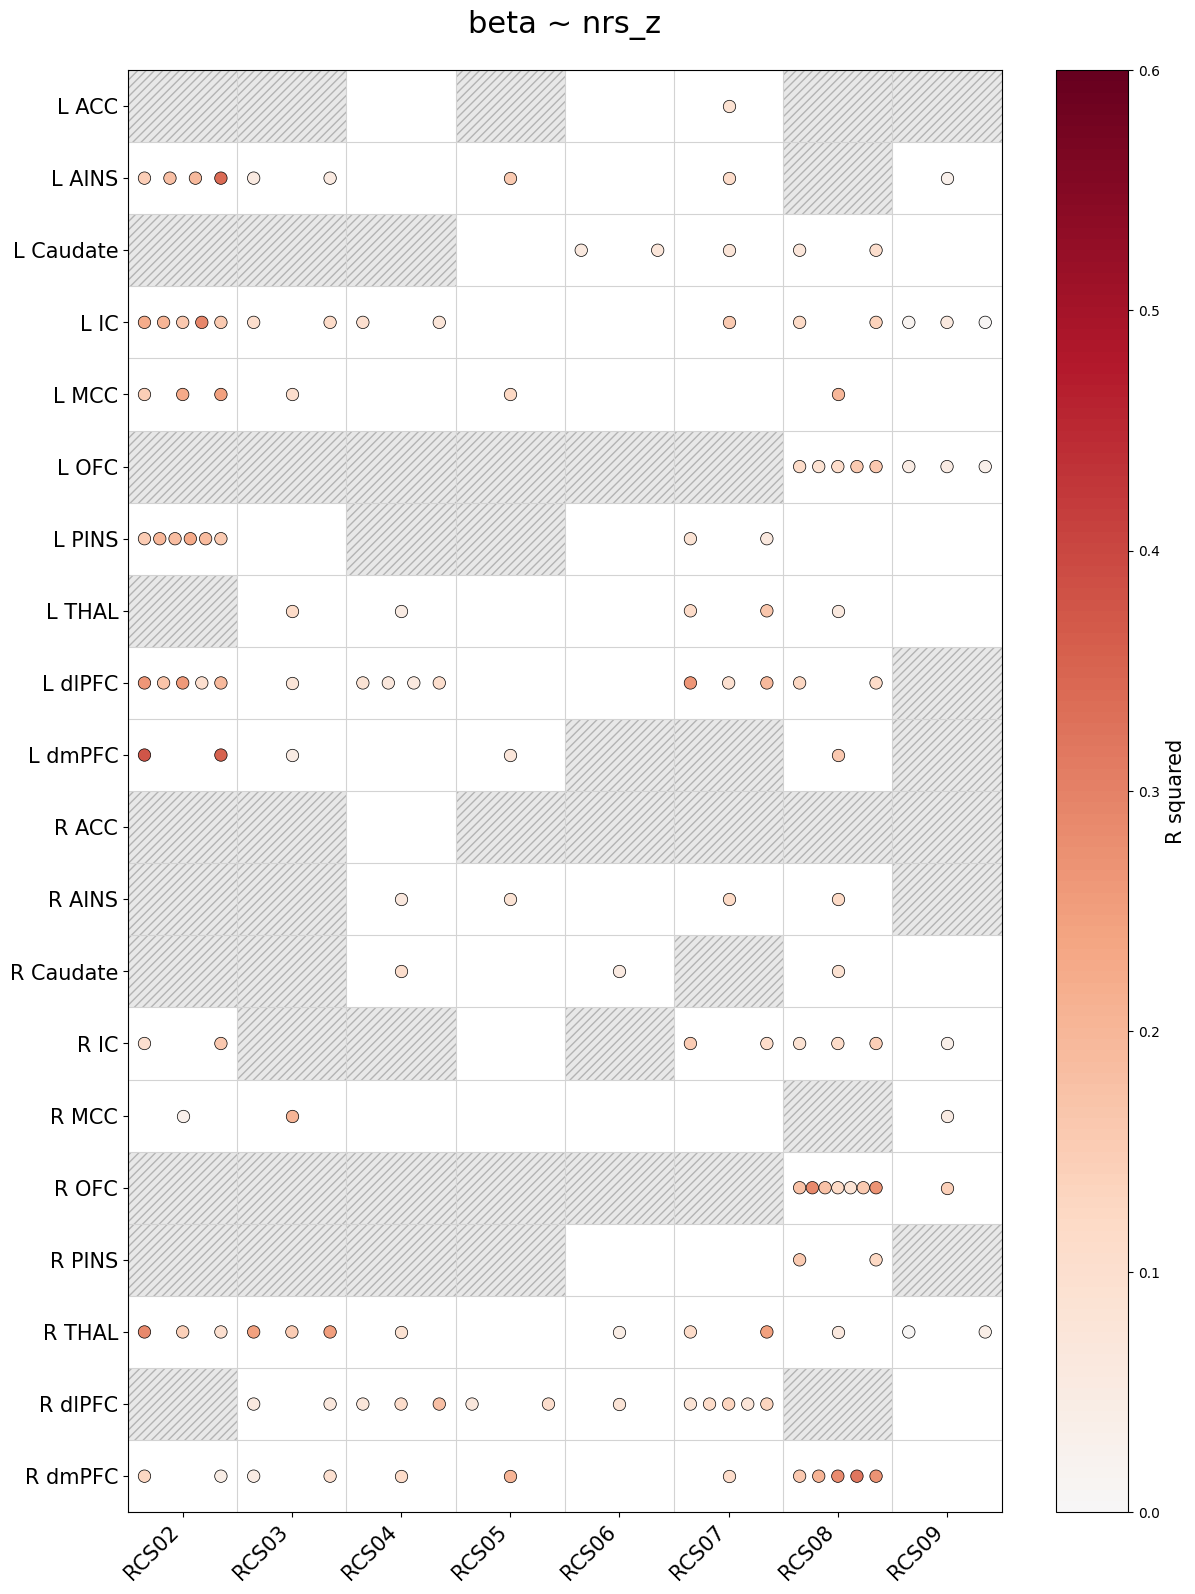

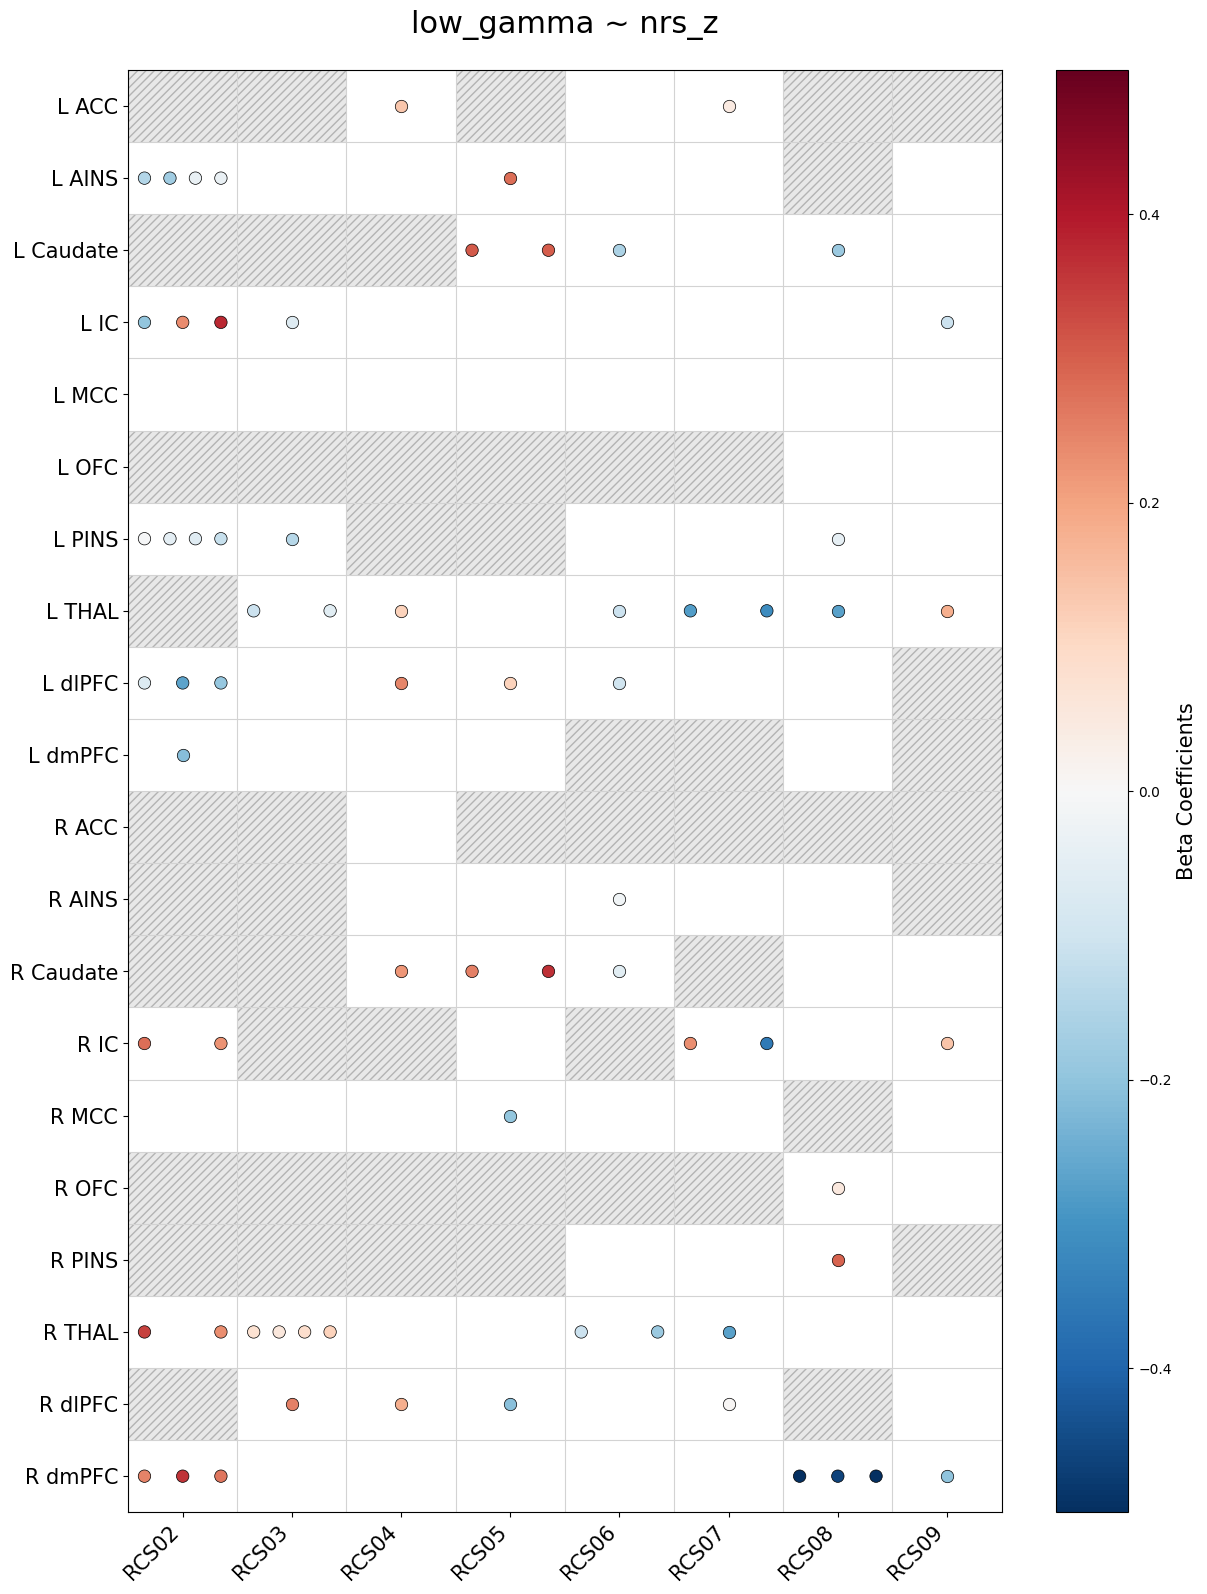

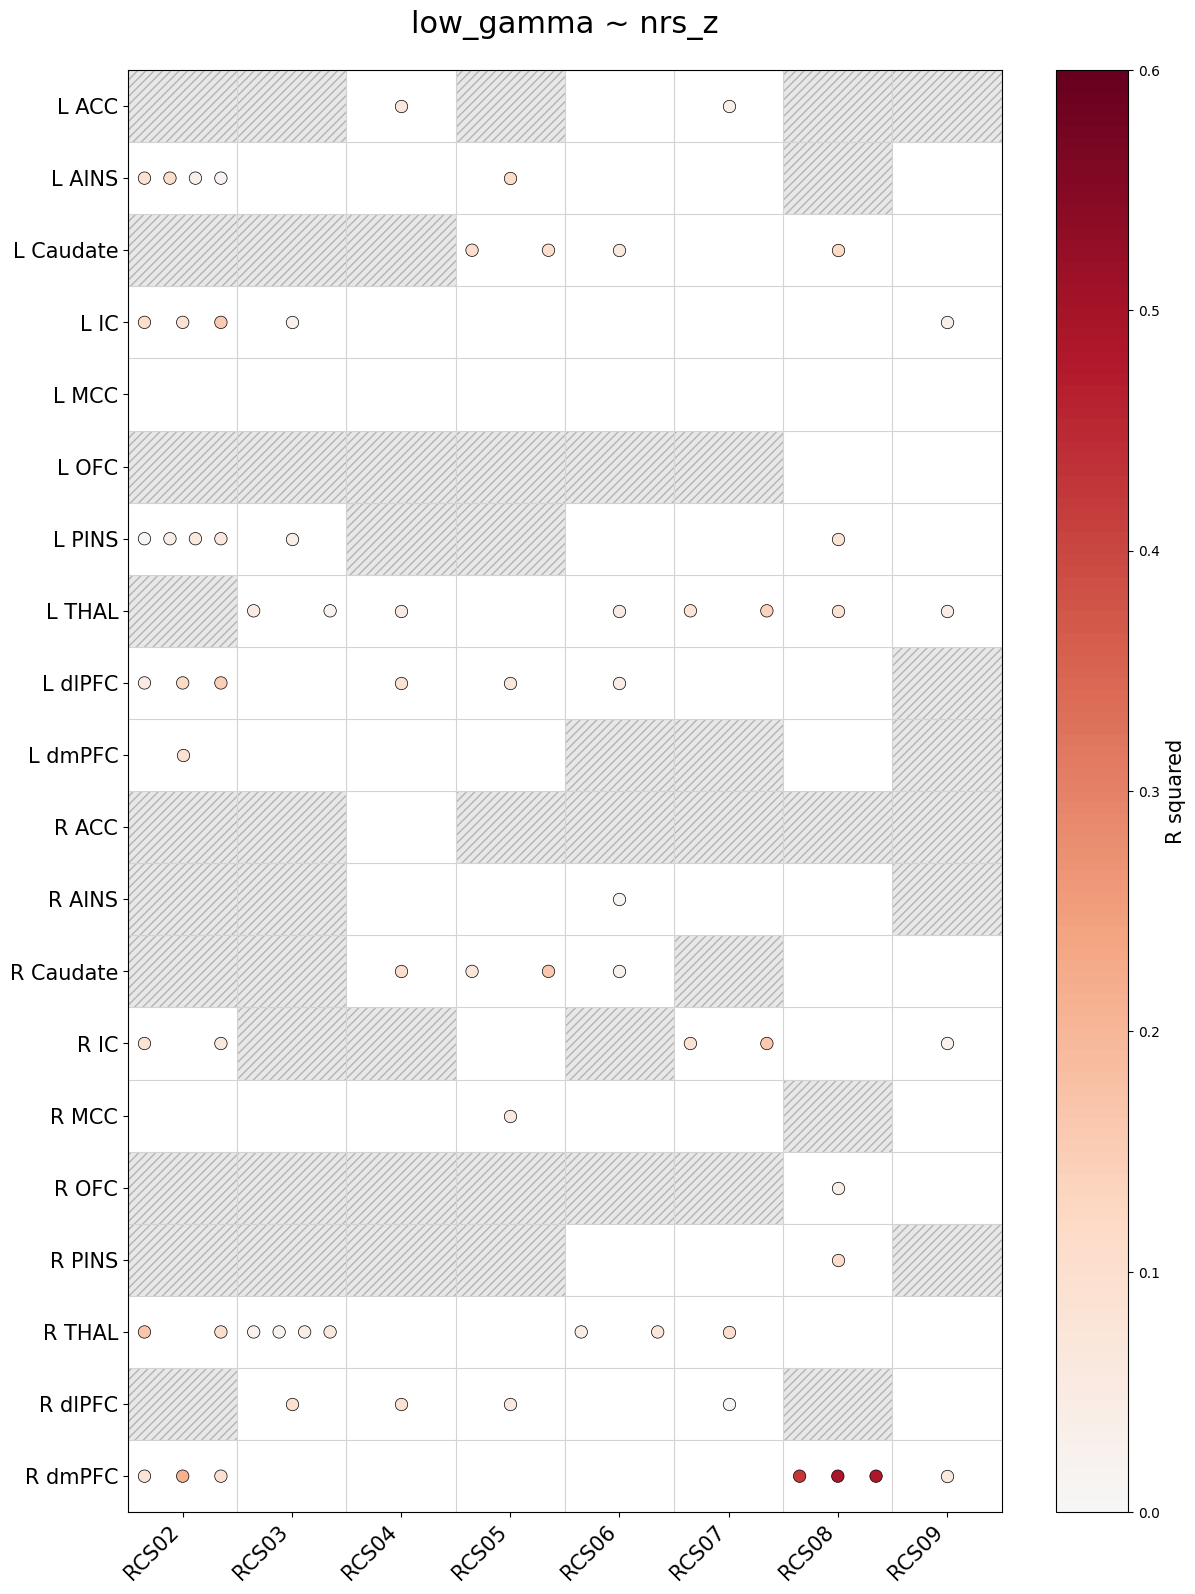

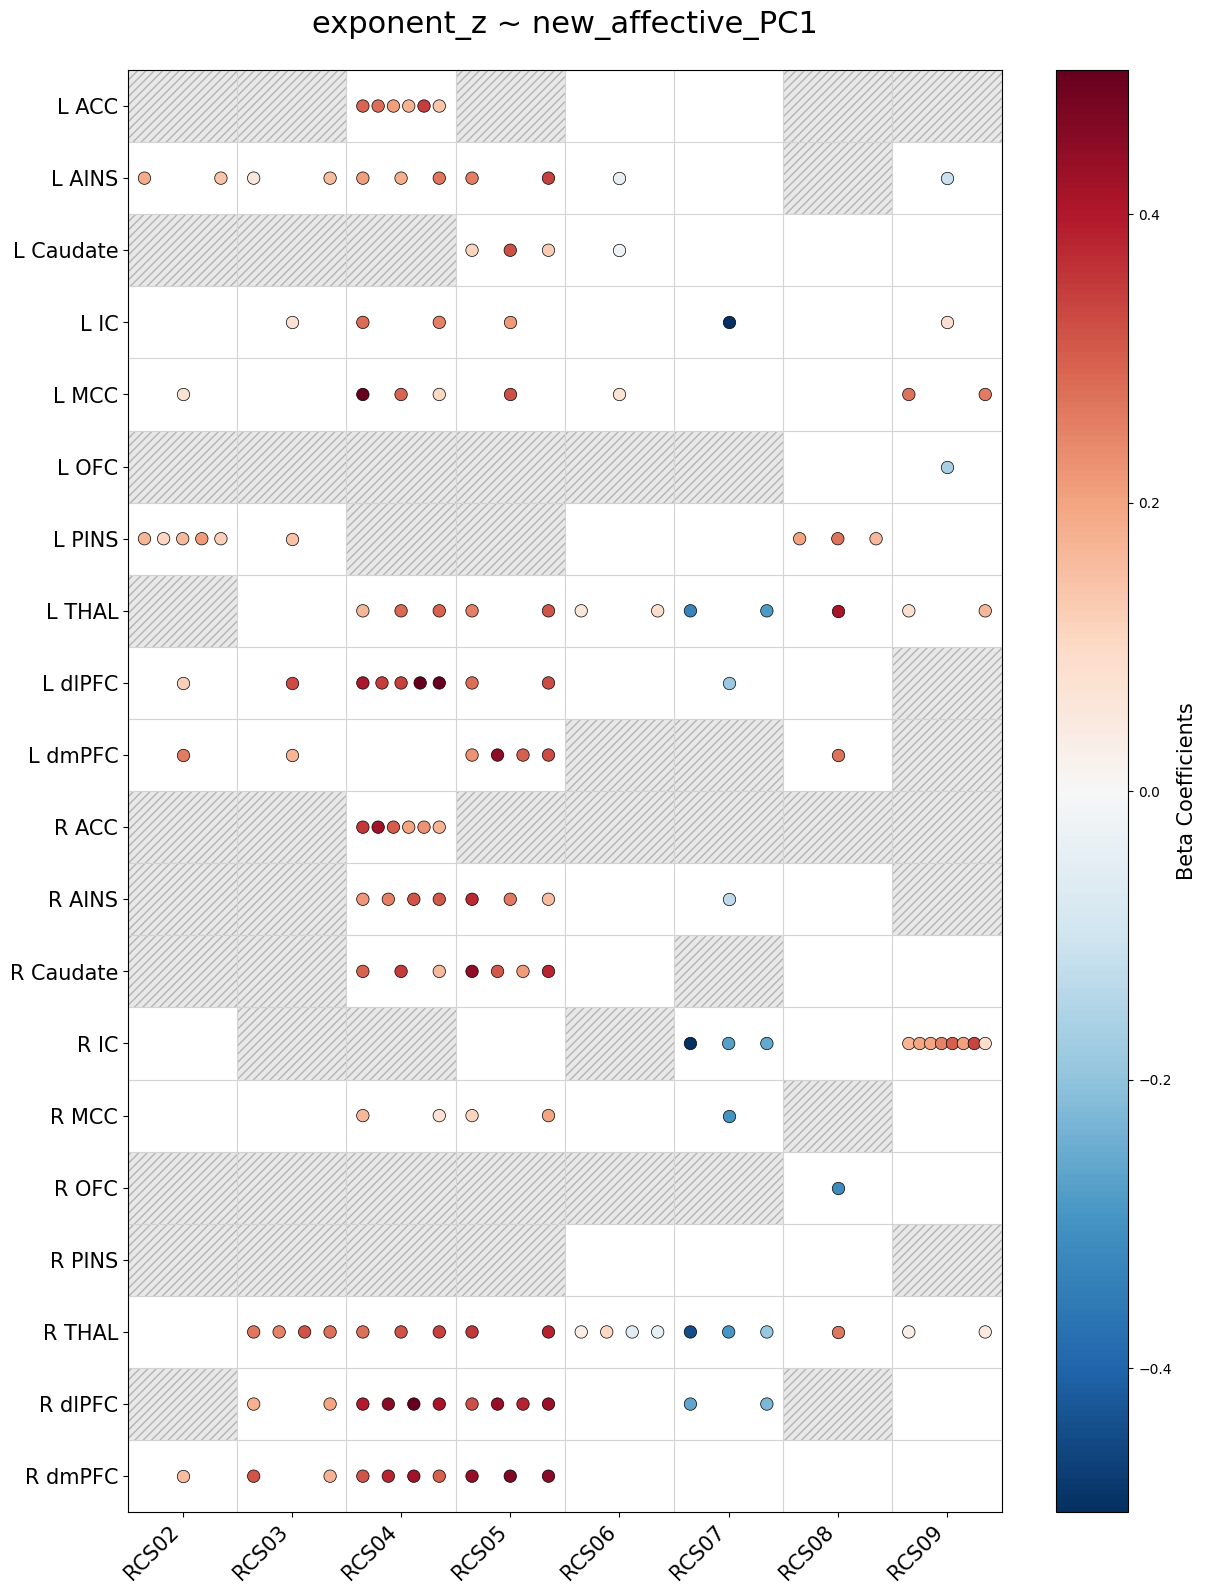

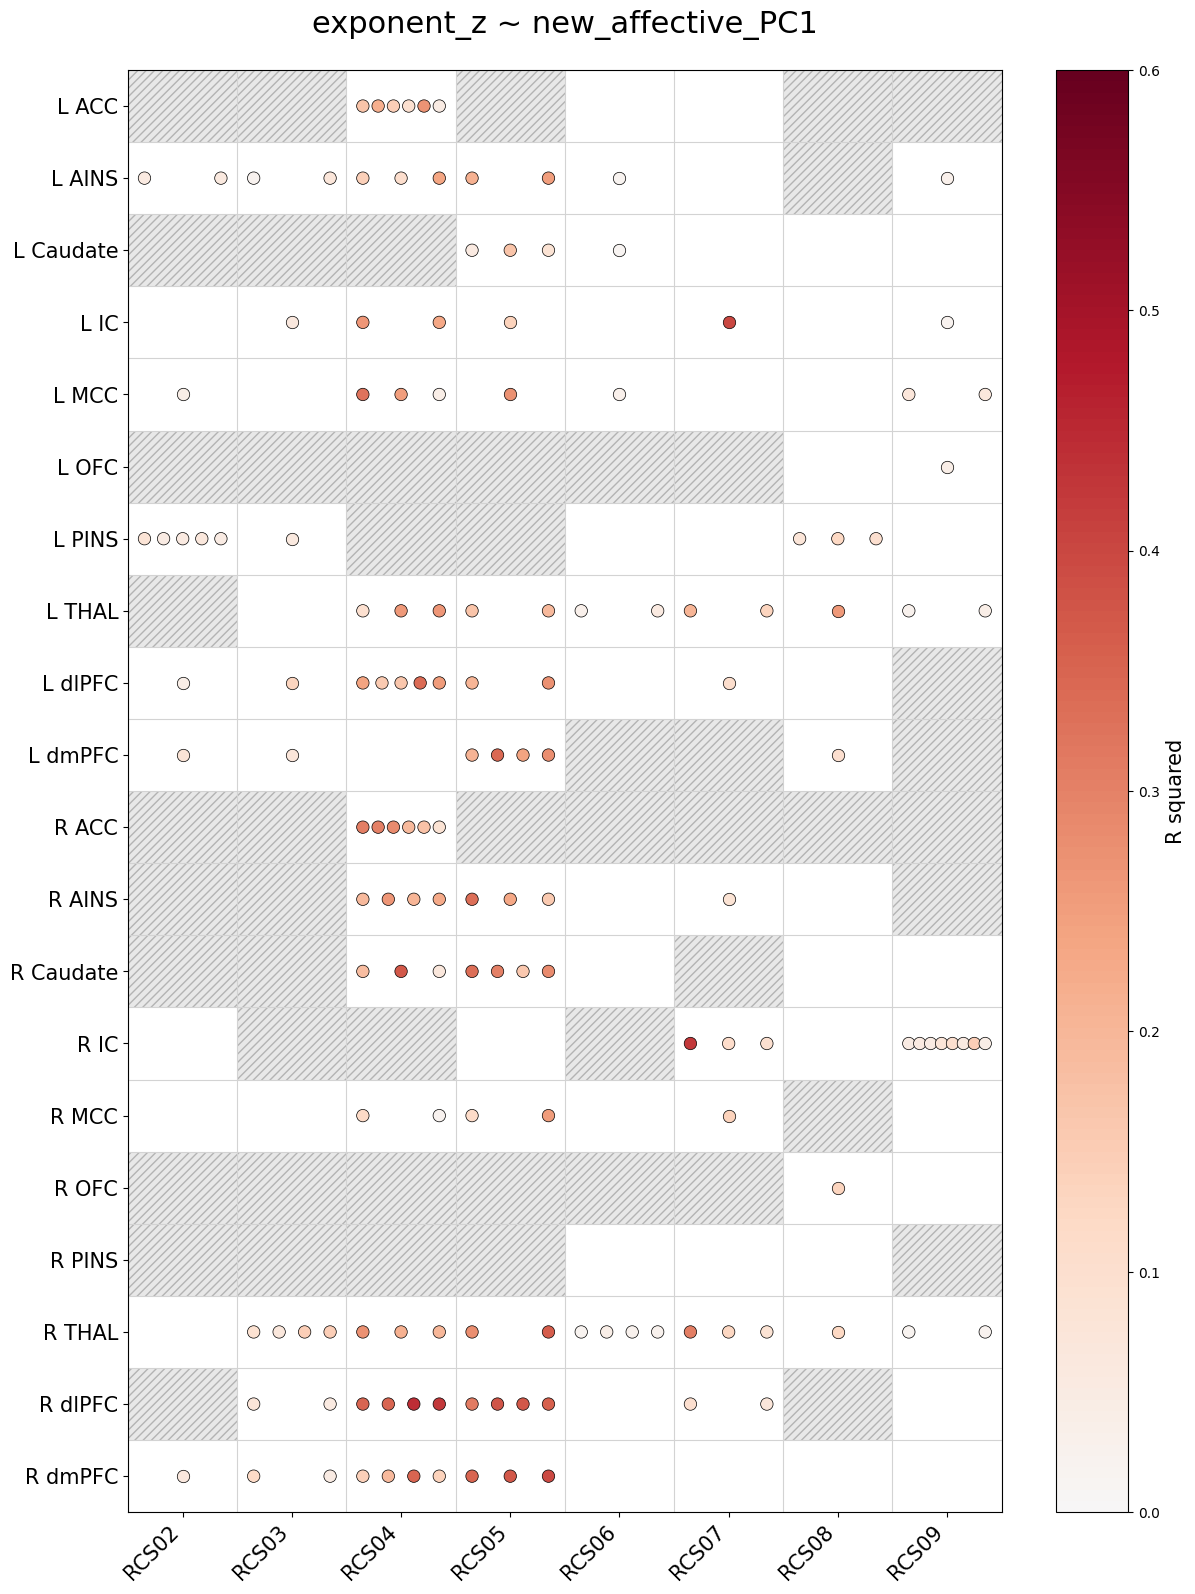

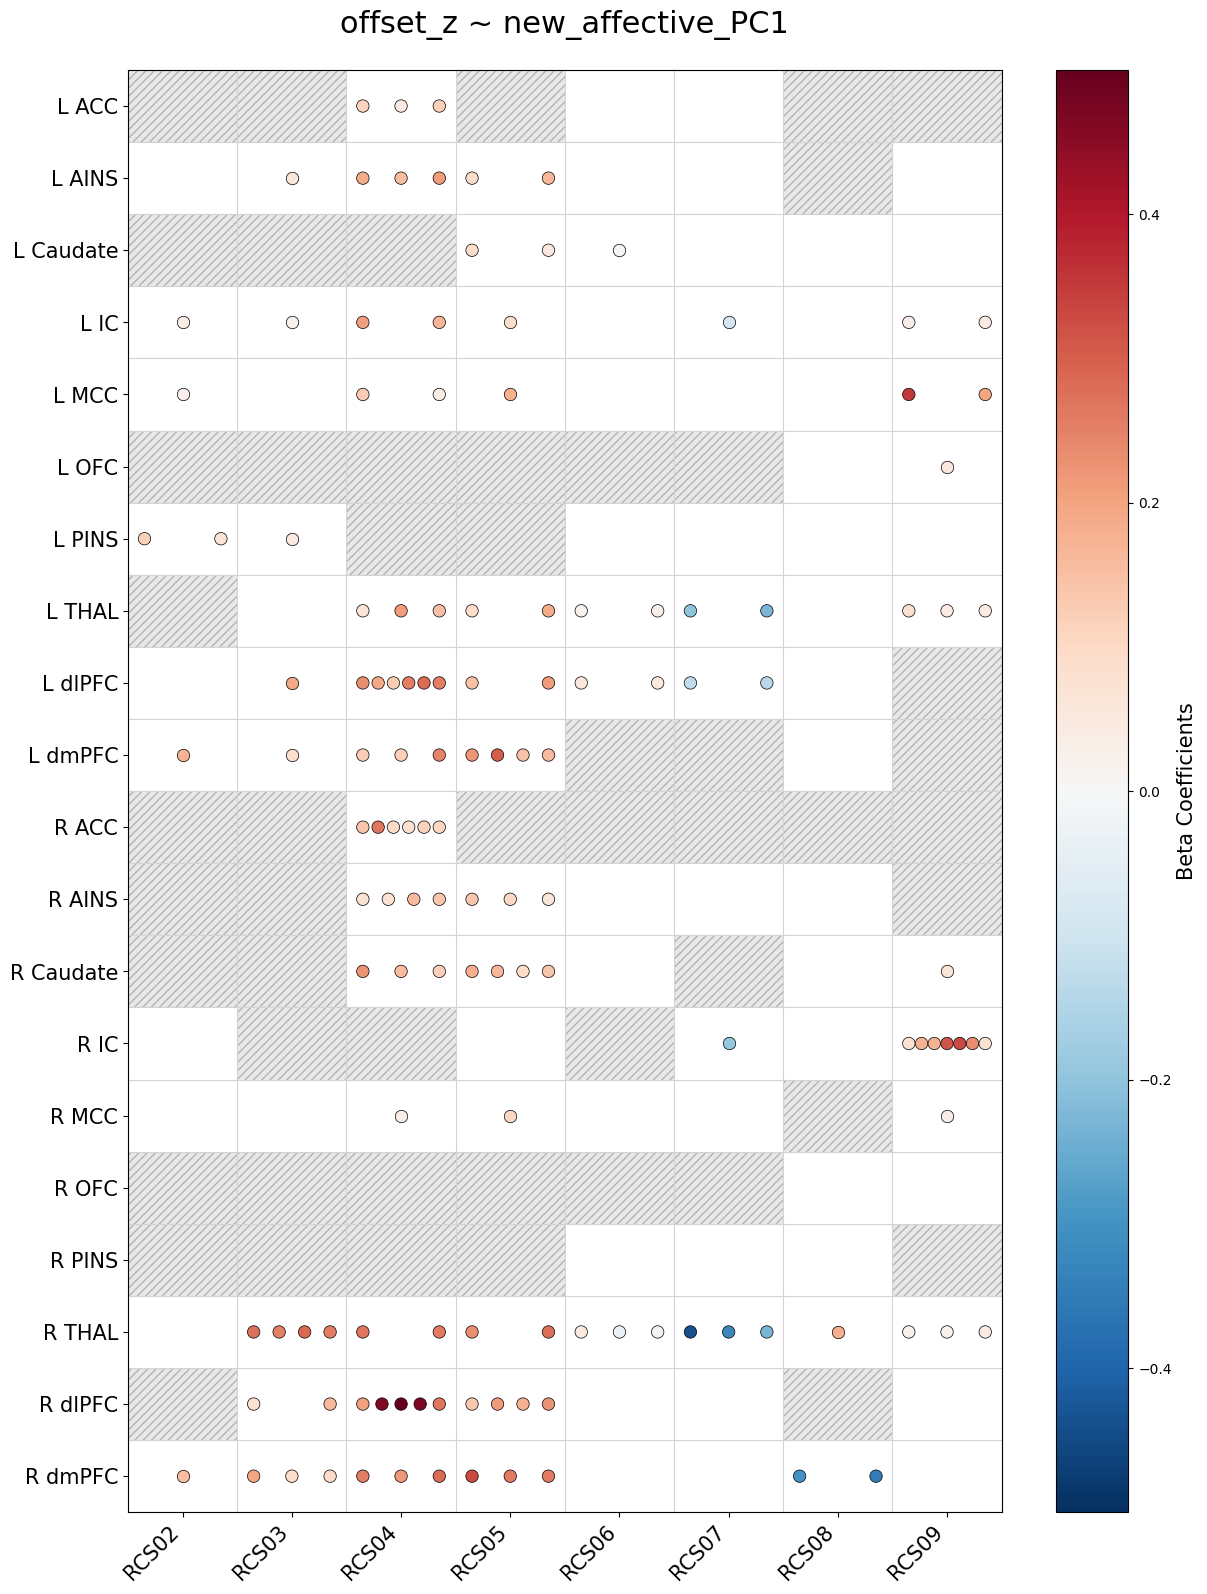

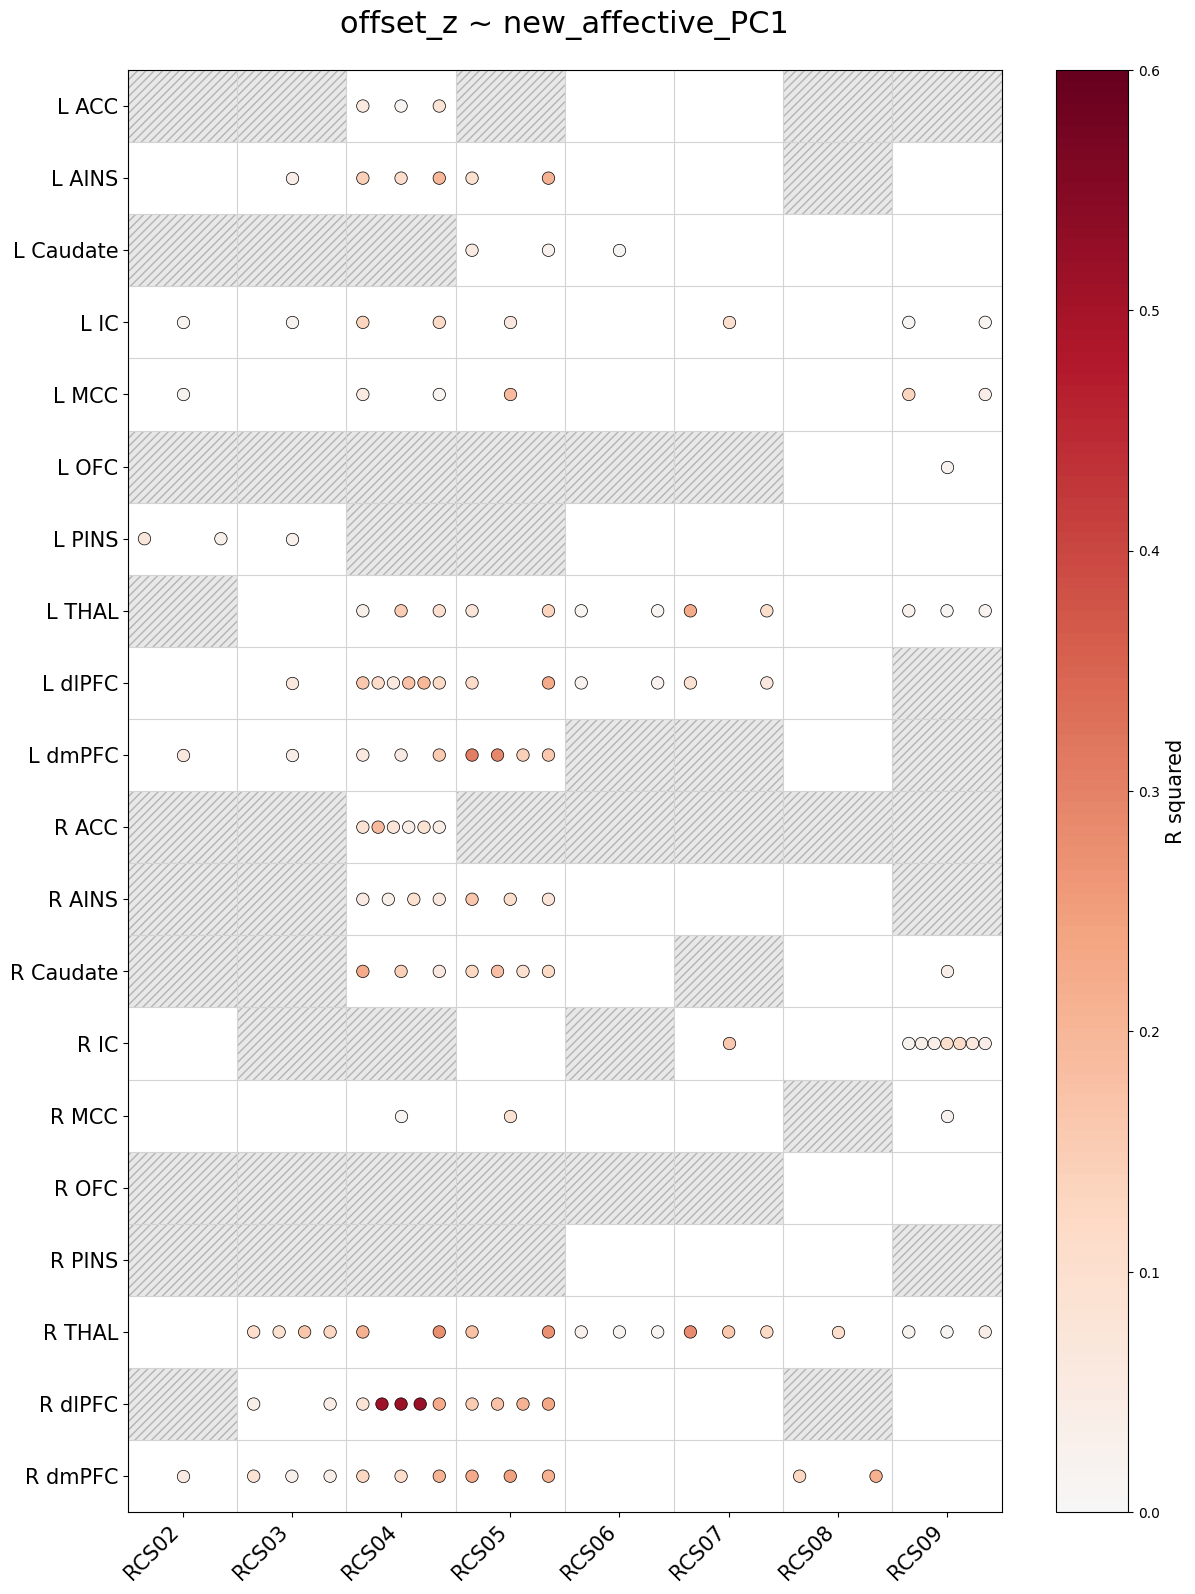

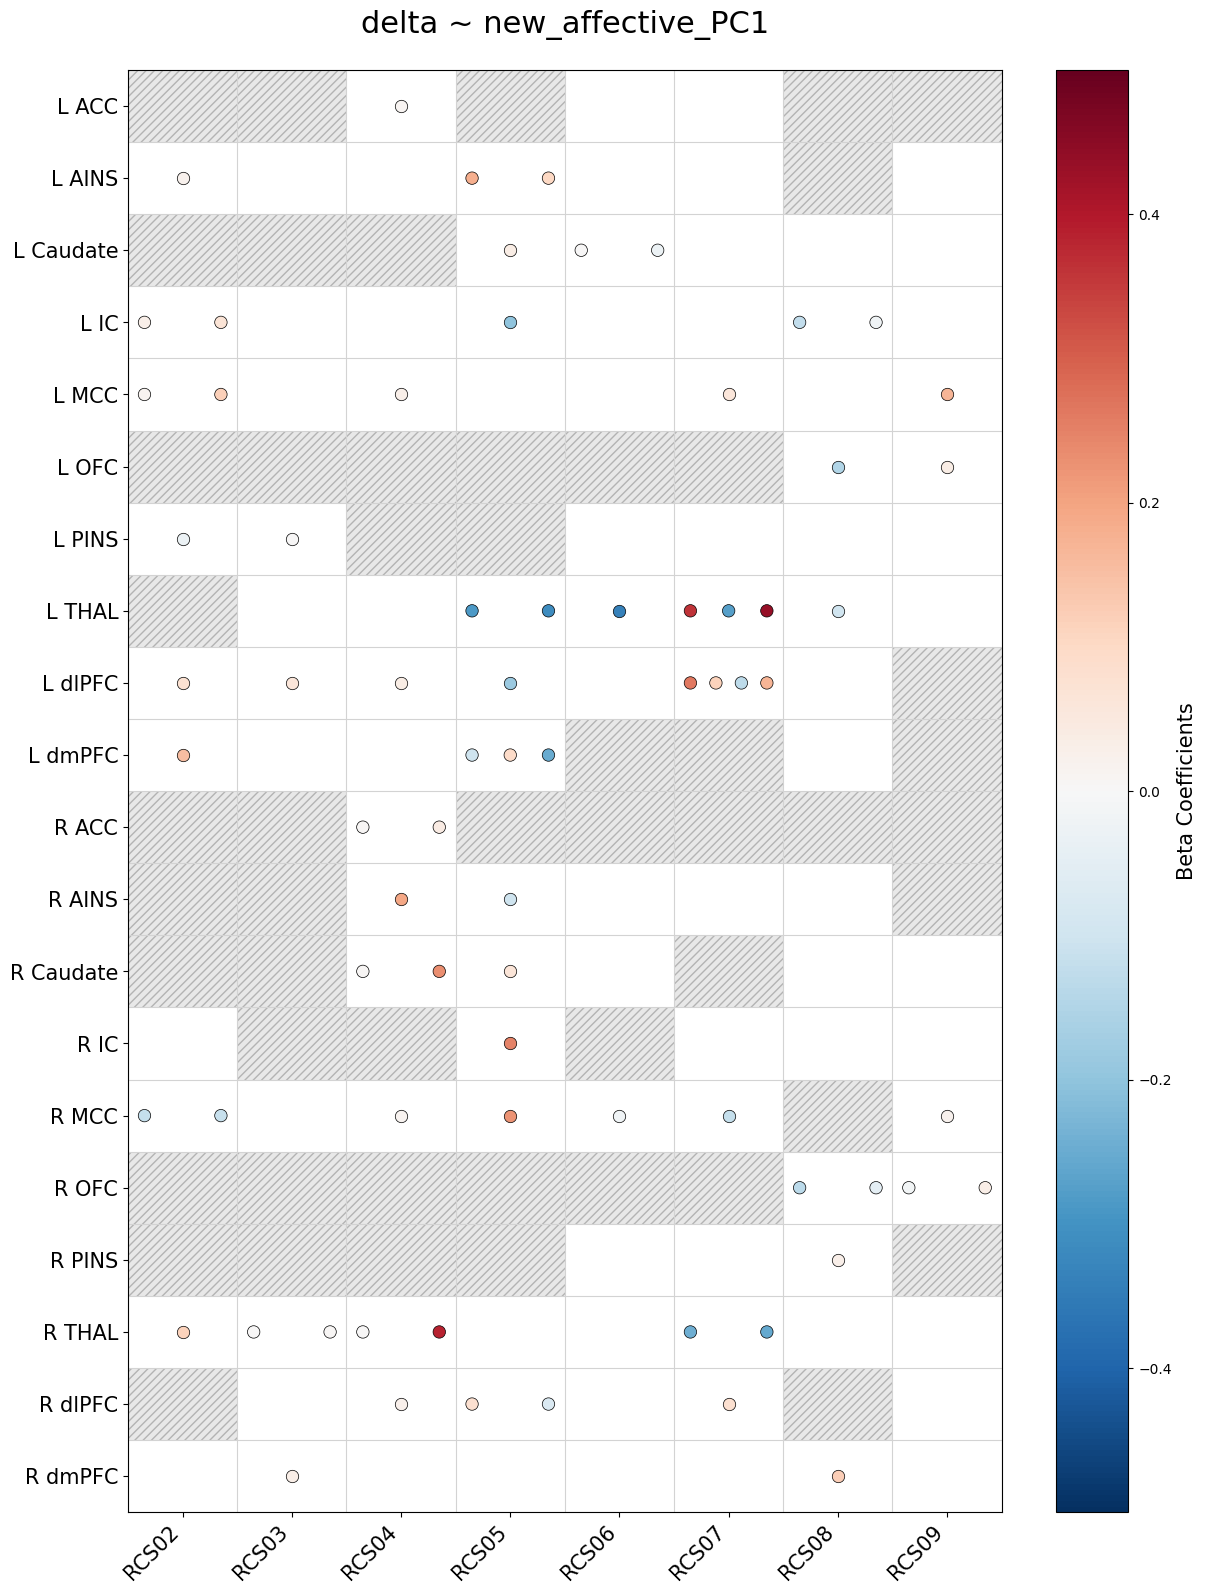

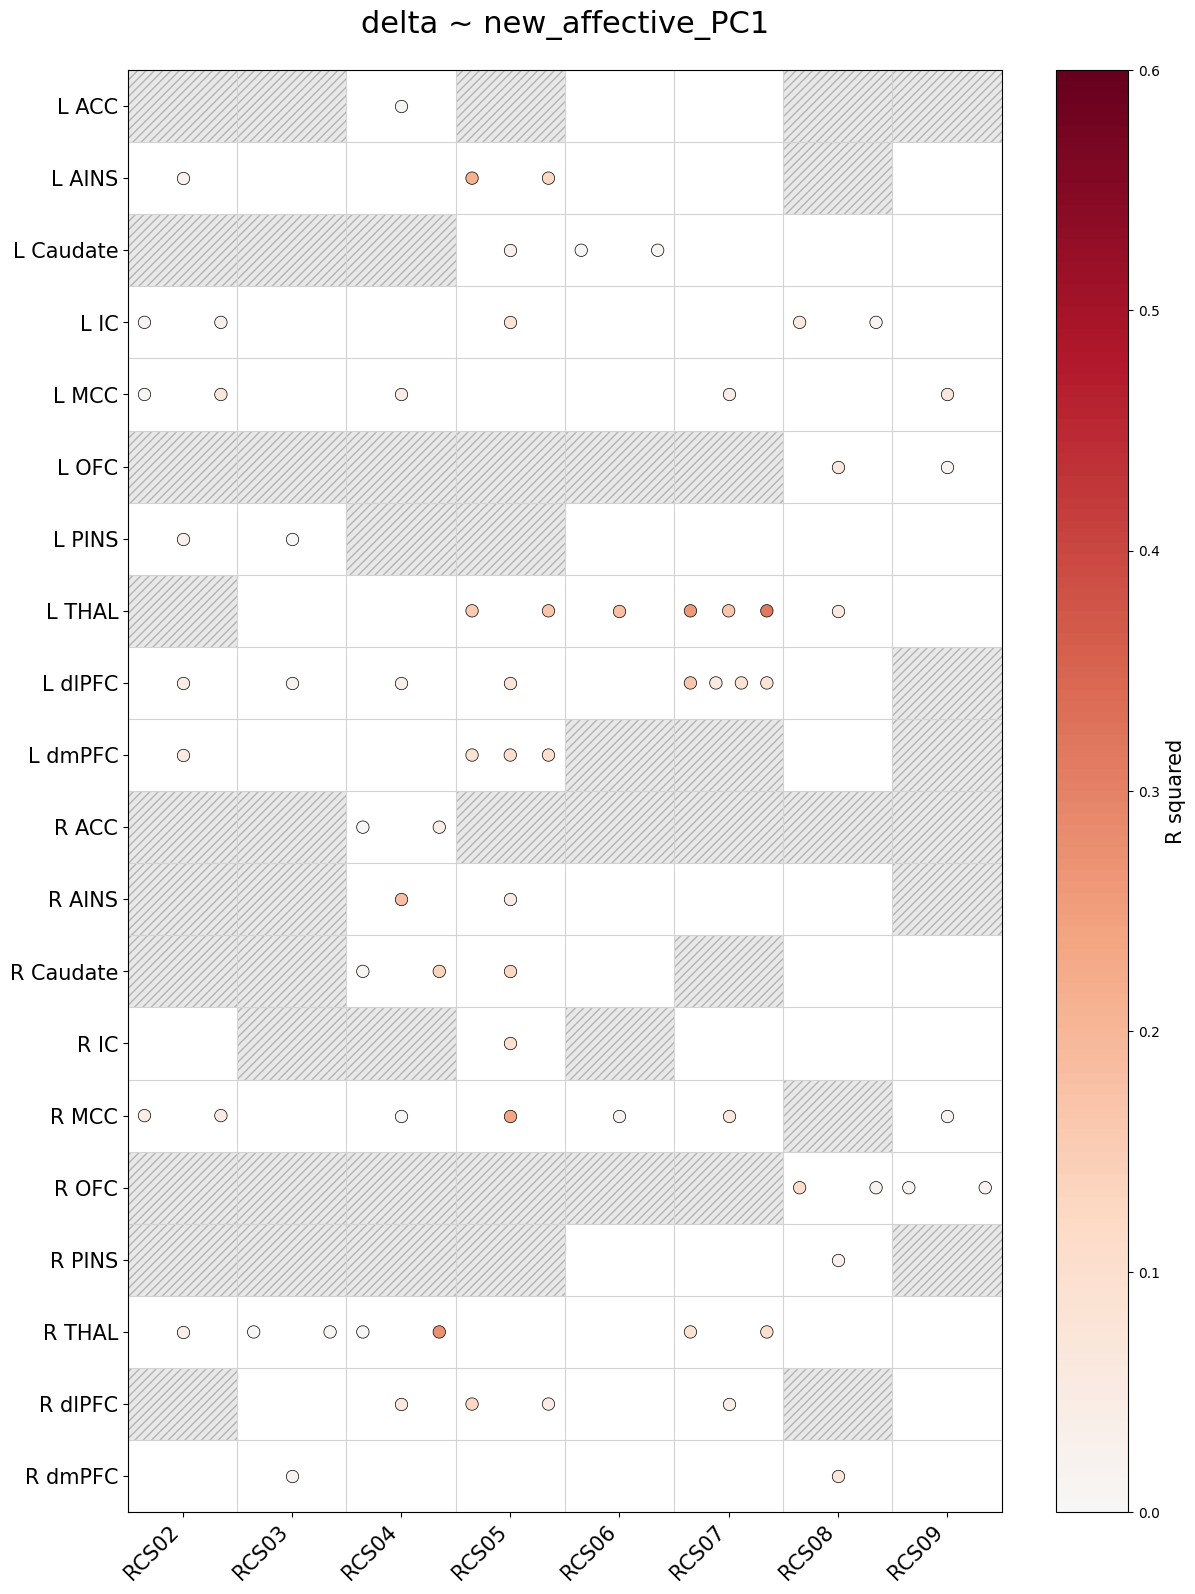

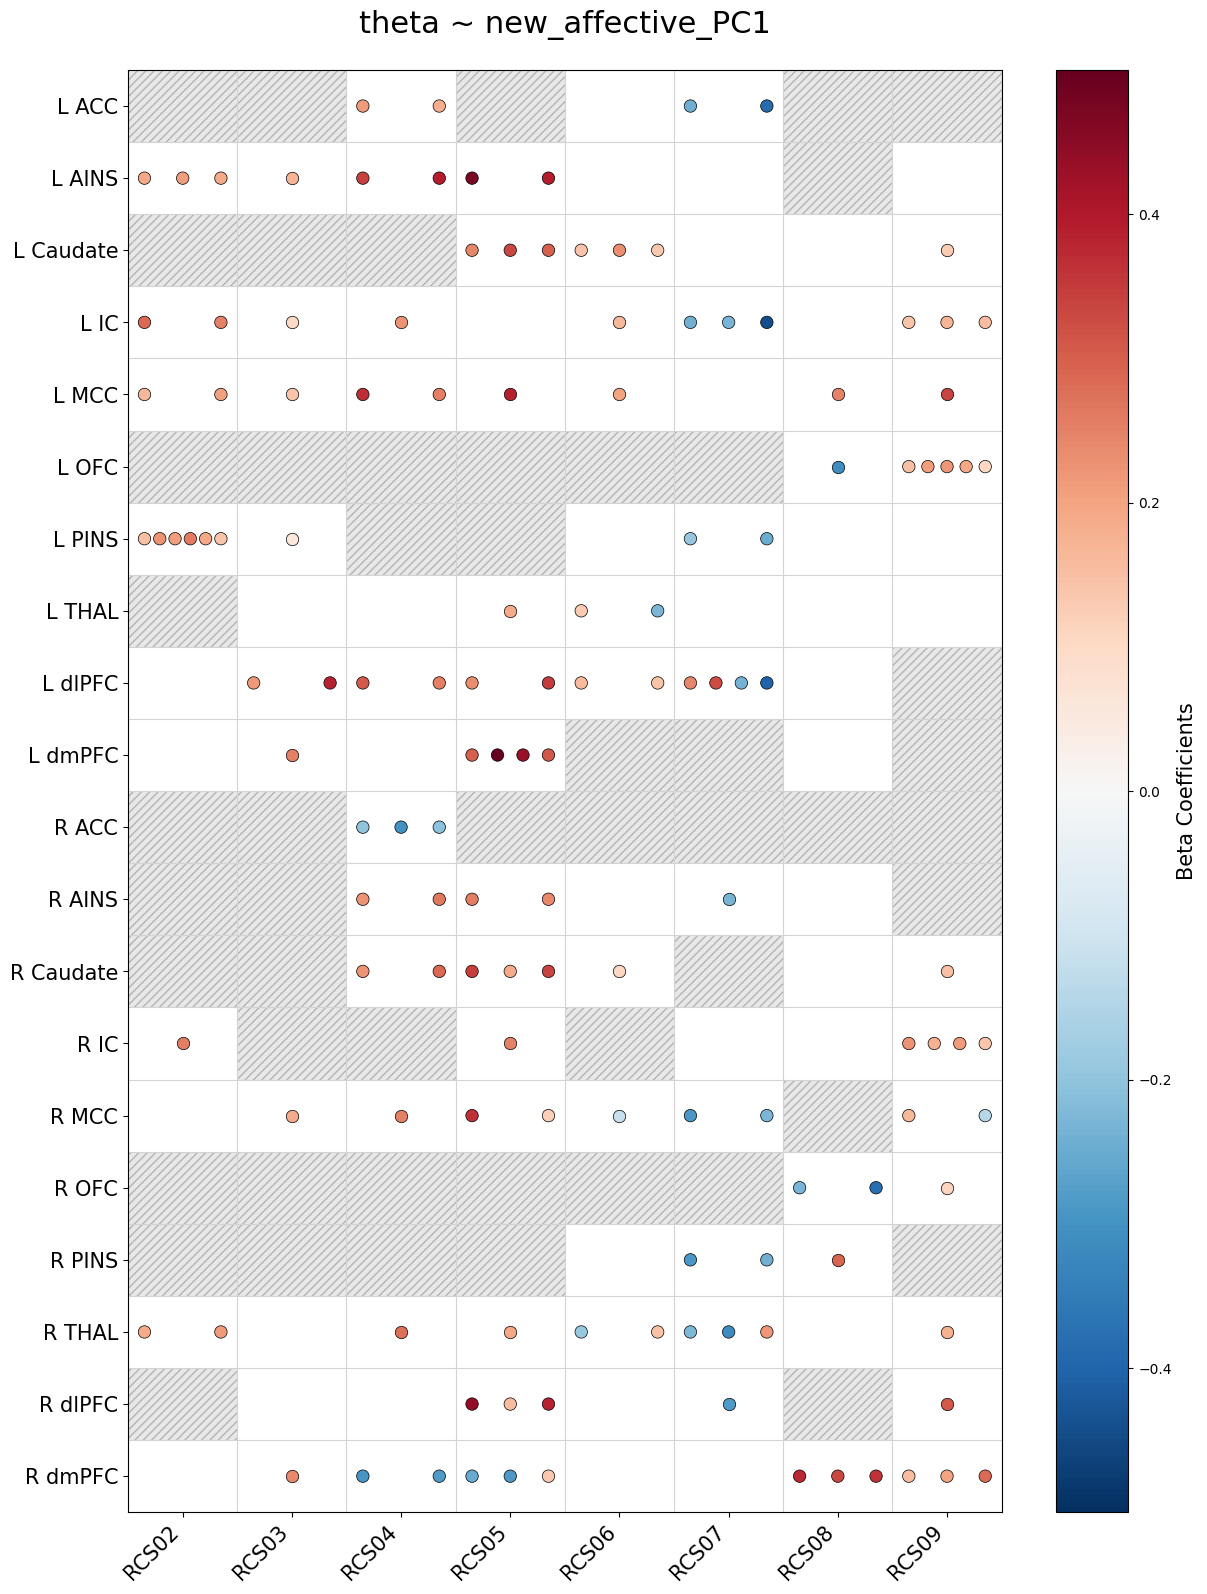

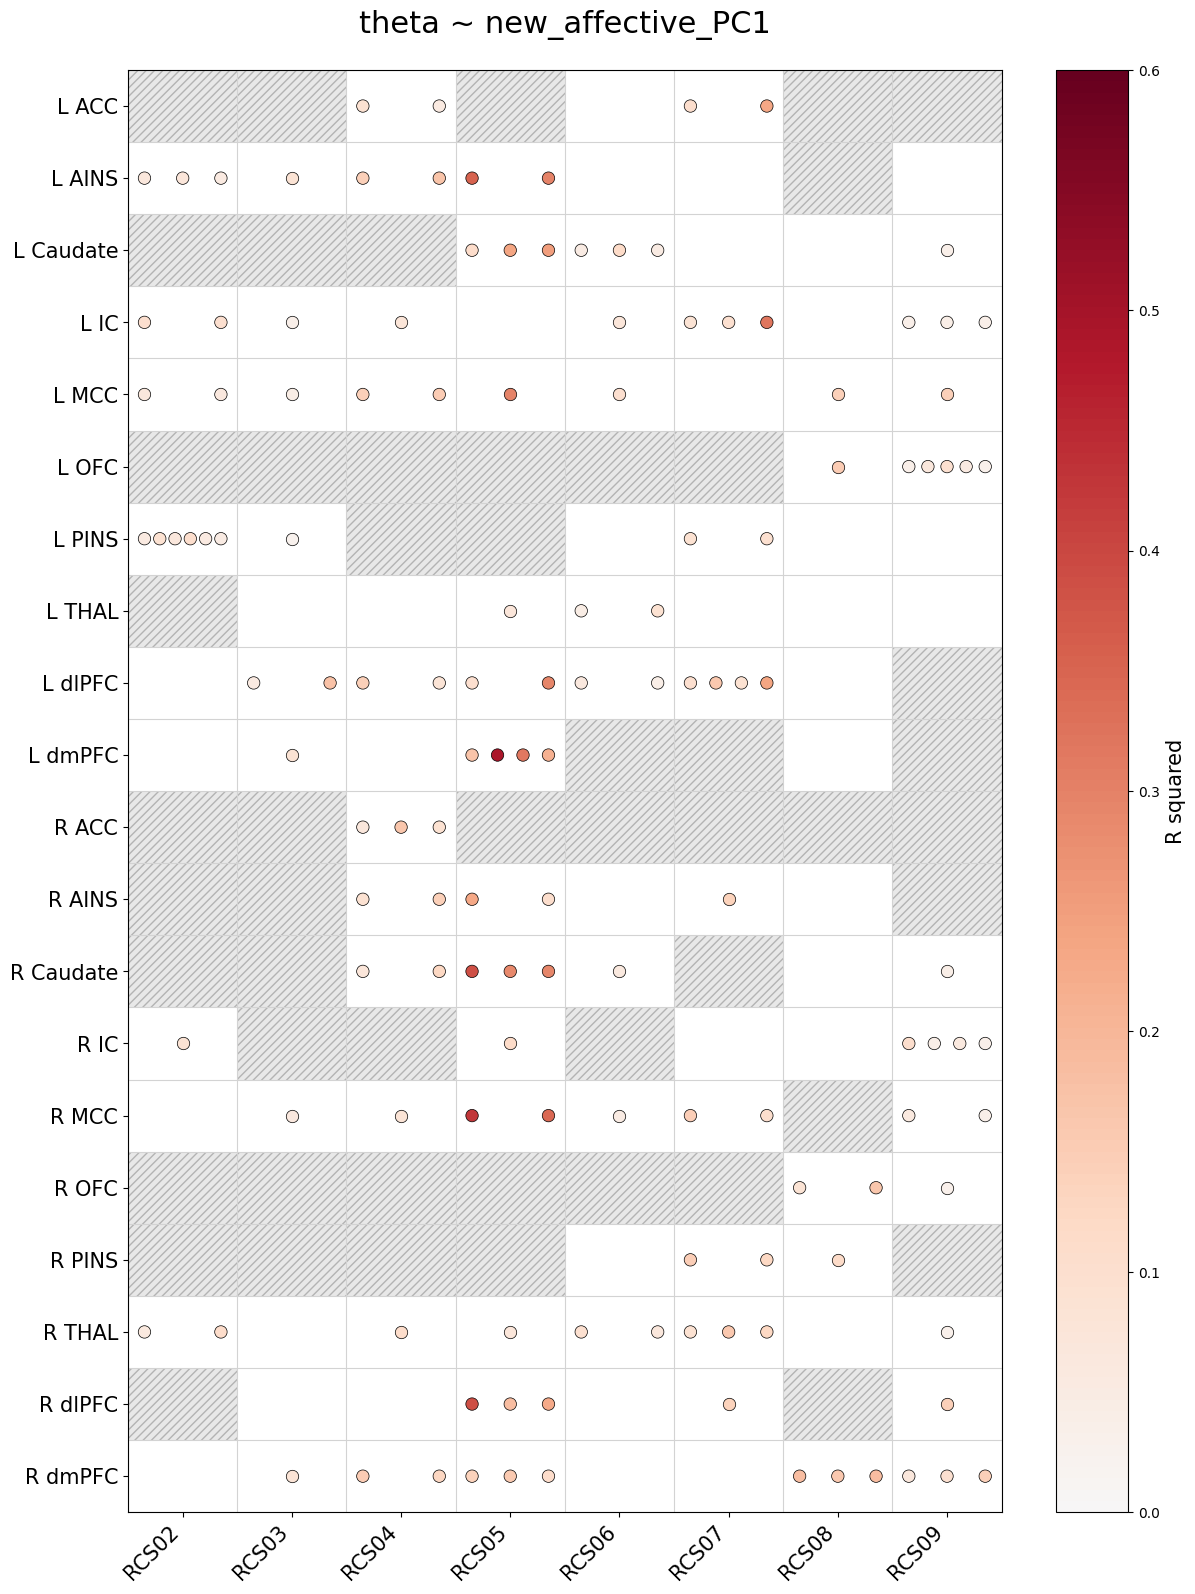

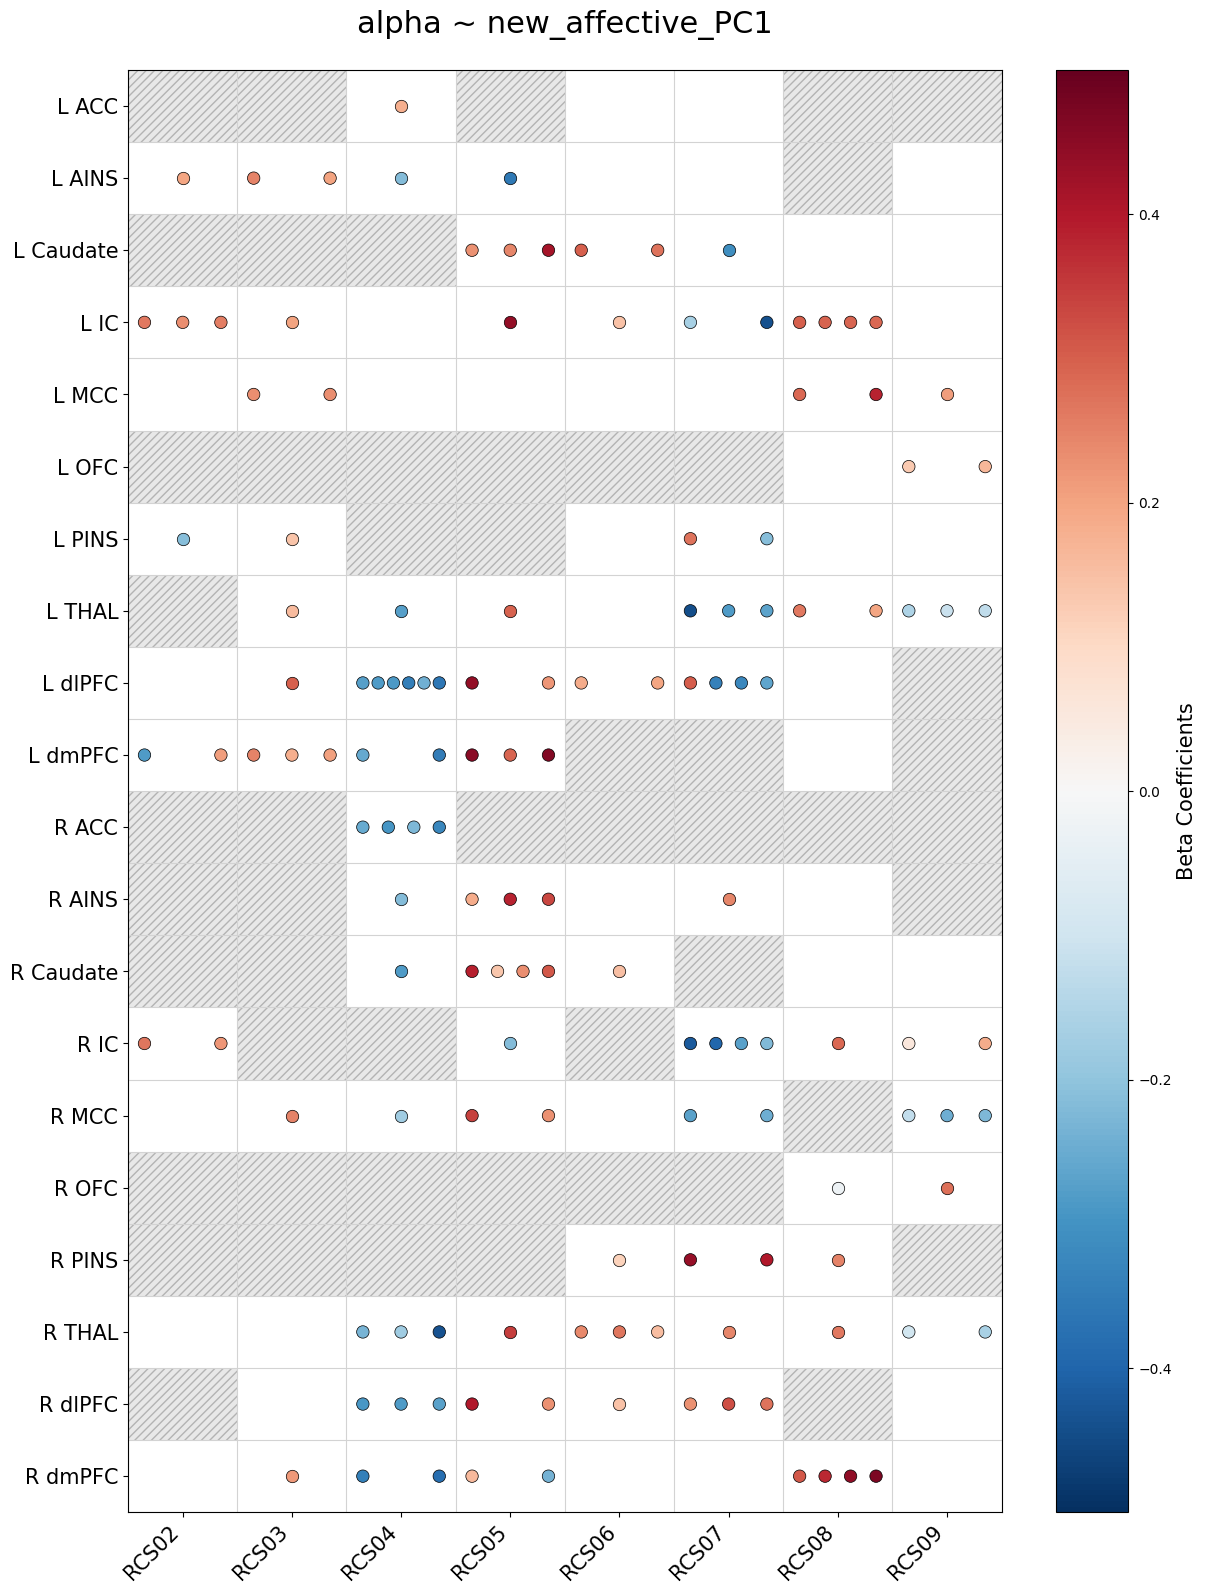

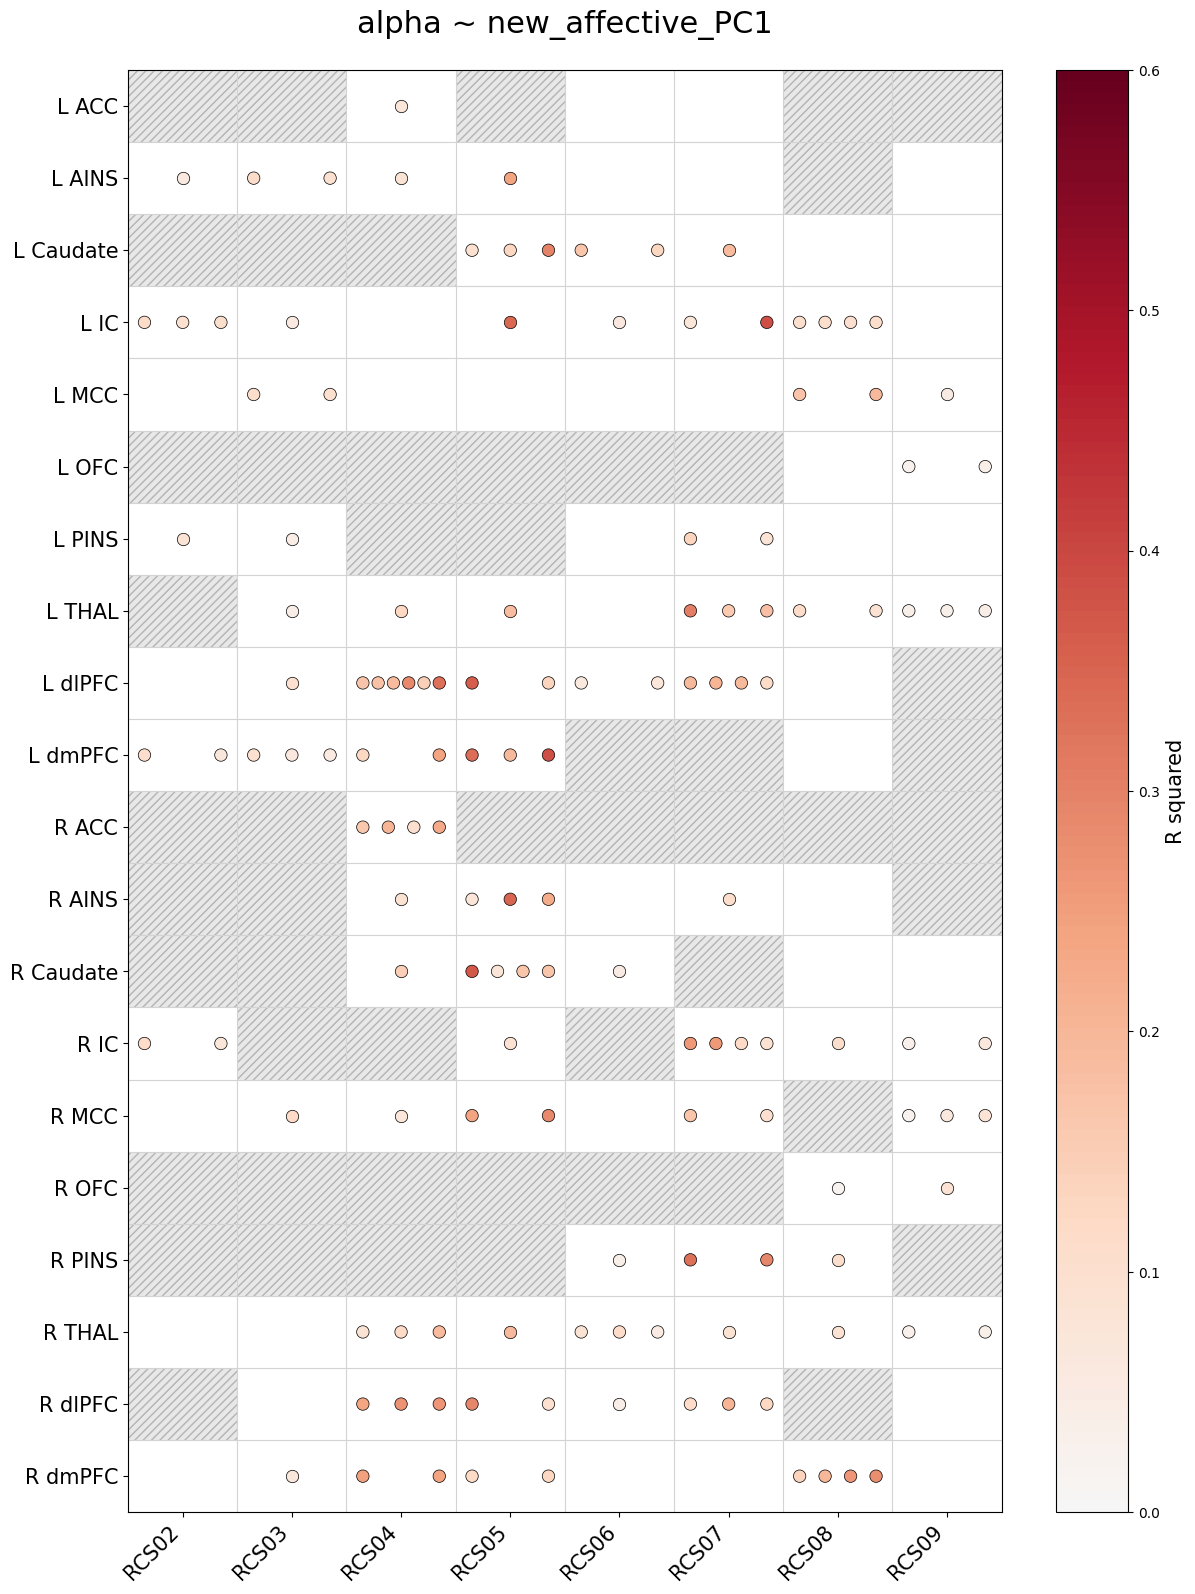

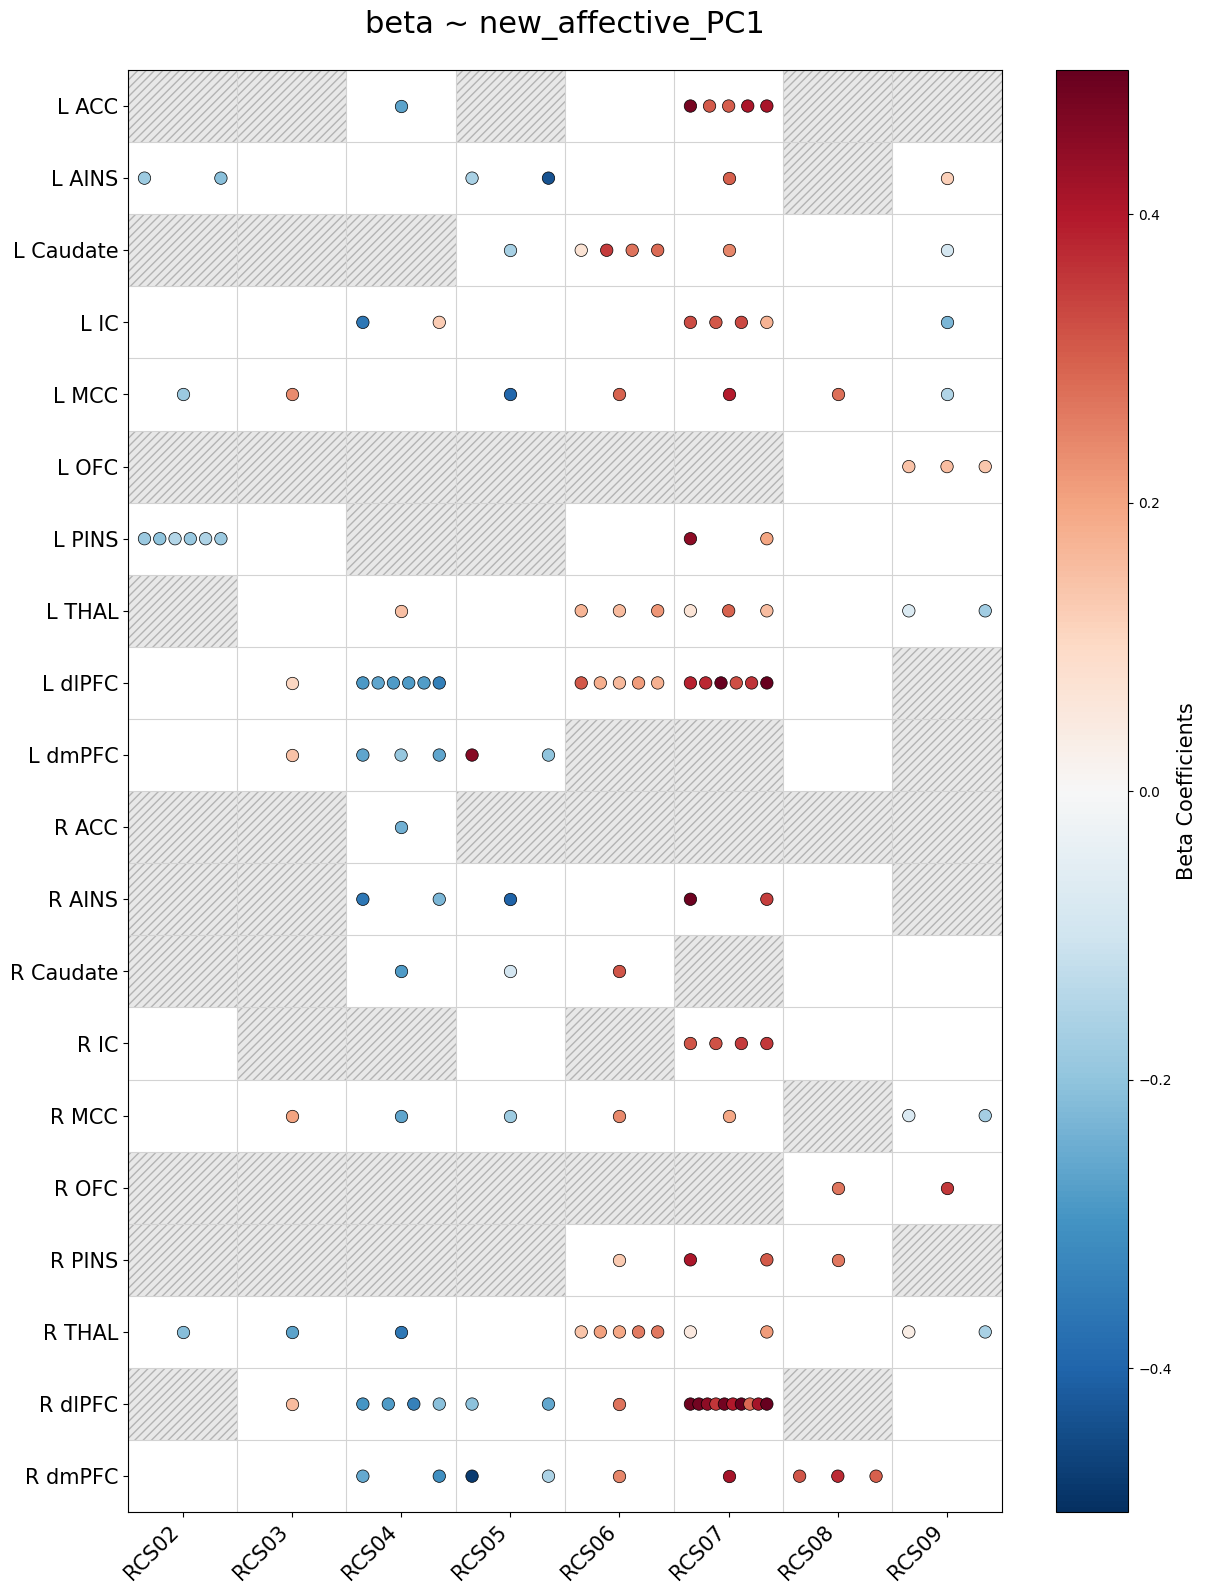

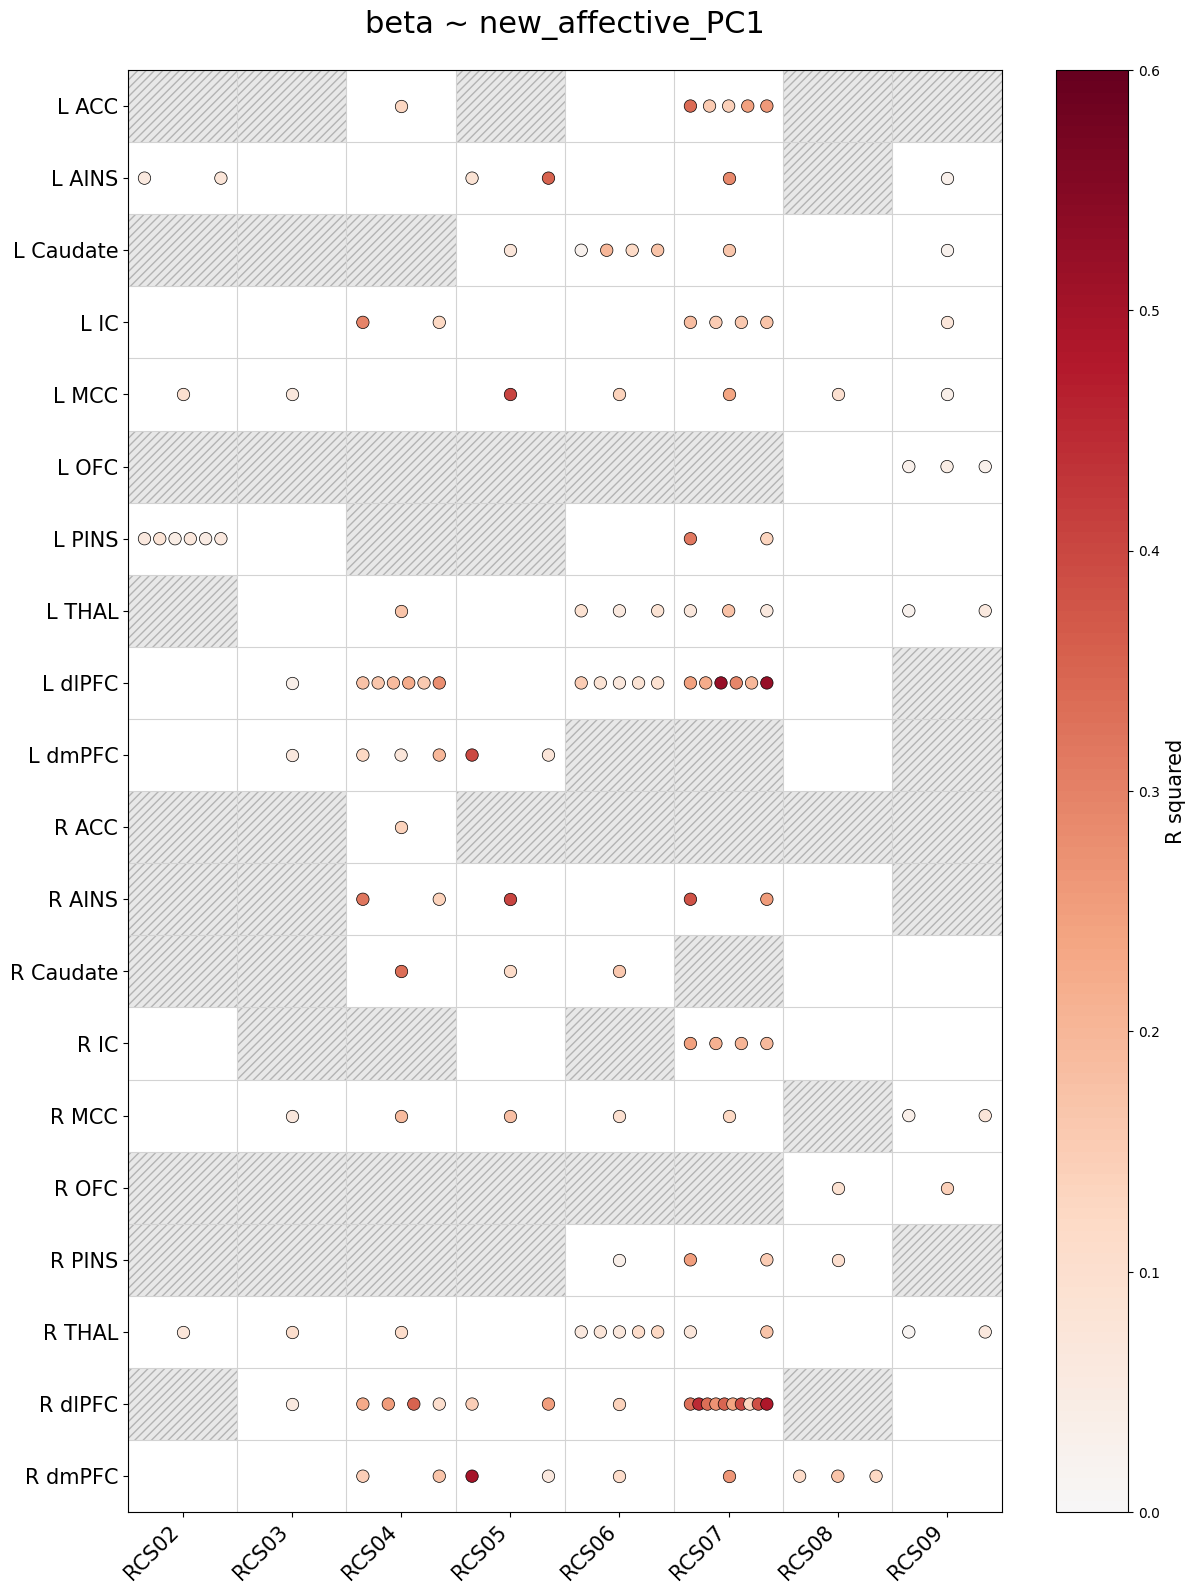

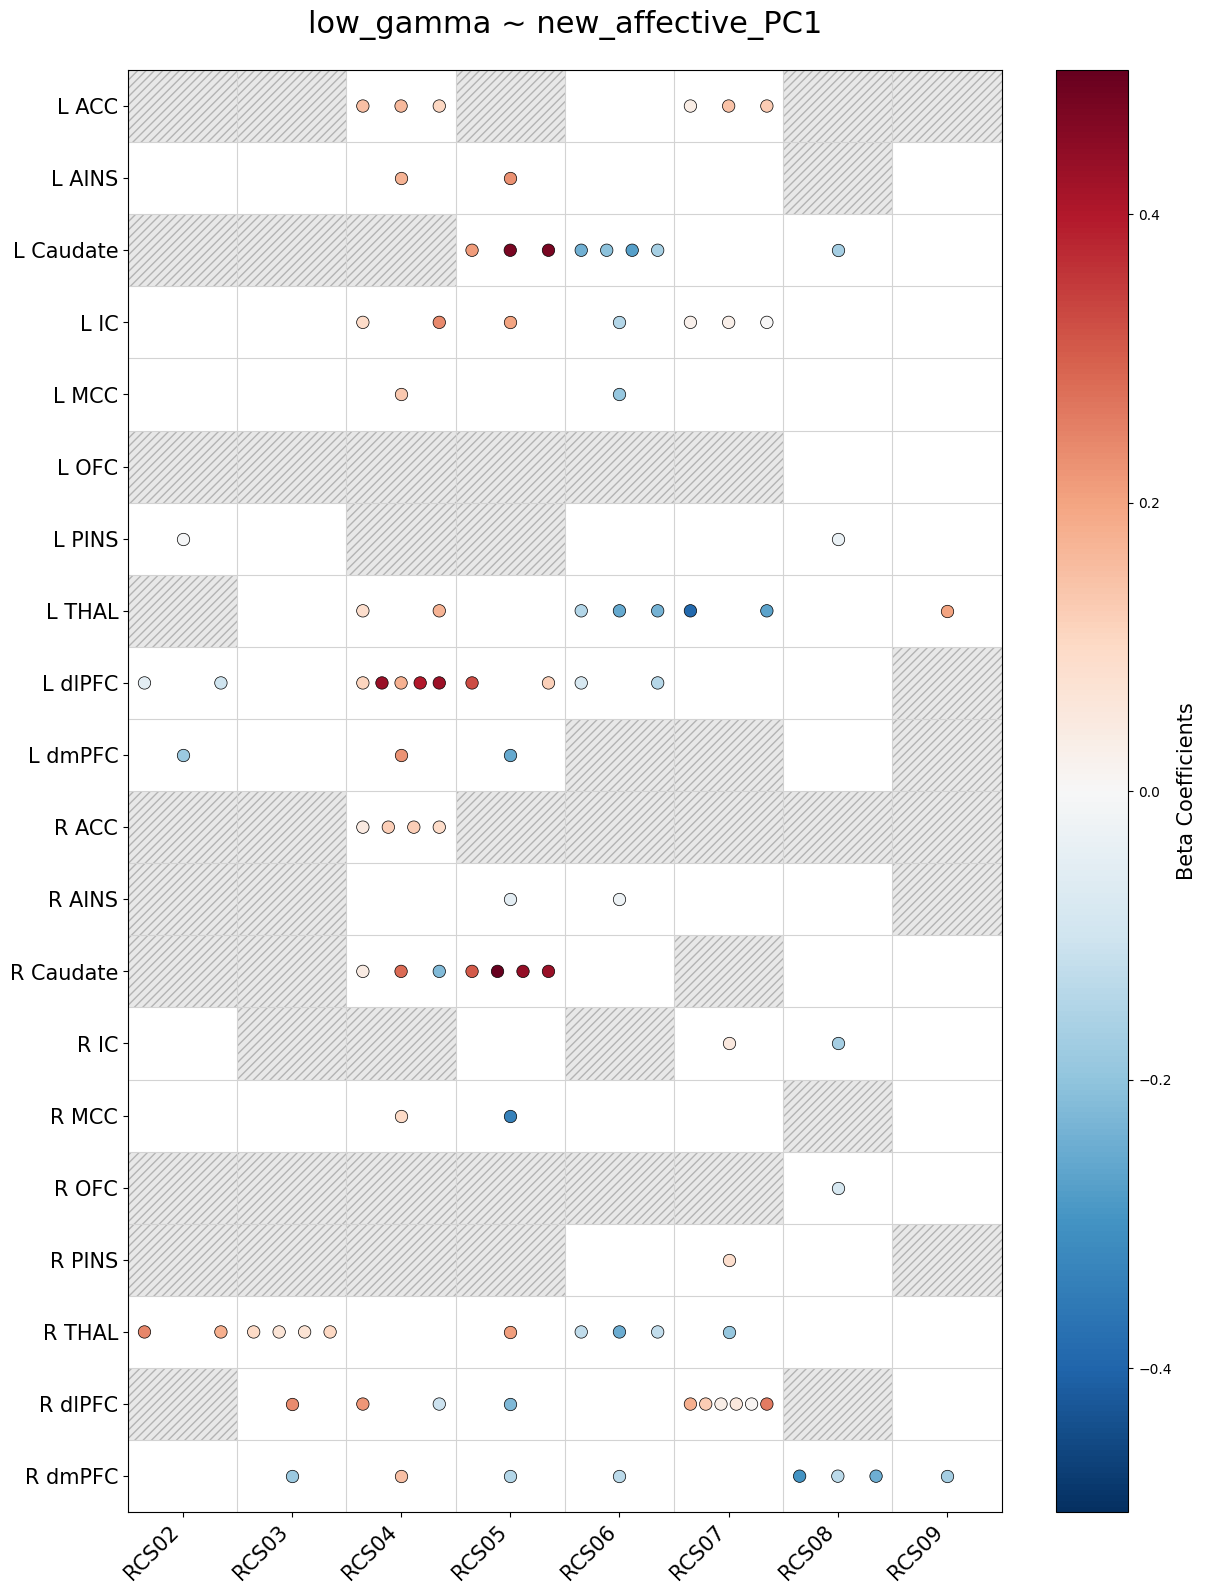

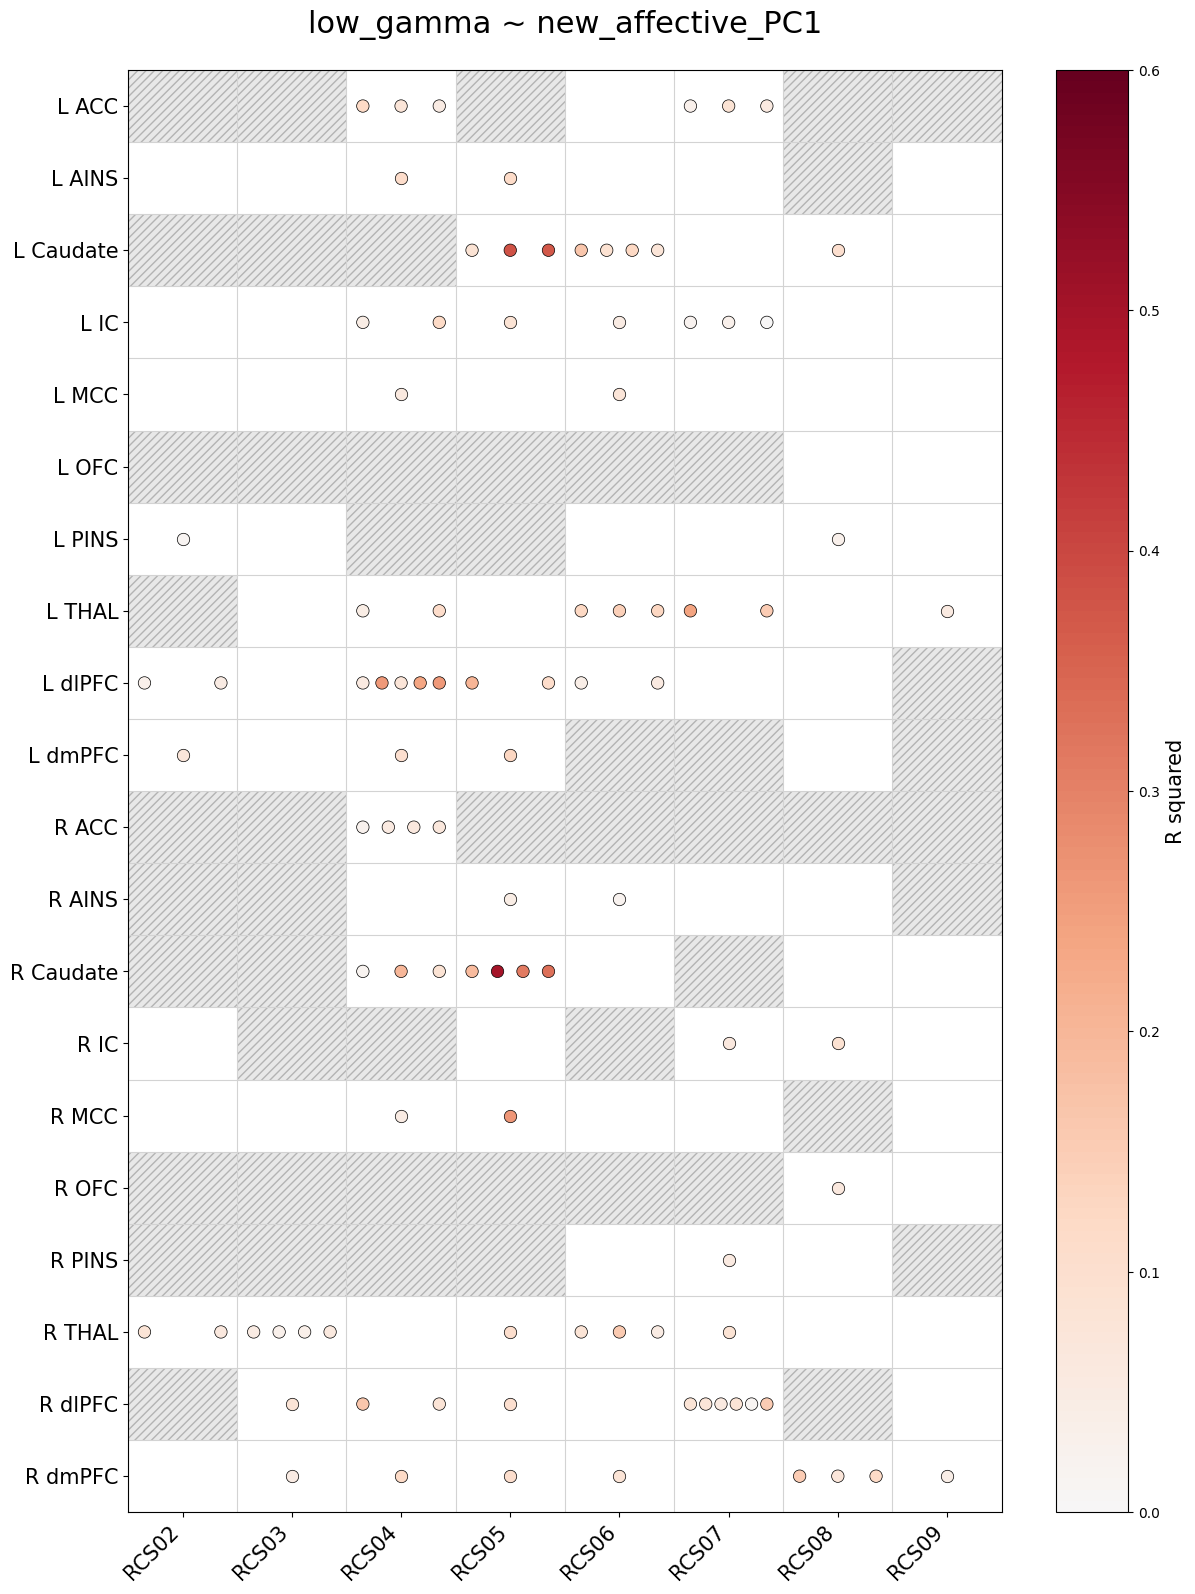

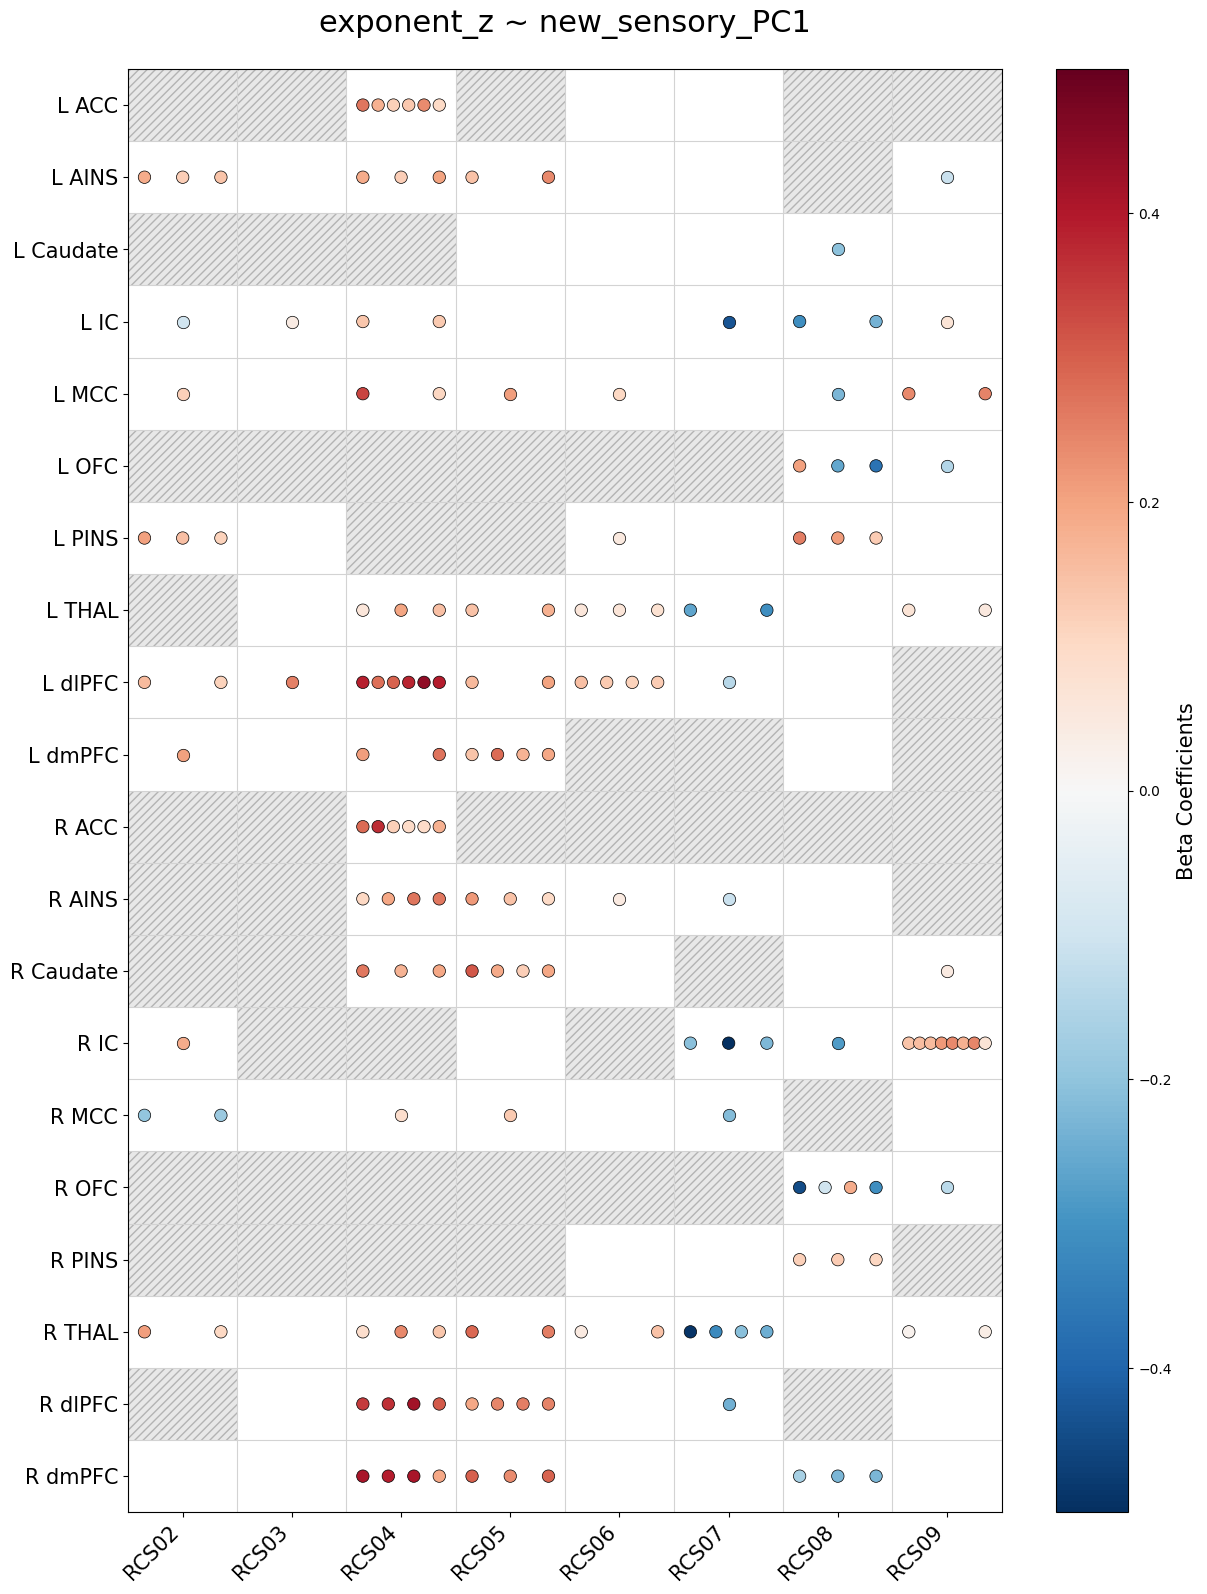

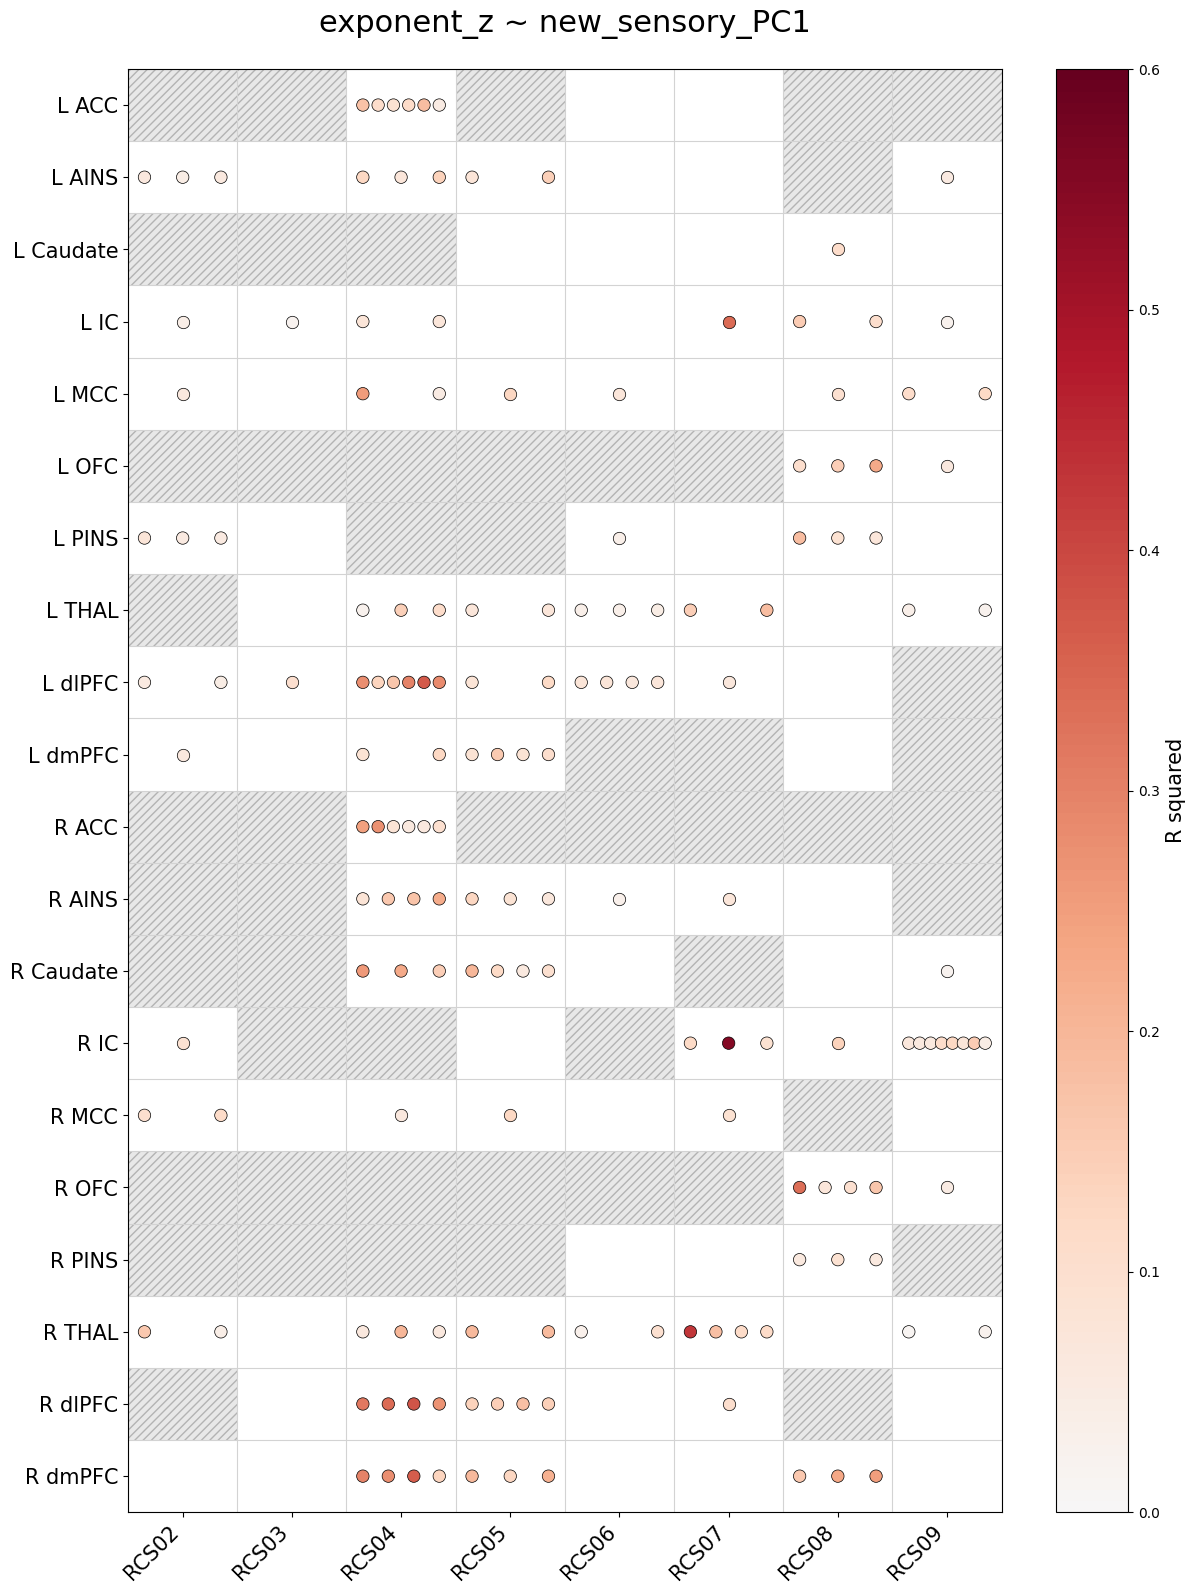

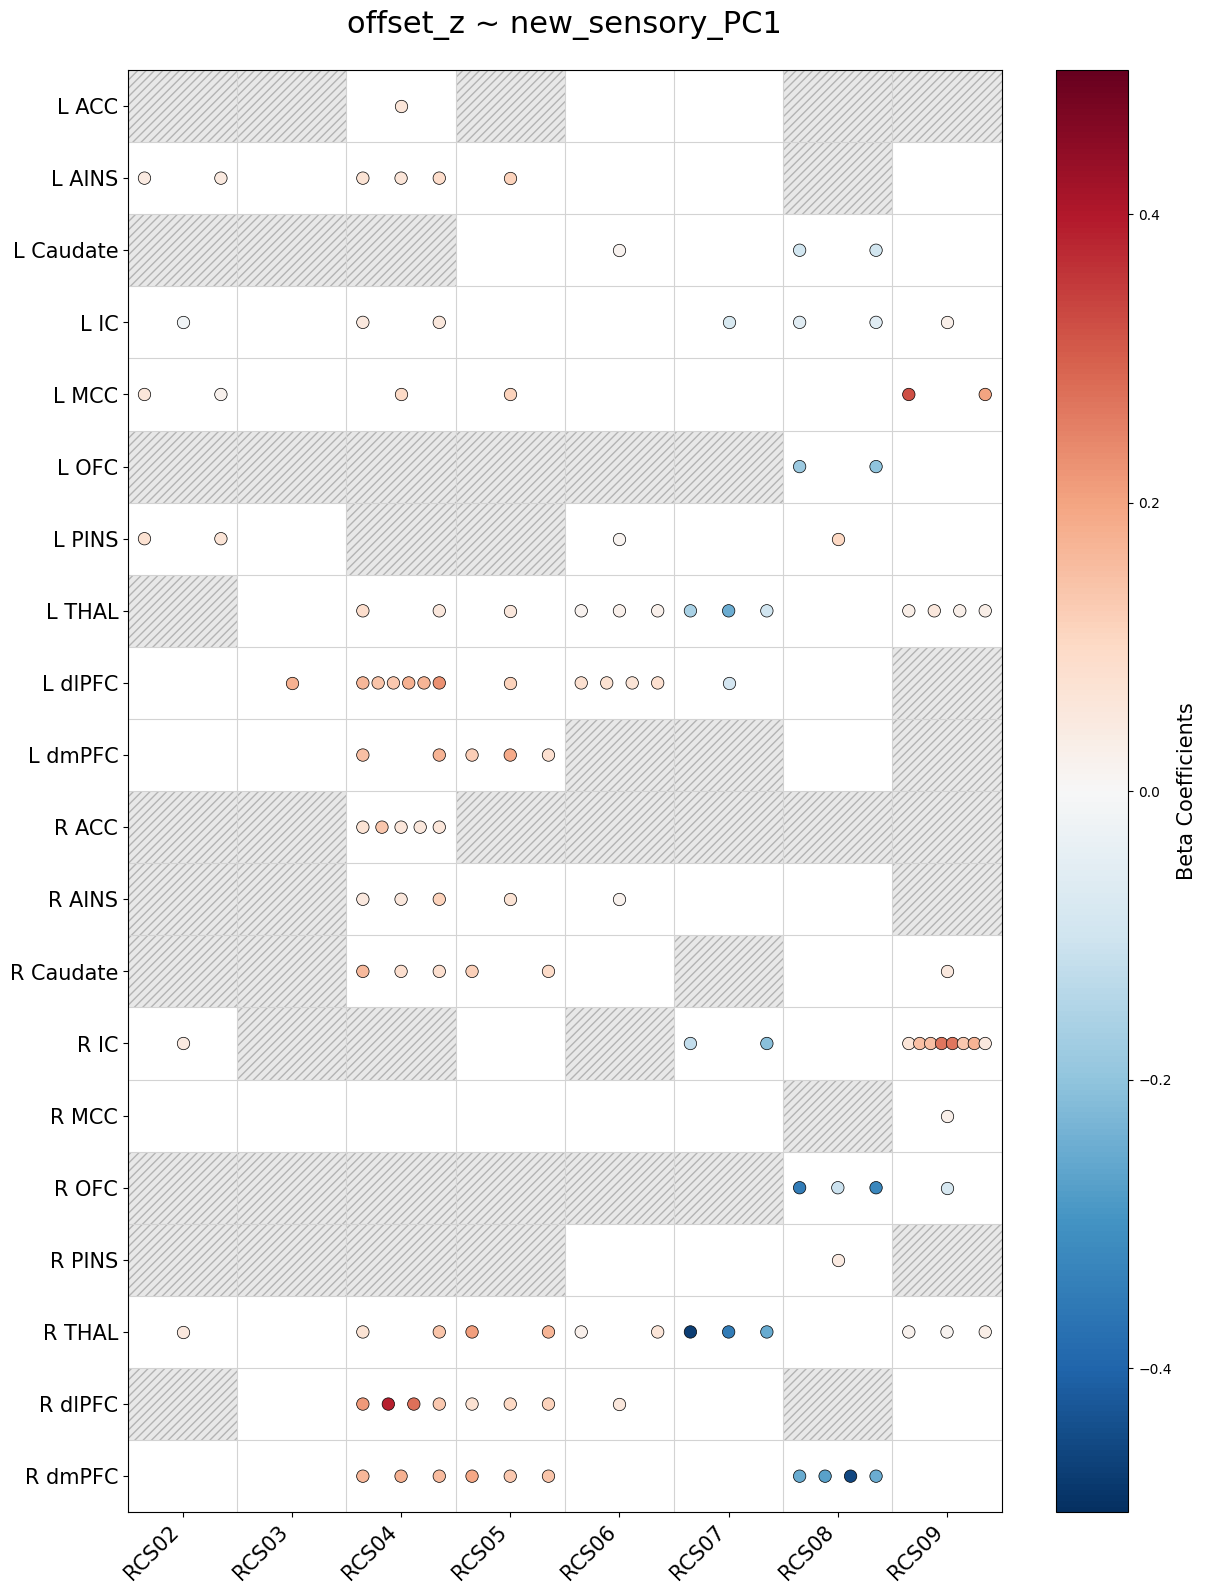

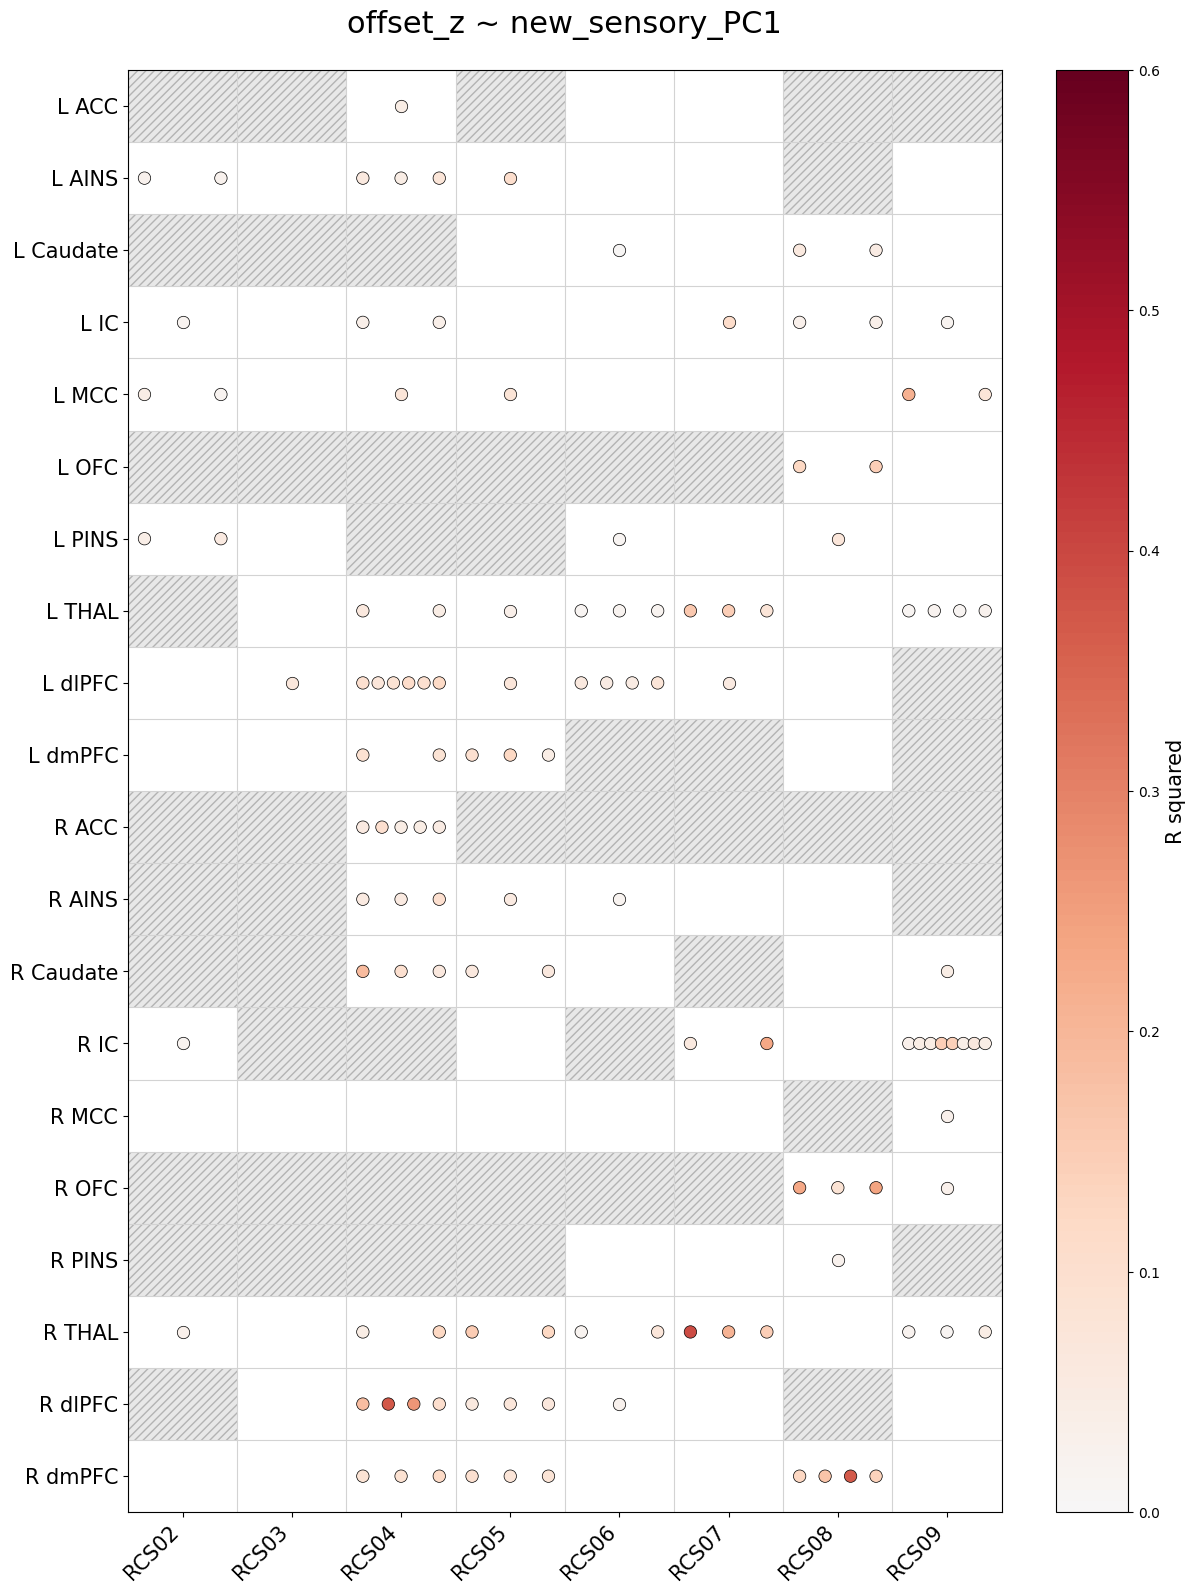

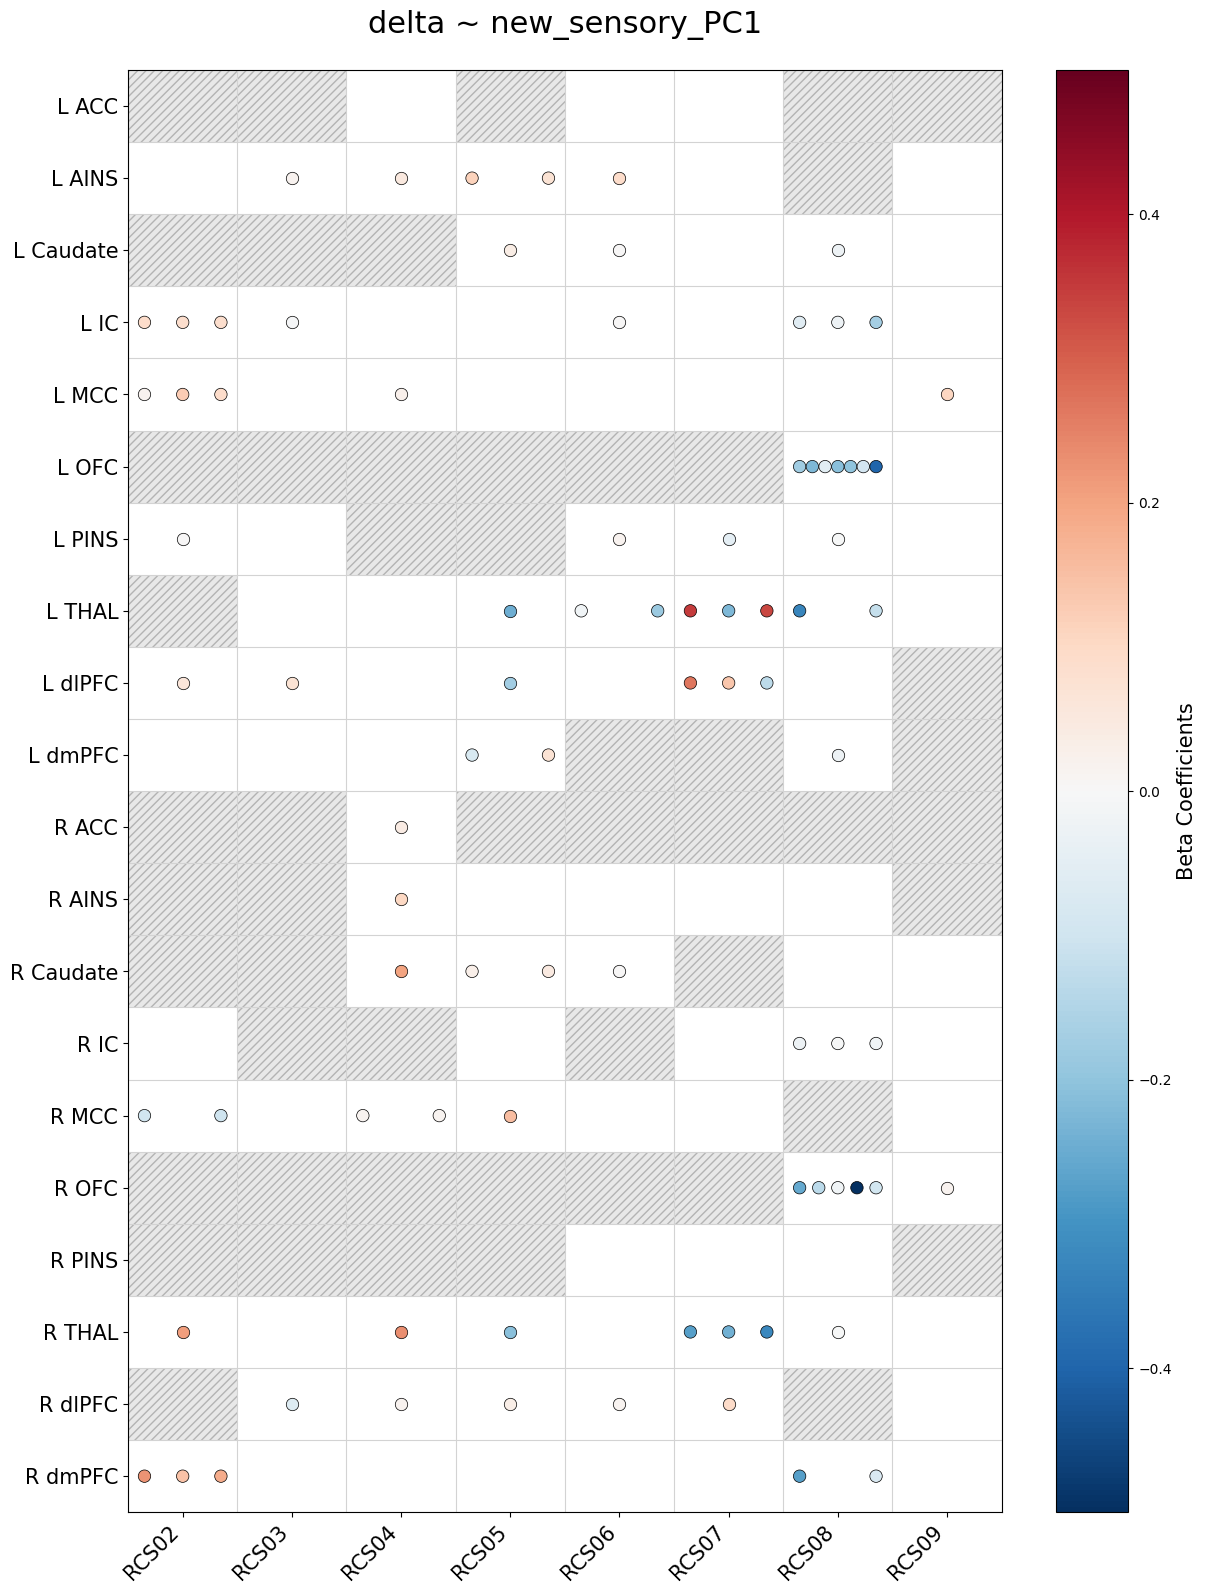

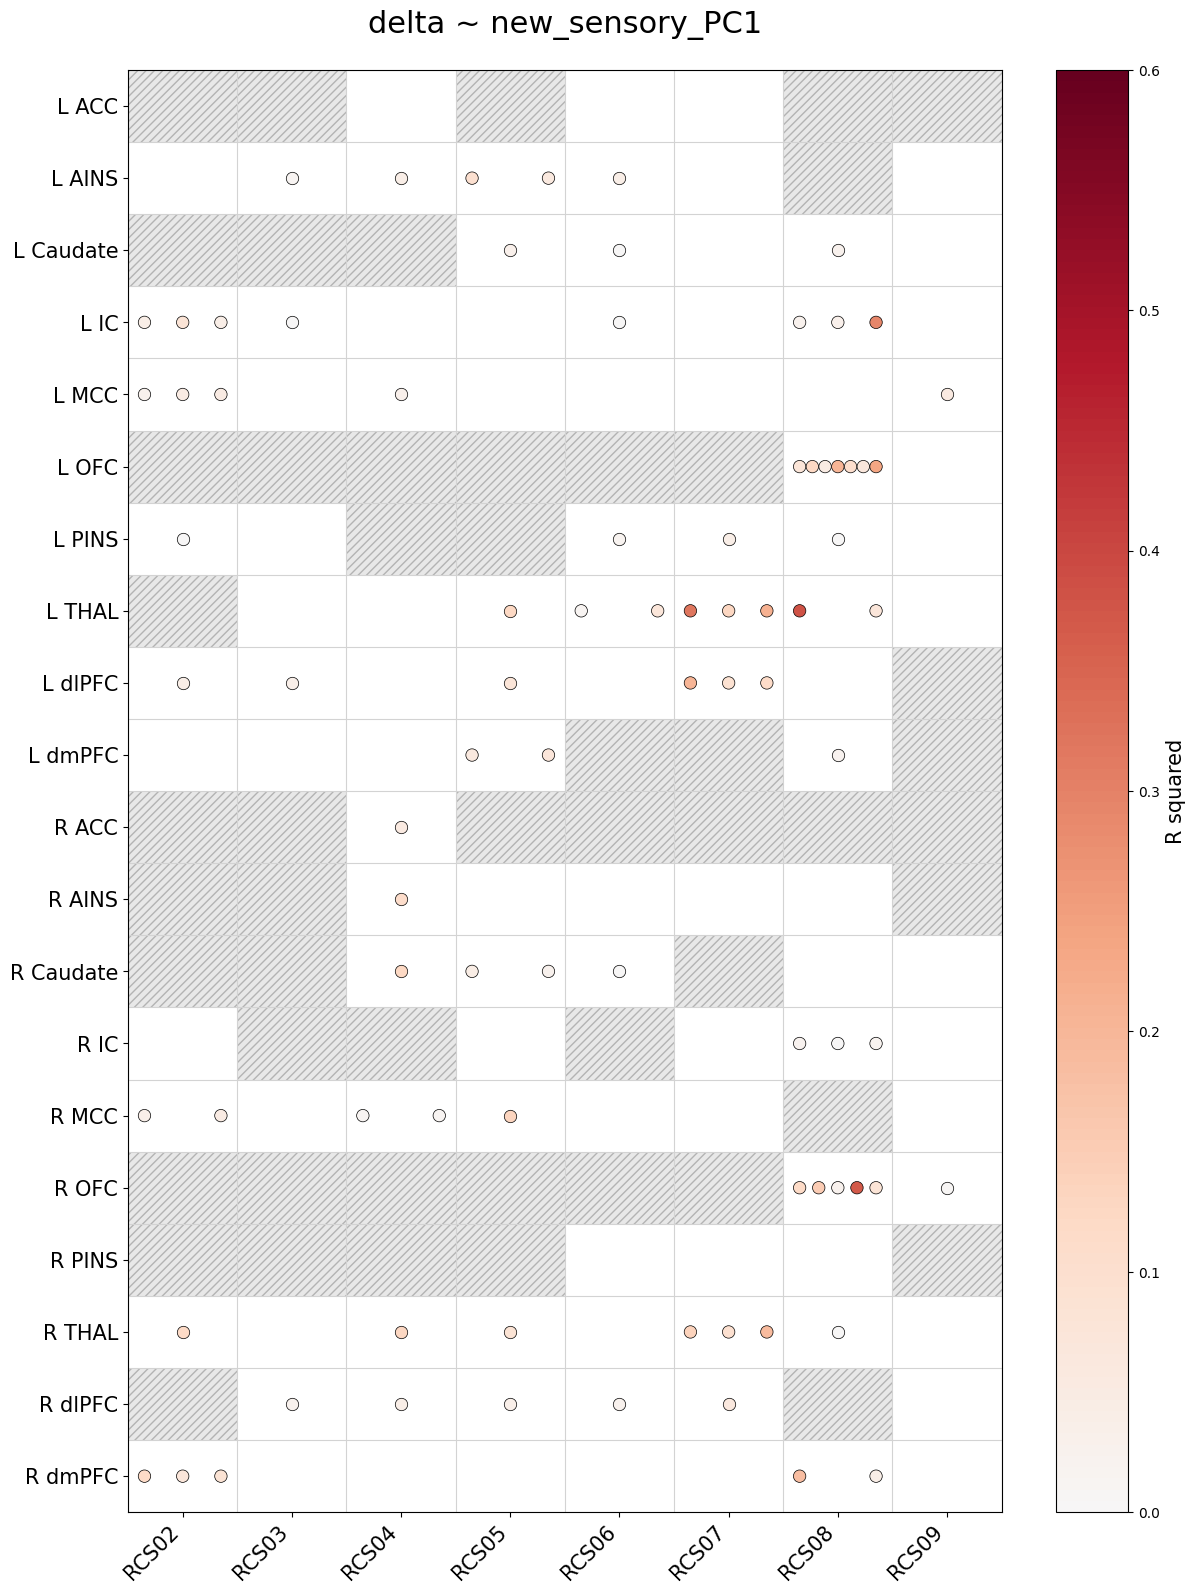

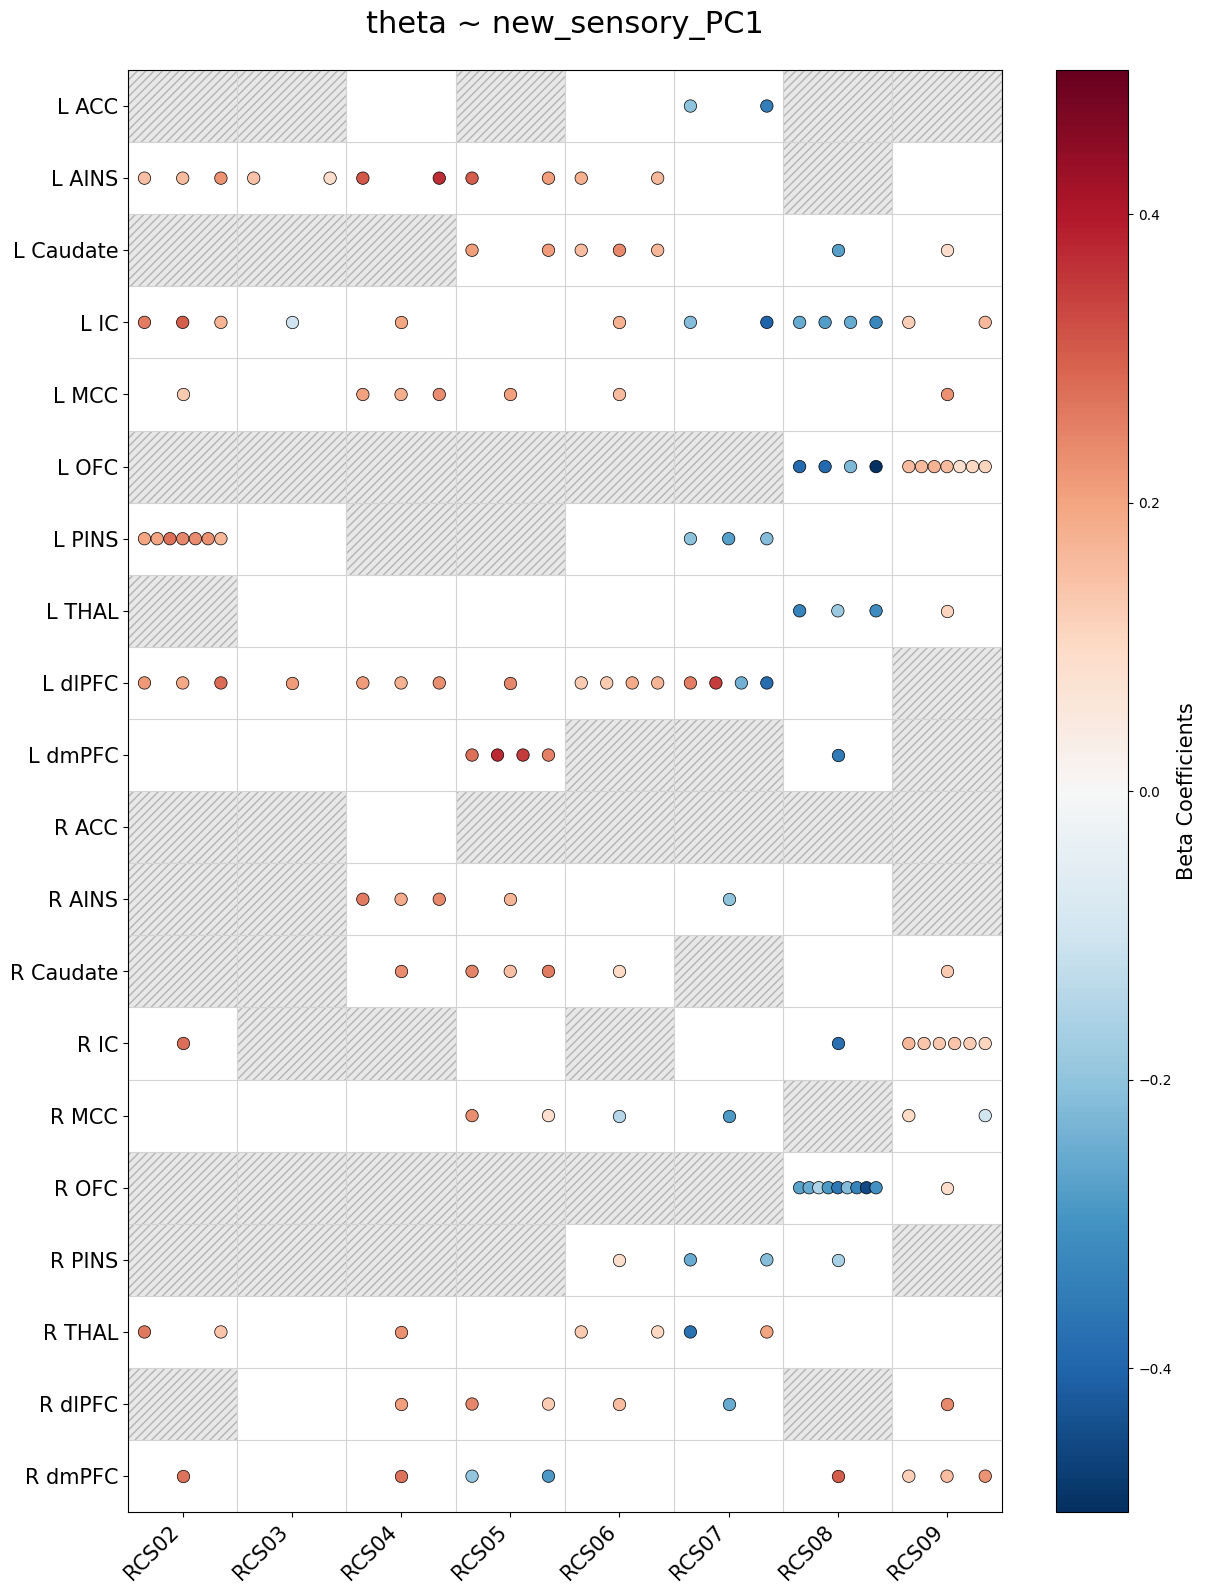

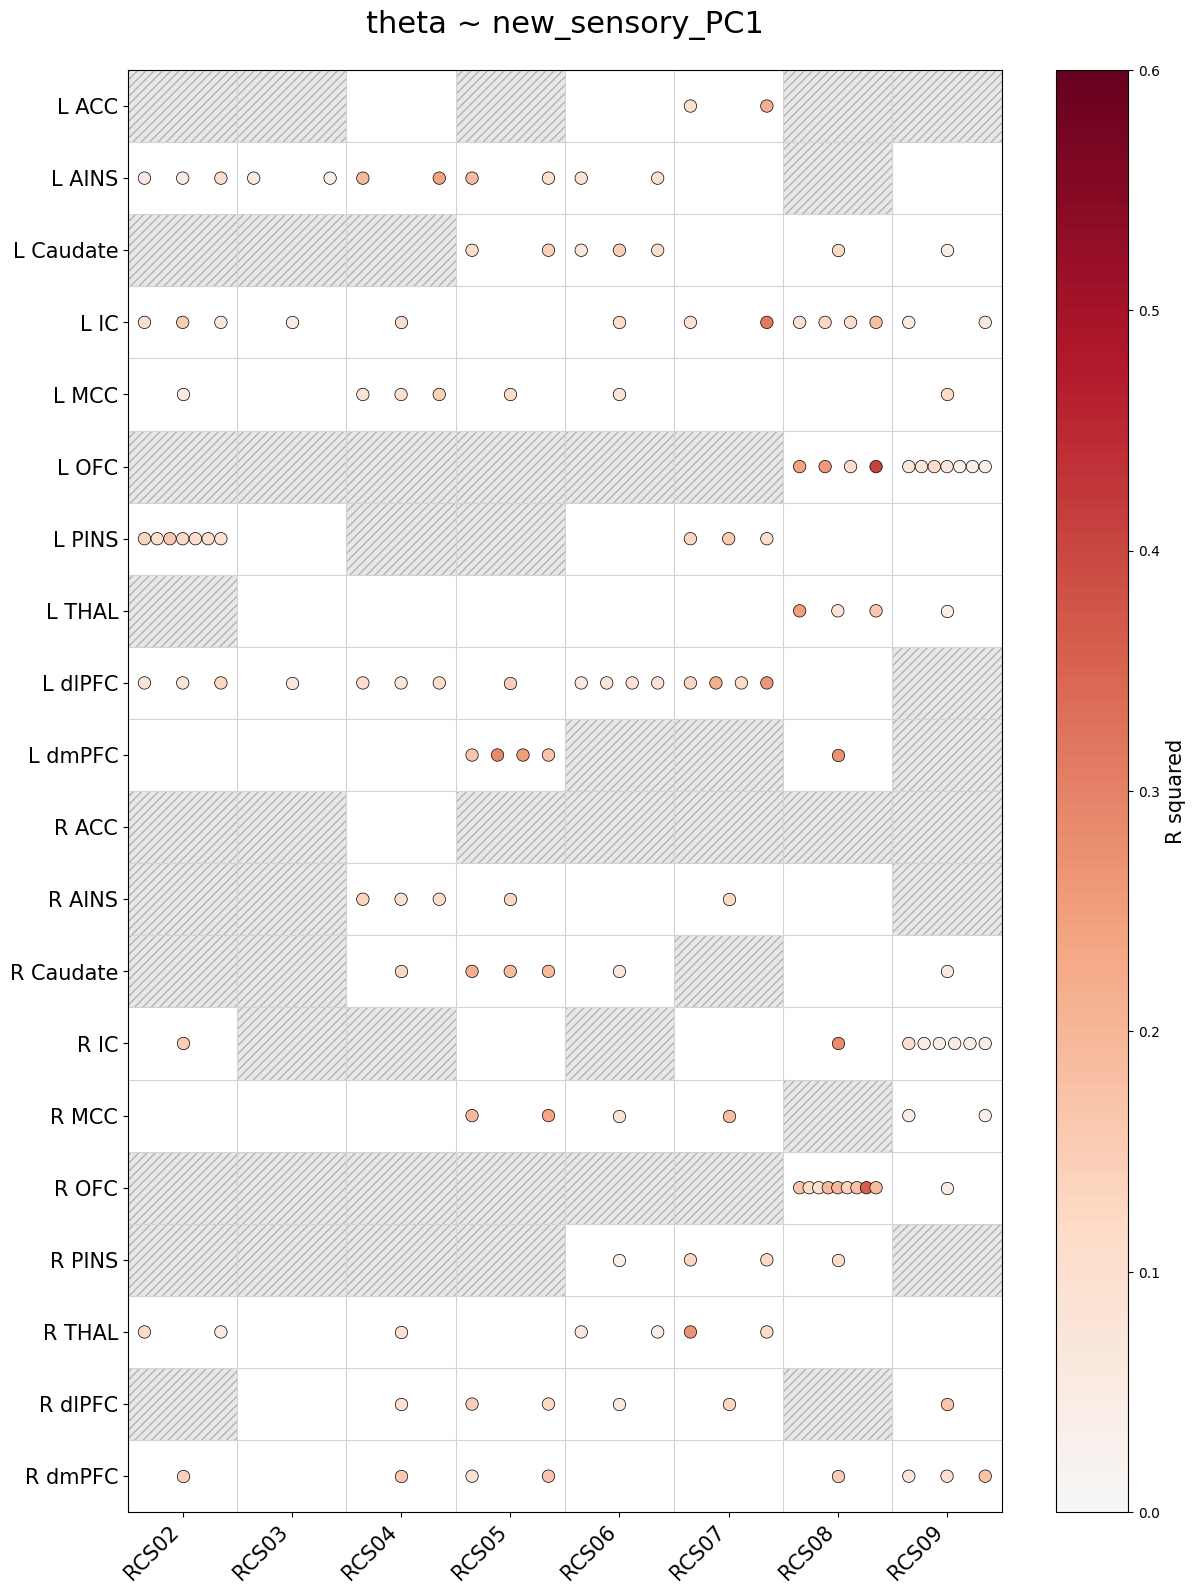

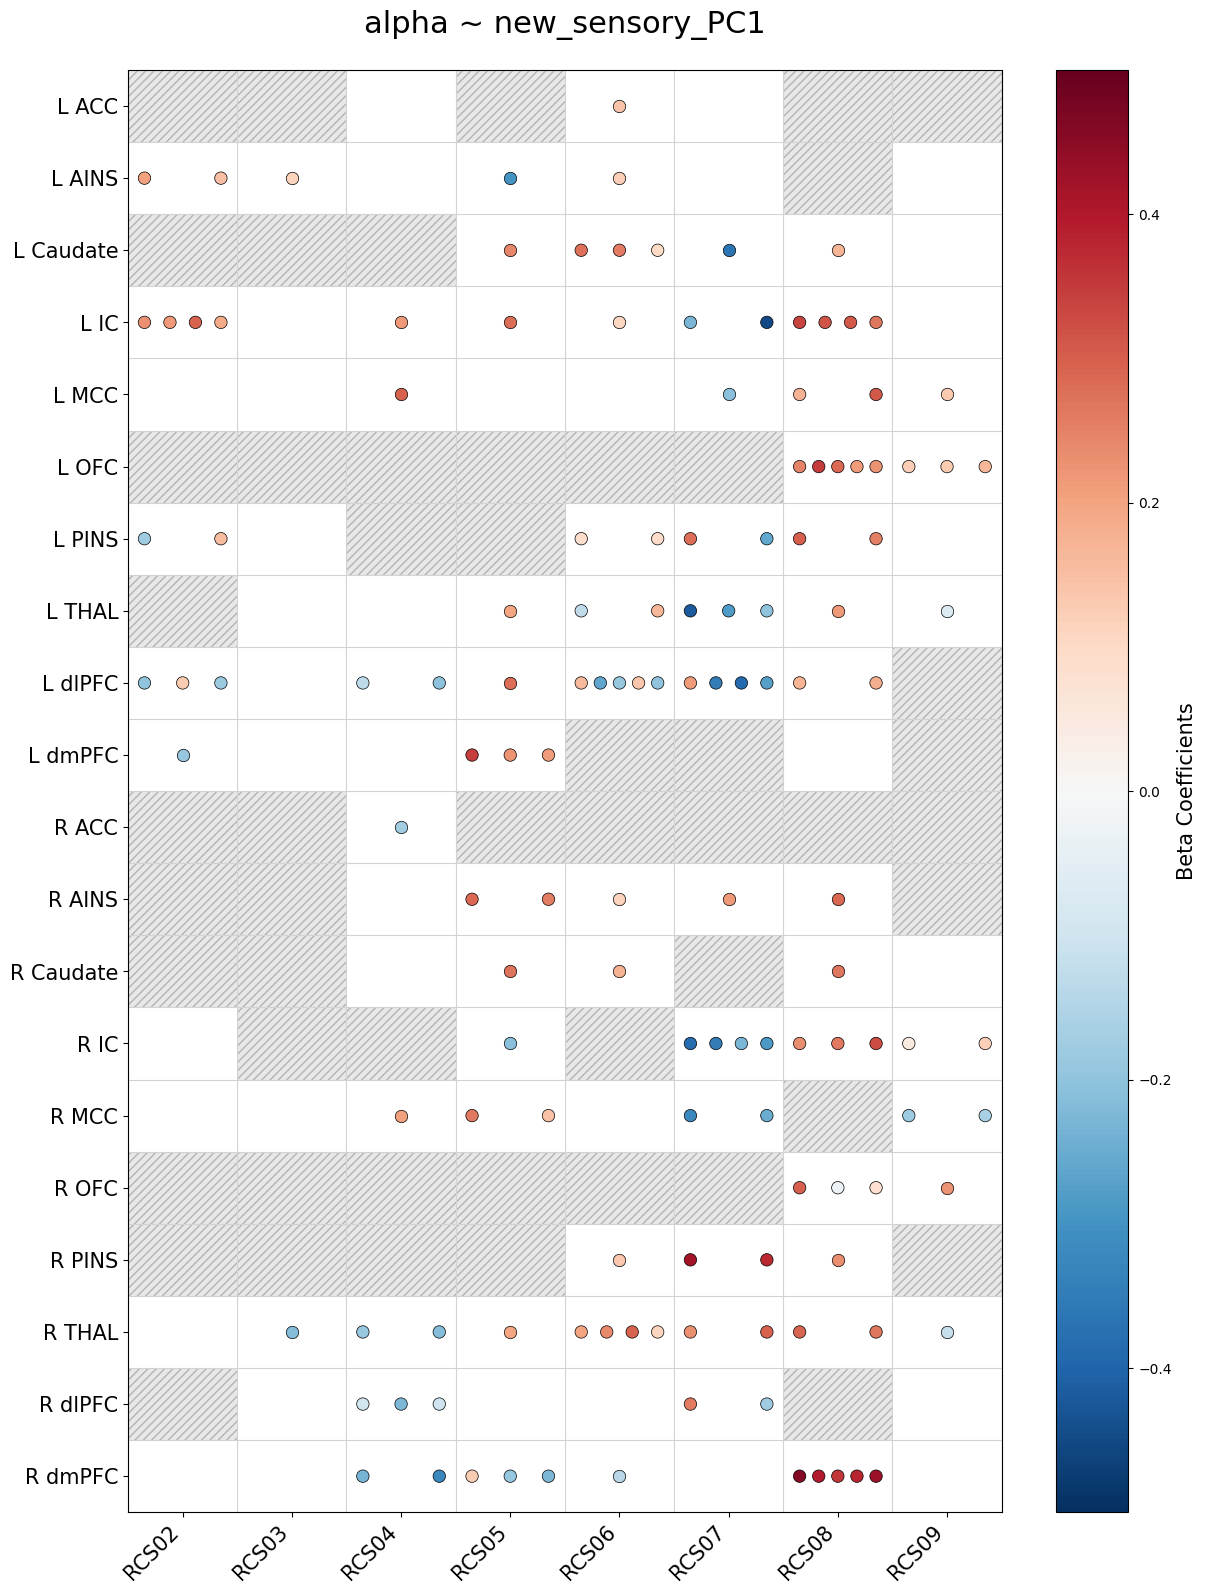

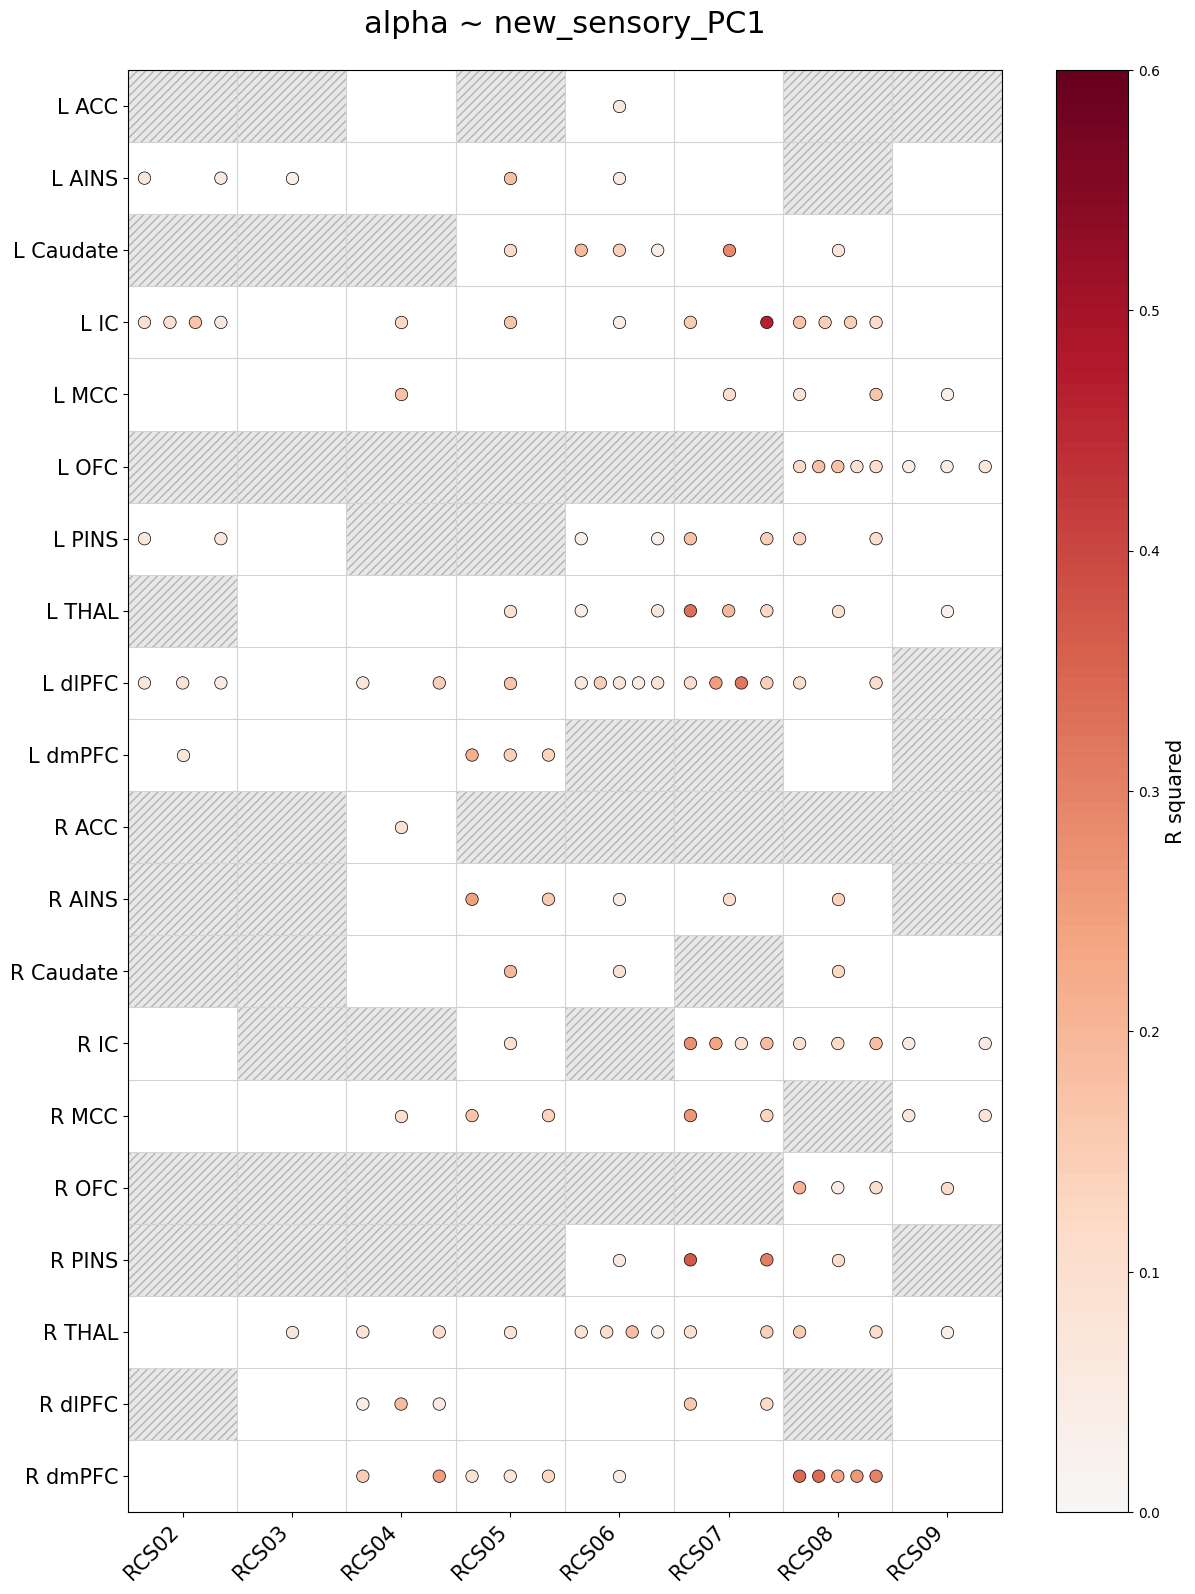

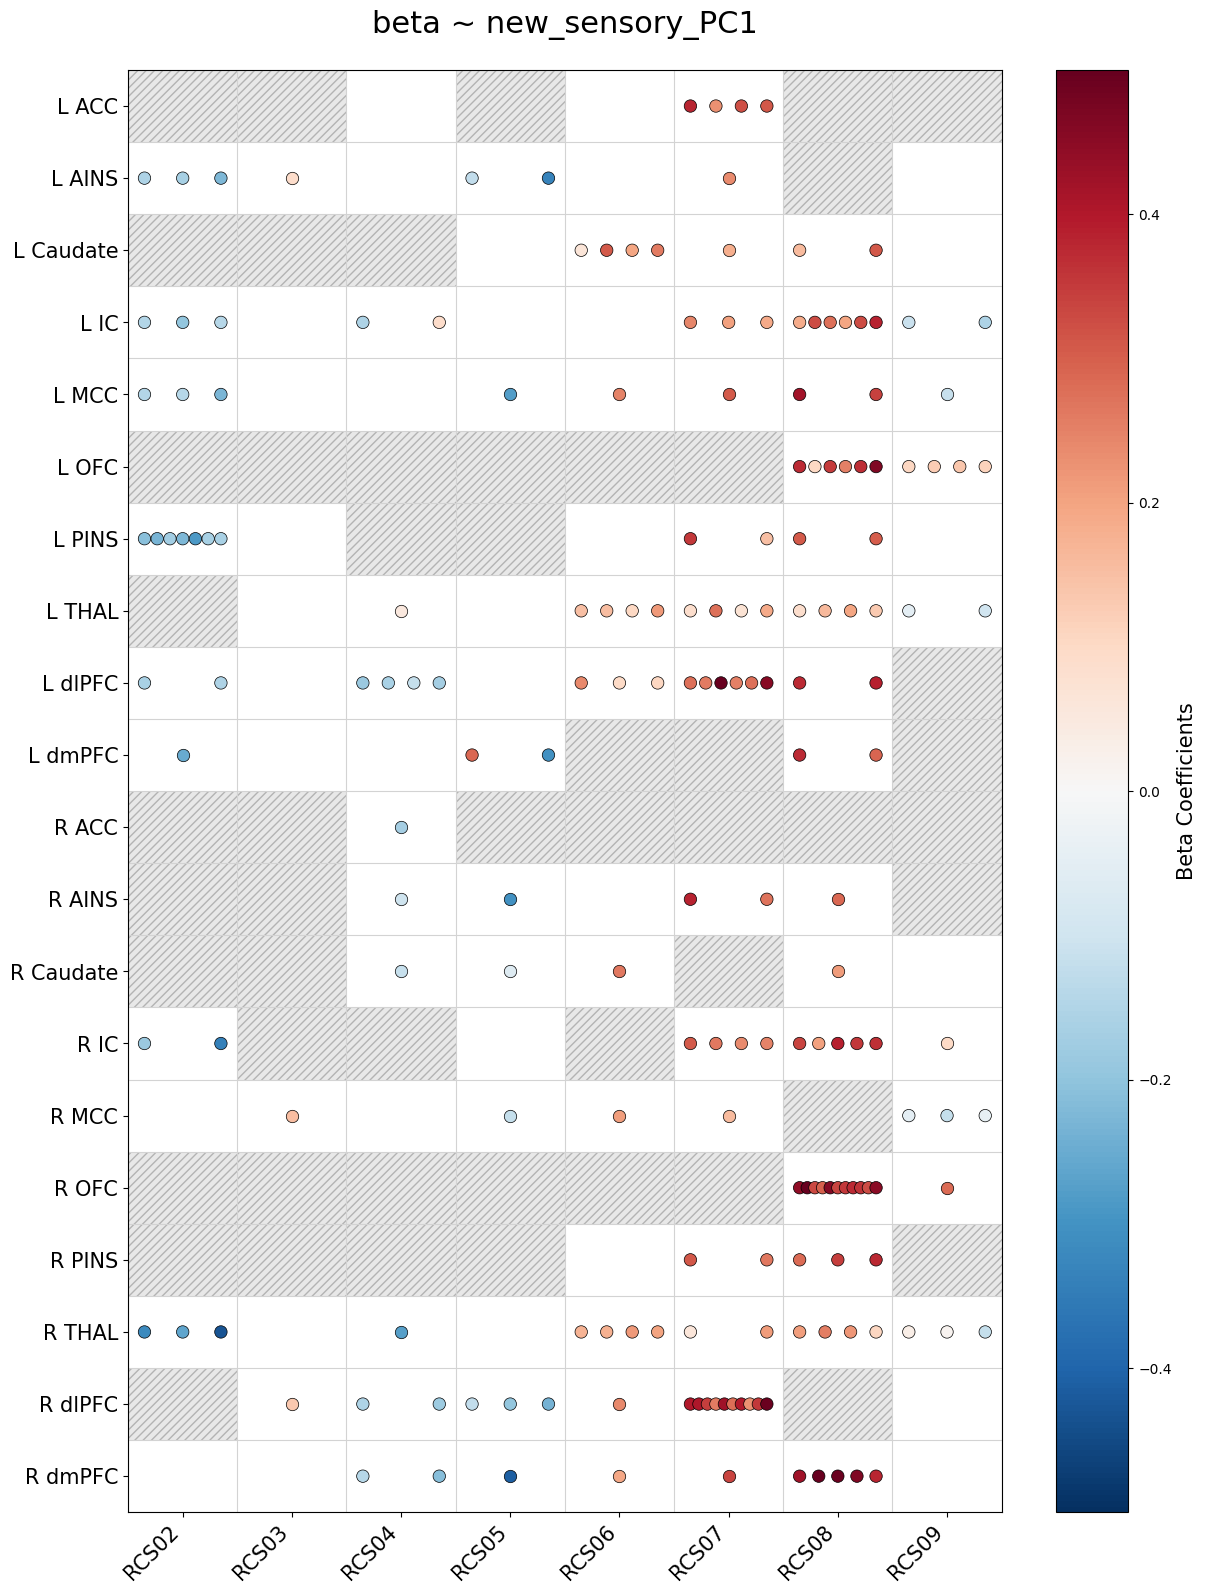

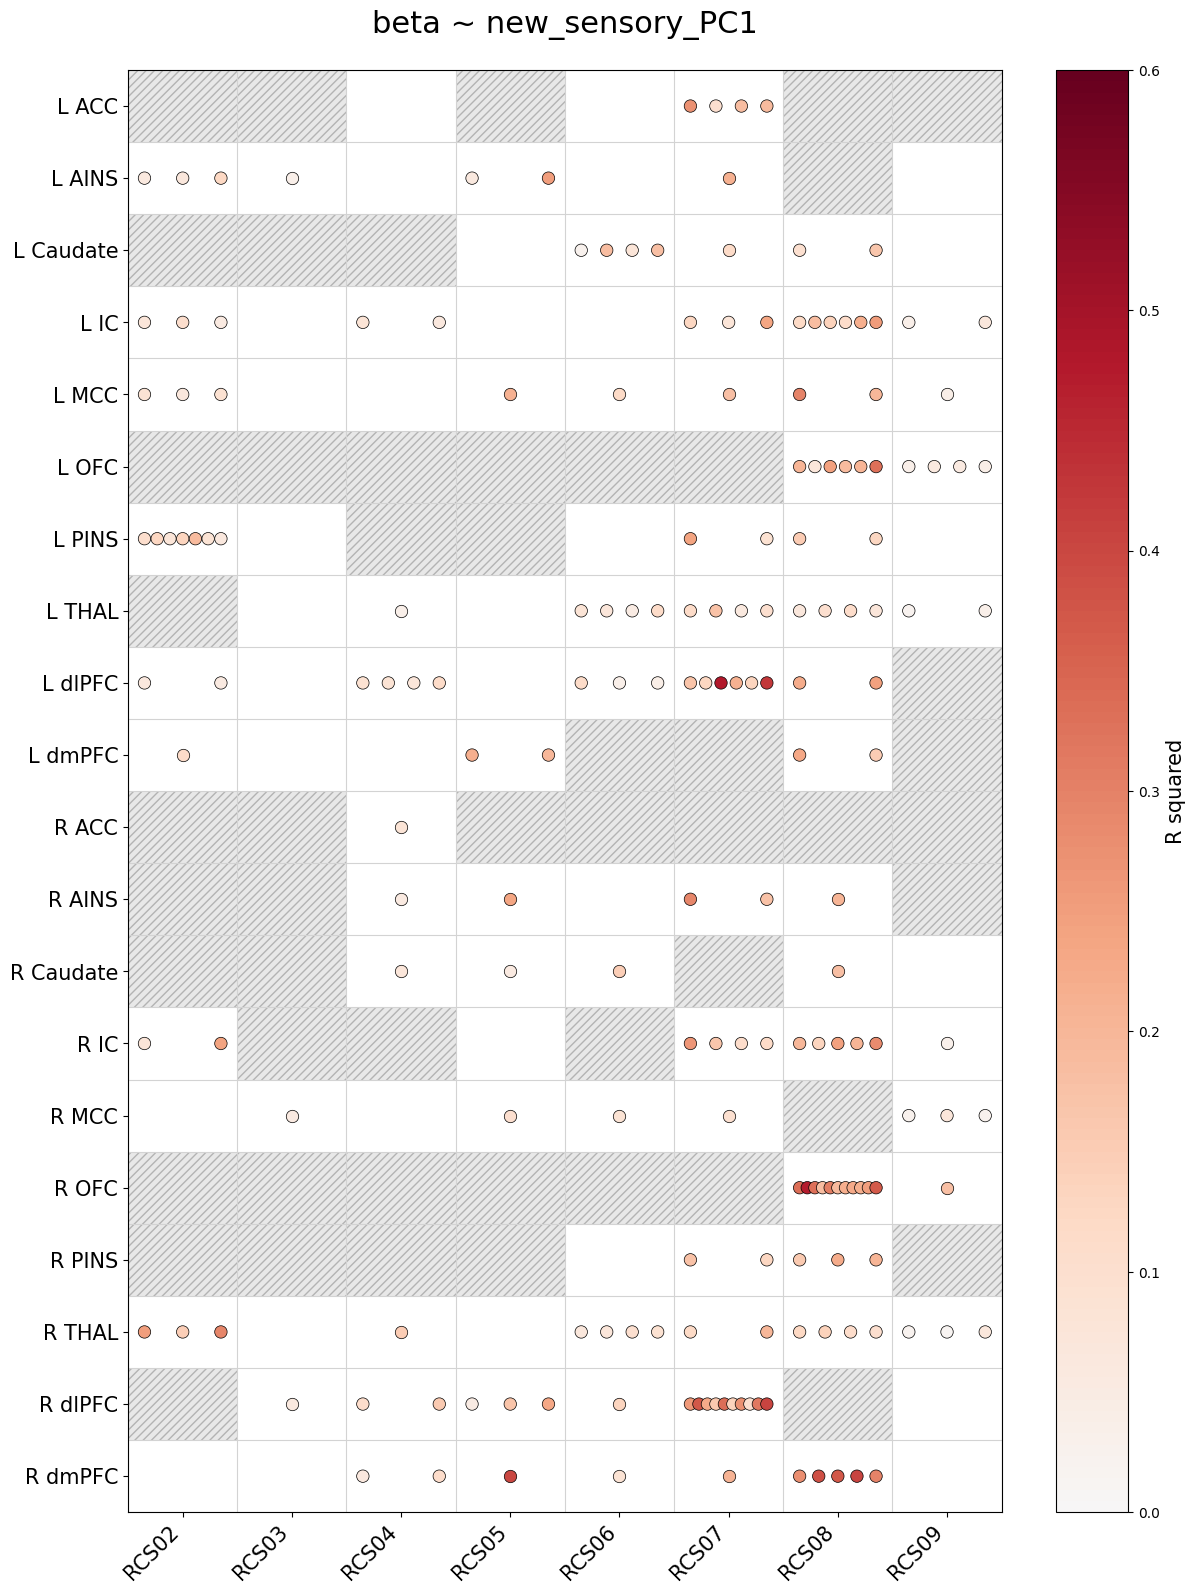

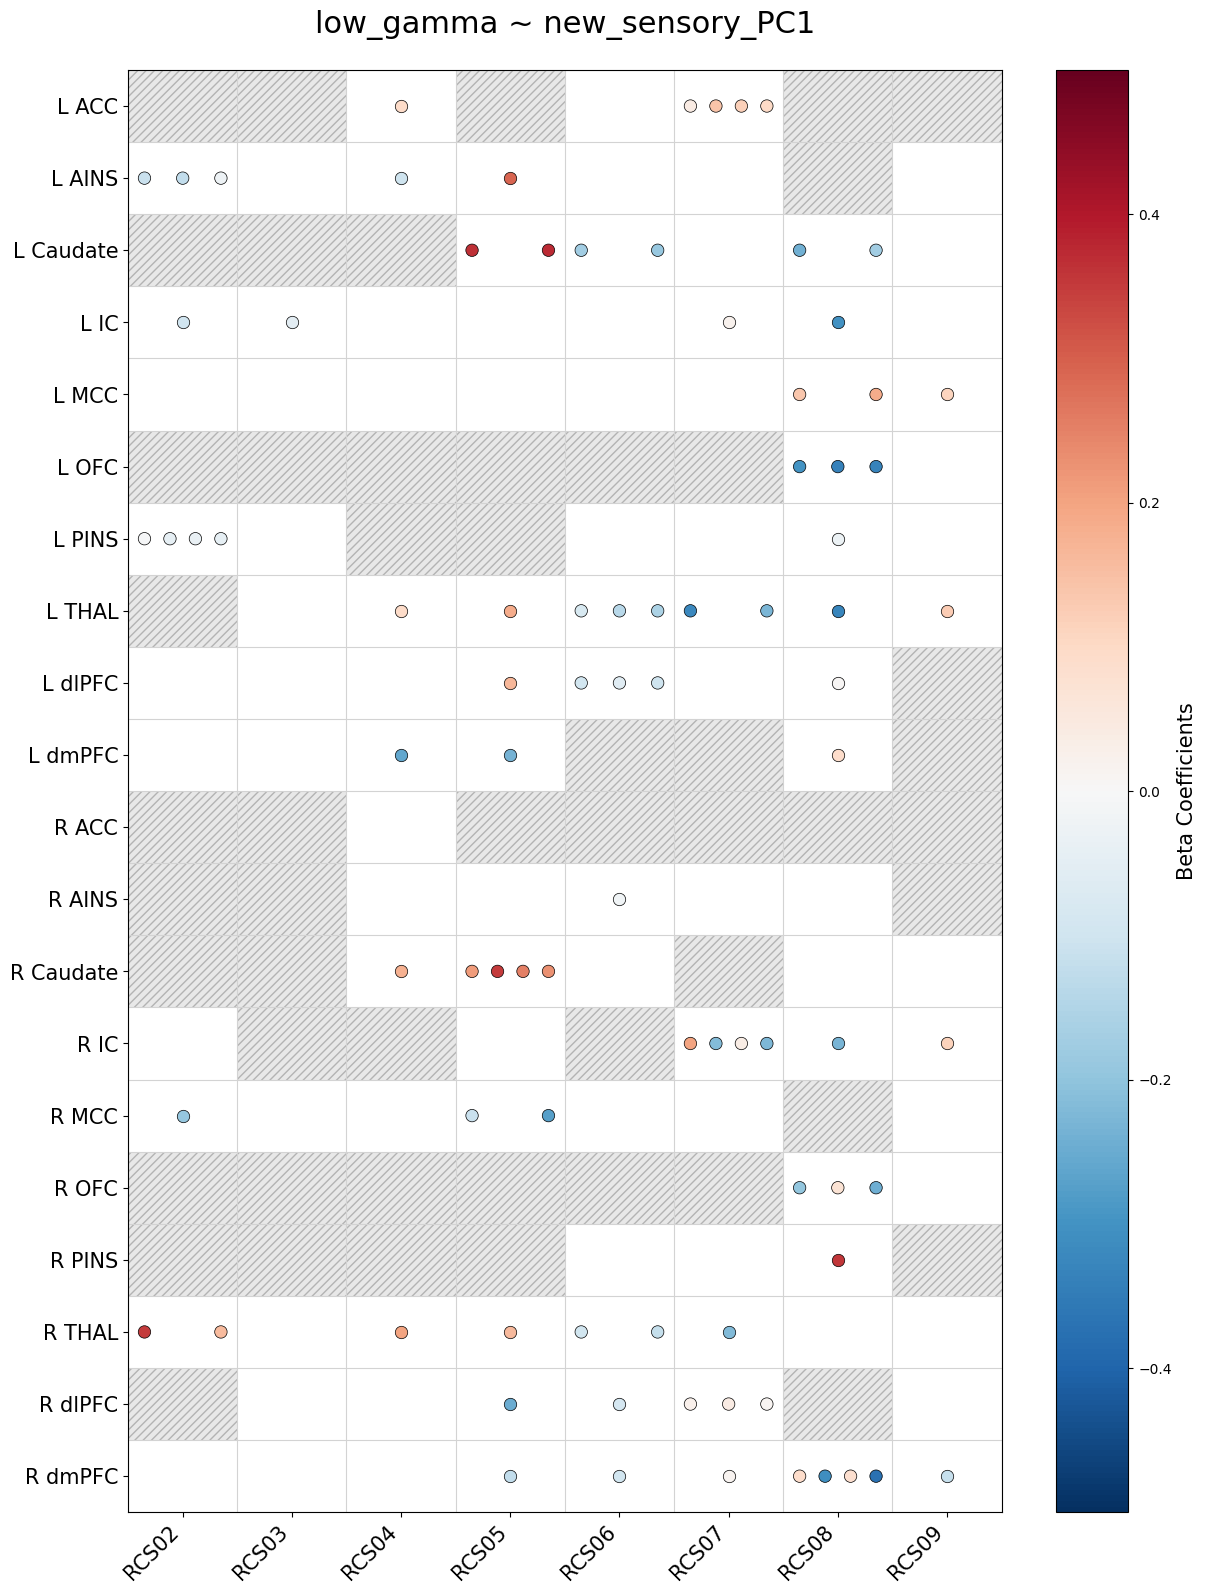

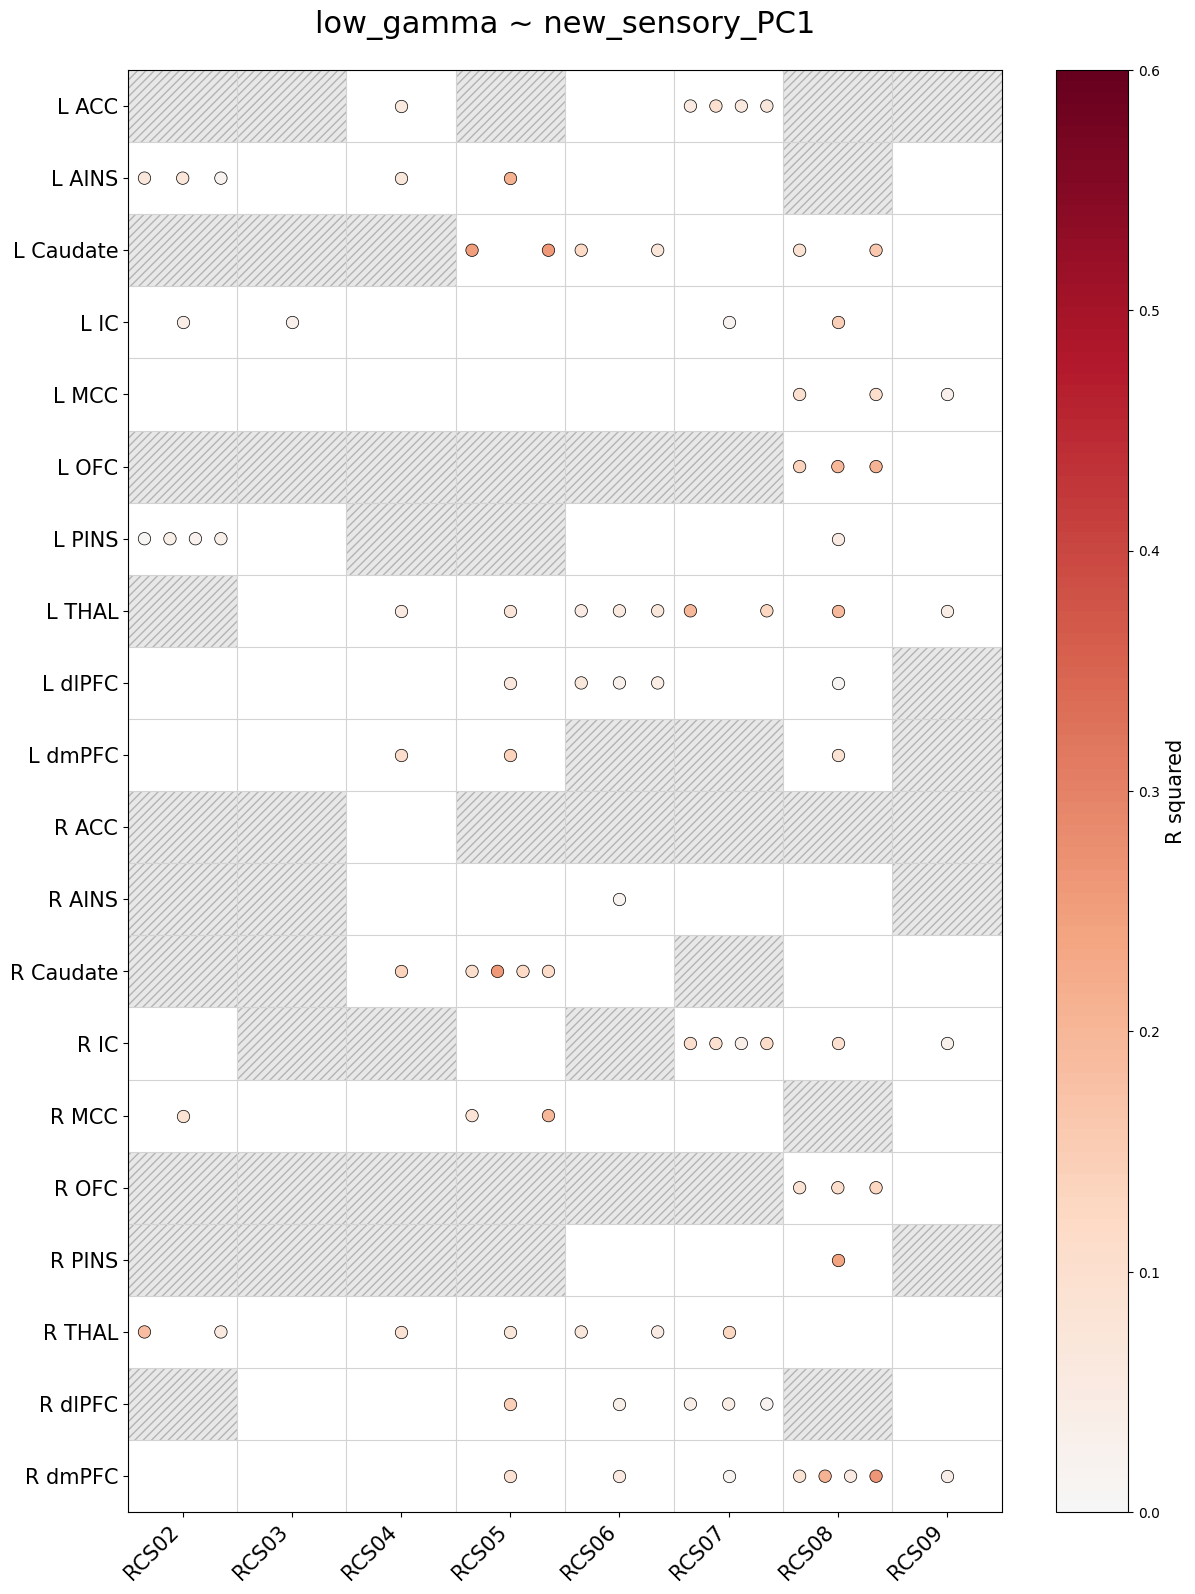

In [3]:
summary_df = pd.read_csv('/home/jiahuang/test-code-hazel/rlm_summary_aperiodicandperiodic_full.csv')
summary_df['roi'] = summary_df['ch_label'].str.replace(r'_\d+$', '', regex=True)
ptIDs_order = sorted(summary_df['ptID'].unique())
rois_order = sorted(summary_df['roi'].unique())
savepath = '/home/jiahuang/test-code-hazel/RLM_plots'
PLOTX =  ['nrs_z', 'new_affective_PC1', 'new_sensory_PC1']
PLOTY = ['exponent_z','offset_z','delta','theta','alpha','beta','low_gamma']
# NRS #
for x in PLOTX:
    for y in PLOTY:
        plot_dot_heatmap(summary_df, f'beta_{y}_{x}', [f'p_{y}_{x}'], ptIDs_order, rois_order,'Beta Coefficients',f'{y} ~ {x}', vmax=0.5,savepath=savepath)
        plot_dot_heatmap(summary_df, f'r2_{y}_{x}', [f'p_{y}_{x}'], ptIDs_order, rois_order,'R squared',f'{y} ~ {x}', vmax=0.6,vmin=0,savepath=savepath)